In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import torch.utils.data as torch_data
from scipy.stats import shapiro
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
import os

In [3]:
# Load the data
df = pd.read_csv('inputFGclassifierWithLabel.CSV')

# Preprocess the data
# Drop the first column (index 0) and the 13th column (index 12)
data_processed = df.drop(df.columns[[0, 12]], axis=1)

# Select columns 2 to 19 (index 1 to 18 in Python, as index starts from 0)
features = data_processed.iloc[:, 0:17]

# Get the last 10 columns as labels
labels = data_processed.iloc[:, -10:]

# Display processed data information
print(f"Processed data shape:")
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")
print(f"Labels columns: {labels.columns.tolist()}")

print(f"\nFeature statistics:")
print(features.describe())

Processed data shape:
Features shape: (24528, 17)
Labels shape: (24528, 10)
Labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

Feature statistics:
                Sex        Height        Weight           SBP           DBP  \
count  24528.000000  24528.000000  24528.000000  24528.000000  24528.000000   
mean       0.469300    171.587851     91.603987    126.032127     74.564579   
std        0.499067      8.636087     23.191223     24.965296     16.007327   
min        0.000000    138.300000     40.400000     47.000000     29.000000   
25%        0.000000    165.500000     75.600000    109.000000     64.000000   
50%        0.000000    171.300000     88.000000    124.000000     74.000000   
75%        1.000000    177.600000    103.300000    142.000000     84.000000   
max        1.000000    207.500000    337.800000    236.000000    150.000000   

                 EF       Hed_SW       

In [4]:

# Normalize the input features
# Skip the first and last feature columns (binary variables)
continuous_features = features.iloc[:, 1:-1]
scaler = MinMaxScaler()
normalized_features = scaler.fit_transform(continuous_features)

# Combine the binary and normalized continuous features
normalized_features = pd.DataFrame(normalized_features, columns=continuous_features.columns)
normalized_features.insert(0, features.columns[0], features.iloc[:, 0])  # Add the first binary column
normalized_features[features.columns[-1]] = features.iloc[:, -1]  # Add the last binary column

# Convert normalized features to PyTorch Tensor
input_tensor = torch.tensor(normalized_features.values, dtype=torch.float32)

# Display the tensor and its size
print("Input tensor:")
print(input_tensor)
print("\nTensor size:", input_tensor.size())

Input tensor:
tensor([[1.0000, 0.4379, 0.1516,  ..., 0.1392, 0.2769, 0.0000],
        [0.0000, 0.5116, 0.1163,  ..., 0.1418, 0.3385, 1.0000],
        [0.0000, 0.6358, 0.2455,  ..., 0.1873, 0.1308, 0.0000],
        ...,
        [1.0000, 0.5520, 0.3376,  ..., 0.1823, 0.1923, 0.0000],
        [1.0000, 0.6243, 0.4593,  ..., 0.1392, 0.2385, 0.0000],
        [0.0000, 0.4942, 0.1715,  ..., 0.2380, 0.2385, 1.0000]])

Tensor size: torch.Size([24528, 17])


In [5]:
# Define the MLP model
class MLPClassifier(nn.Module):
    def __init__(self, input_size):
        super(MLPClassifier, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, 64),  # First hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.5),
            nn.Linear(64, 32),  # Second hidden layer
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(0.5),
            nn.Linear(32, 1),  # Output layer
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.model(x)

# Initialize the model
input_size = 17  # Number of input features
model = MLPClassifier(input_size)

# Define the loss function and optimizer
criterion = nn.BCELoss()  # Binary Cross-Entropy Loss
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Display the model structure
print(model)

MLPClassifier(
  (model): Sequential(
    (0): Linear(in_features=17, out_features=64, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): Dropout(p=0.5, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
    (9): Sigmoid()
  )
)


In [6]:
# Split data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    input_tensor.numpy(), labels.values, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

# Training parameters
batch_size = 48
num_epochs = int(5e3) 
learning_rate = 5e-4

# DataLoader for batching
import torch.utils.data as torch_data
train_dataset = torch_data.TensorDataset(X_train_tensor, y_train_tensor)
train_loader = torch_data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Directory to save models
save_dir = "saved_models"
os.makedirs(save_dir, exist_ok=True)

Using device: cuda


In [26]:
# Loop through each label column
import time

for i in range(labels.shape[1]):
    label_name = labels.columns[i]  # Use label name for model identification
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Training classifier for label {label_name}... (Label {i+1}/{labels.shape[1]})")
    print(f"{'='*60}")
    
    # Initialize model, loss function, and optimizer
    model = MLPClassifier(input_size=17).to(device)  # Move model to device
    criterion = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    best_val_auc = 0.0  # Track the best validation AUC
    best_loss = float('inf')  # Track the best loss
    early_stop = False  # Early stopping flag
    epoch_count = 0  # Count actual epochs

    # Training loop
    for epoch in range(num_epochs):
        if early_stop:
            break

        epoch_count += 1
        model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in train_loader:
            # Move data to device
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            
            # Select the current label column
            batch_y = batch_y[:, i].unsqueeze(1)  # Shape: (batch_size, 1)
            
            # Forward pass
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            
            # Backward pass and optimization
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        model.eval()
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)  # Move validation data to device
            val_outputs = model(X_val_tensor_device)
            val_labels = y_val_tensor[:, i].unsqueeze(1).to(device)
            val_auc = roc_auc_score(val_labels.cpu().numpy(), val_outputs.cpu().numpy())

        # Check for early stopping and save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_loss = epoch_loss
            # Save the best model
            model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
            torch.save(model.state_dict(), model_path)

        # Only display progress every 10 epochs or when improvement occurs
        if epoch_count % 10 == 0 or val_auc > (best_val_auc - 0.001):
            print(f"[{label_name}] Epoch {epoch+1:4d} | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f}")

        if best_val_auc >= 0.975:
            print(f"[{label_name}] ✓ Early stopping! Best AUC: {best_val_auc:.4f}")
            early_stop = True

    elapsed_time = time.time() - start_time
    print(f"[{label_name}] ✓ COMPLETED | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f} | Time: {elapsed_time:.1f}s | Epochs: {epoch_count}")


Training classifier for label LabelFillingP... (Label 1/10)
[LabelFillingP] Epoch    1 | Best AUC: 0.7820 | Best Loss: 264.4583
[LabelFillingP] Epoch    1 | Best AUC: 0.7820 | Best Loss: 264.4583
[LabelFillingP] Epoch    2 | Best AUC: 0.8078 | Best Loss: 240.2732
[LabelFillingP] Epoch    2 | Best AUC: 0.8078 | Best Loss: 240.2732
[LabelFillingP] Epoch    3 | Best AUC: 0.8233 | Best Loss: 229.8394
[LabelFillingP] Epoch    3 | Best AUC: 0.8233 | Best Loss: 229.8394
[LabelFillingP] Epoch    4 | Best AUC: 0.8300 | Best Loss: 225.0941
[LabelFillingP] Epoch    4 | Best AUC: 0.8300 | Best Loss: 225.0941
[LabelFillingP] Epoch    5 | Best AUC: 0.8329 | Best Loss: 220.3769
[LabelFillingP] Epoch    5 | Best AUC: 0.8329 | Best Loss: 220.3769
[LabelFillingP] Epoch    6 | Best AUC: 0.8367 | Best Loss: 219.8404
[LabelFillingP] Epoch    6 | Best AUC: 0.8367 | Best Loss: 219.8404
[LabelFillingP] Epoch    8 | Best AUC: 0.8410 | Best Loss: 215.2043
[LabelFillingP] Epoch    8 | Best AUC: 0.8410 | Best Lo

MODEL EVALUATION AND VISUALIZATION

Evaluating LabelFillingP...


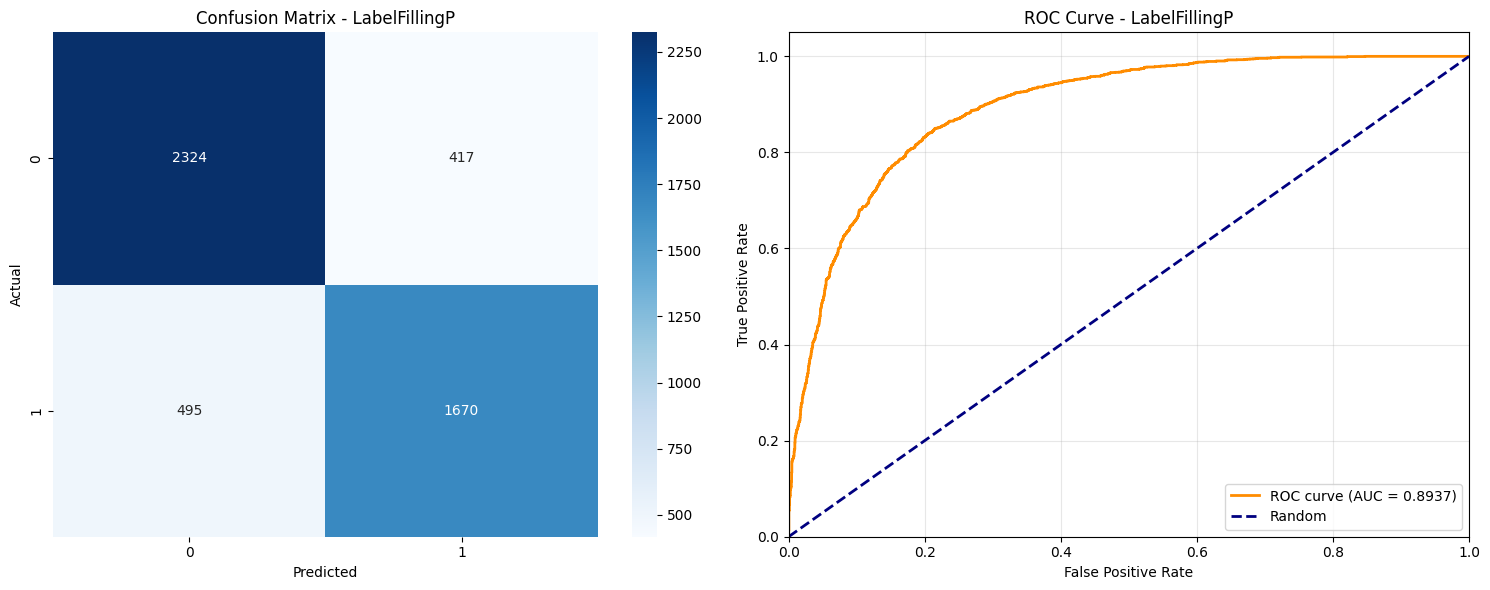

AUC: 0.8937
Accuracy: 0.8141
Precision: 0.8002
Recall: 0.7714
F1-Score: 0.7855

Evaluating LabelEF...


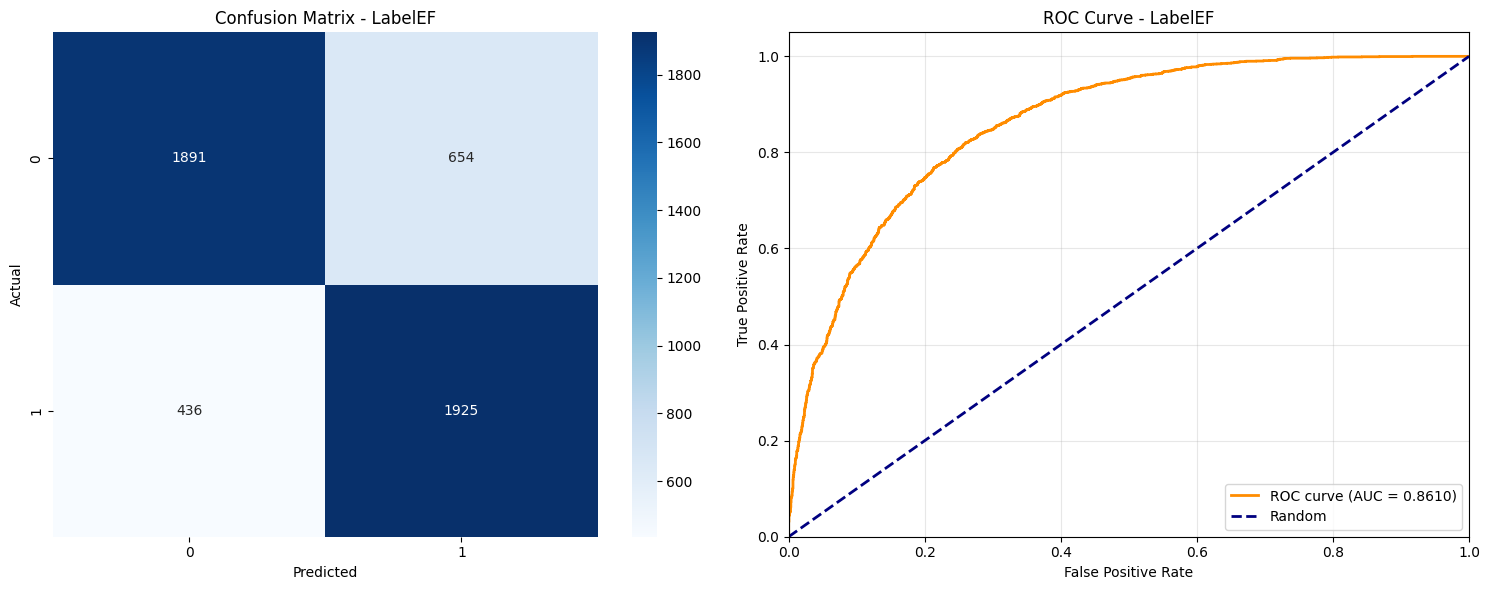

AUC: 0.8610
Accuracy: 0.7778
Precision: 0.7464
Recall: 0.8153
F1-Score: 0.7794

Evaluating LabelCO...


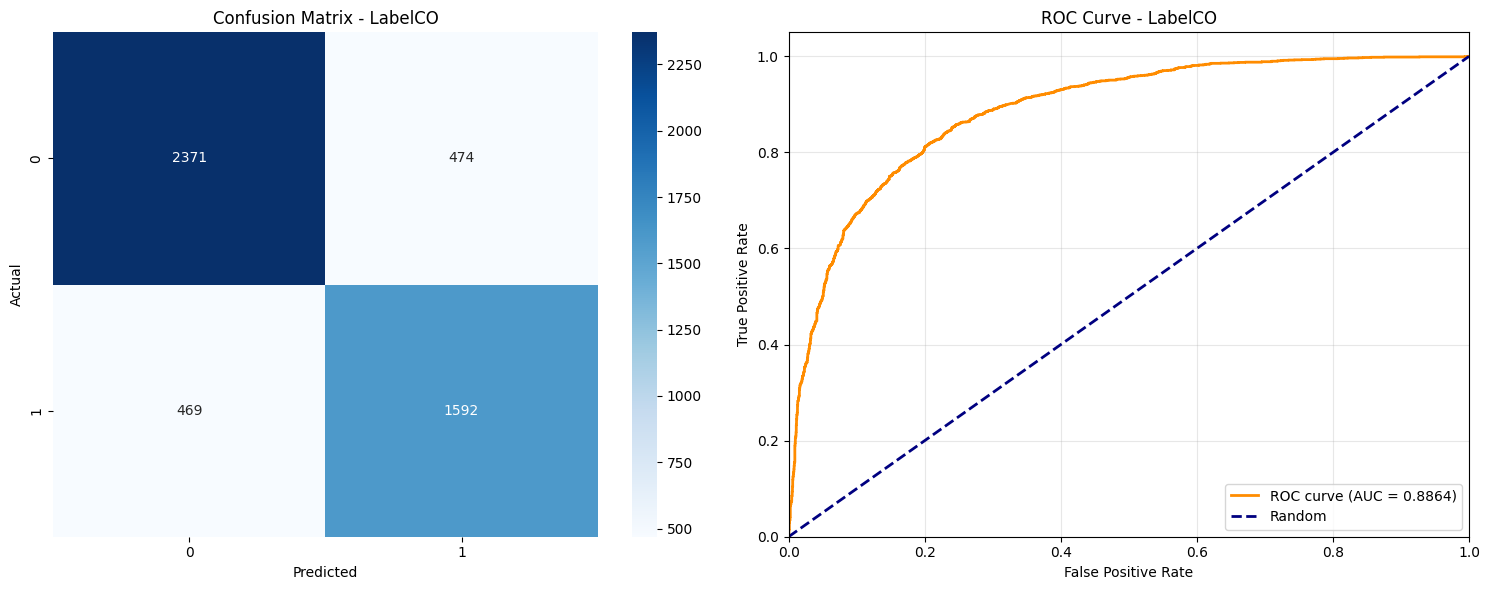

AUC: 0.8864
Accuracy: 0.8078
Precision: 0.7706
Recall: 0.7724
F1-Score: 0.7715

Evaluating LabelLAV...


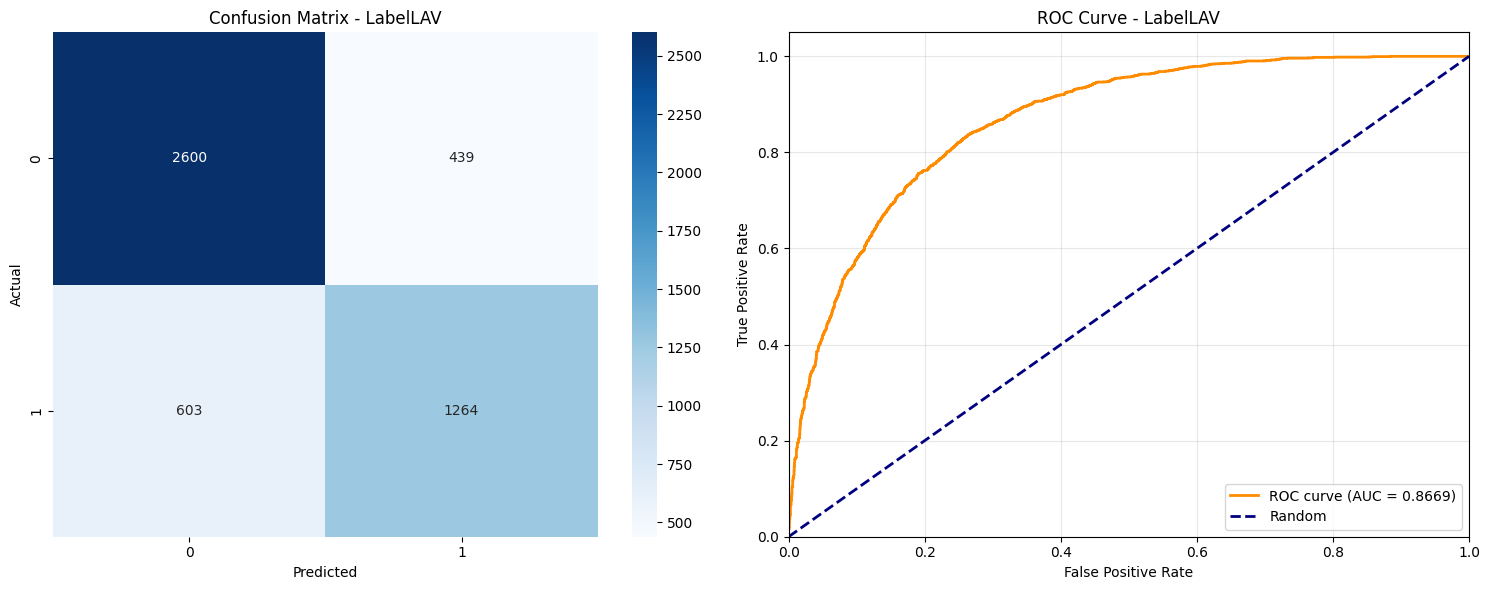

AUC: 0.8669
Accuracy: 0.7876
Precision: 0.7422
Recall: 0.6770
F1-Score: 0.7081

Evaluating LabelRVO2E...


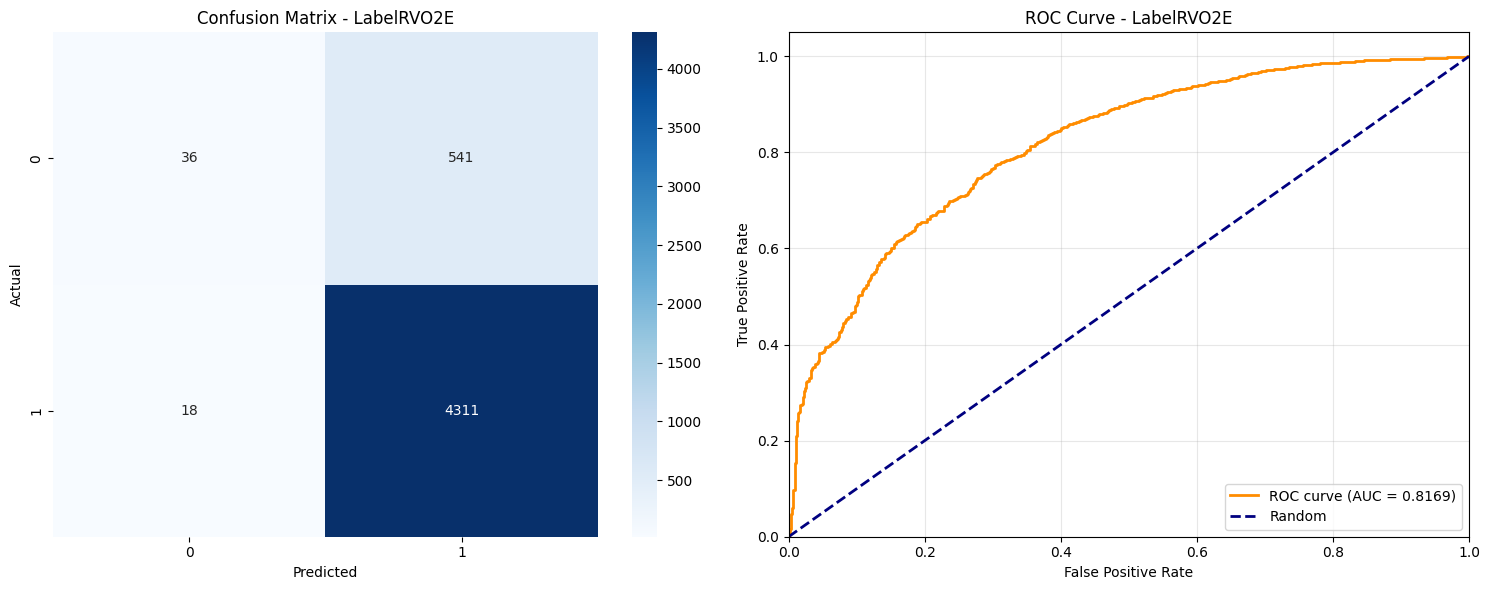

AUC: 0.8169
Accuracy: 0.8861
Precision: 0.8885
Recall: 0.9958
F1-Score: 0.9391

Evaluating LabelLVO2E...


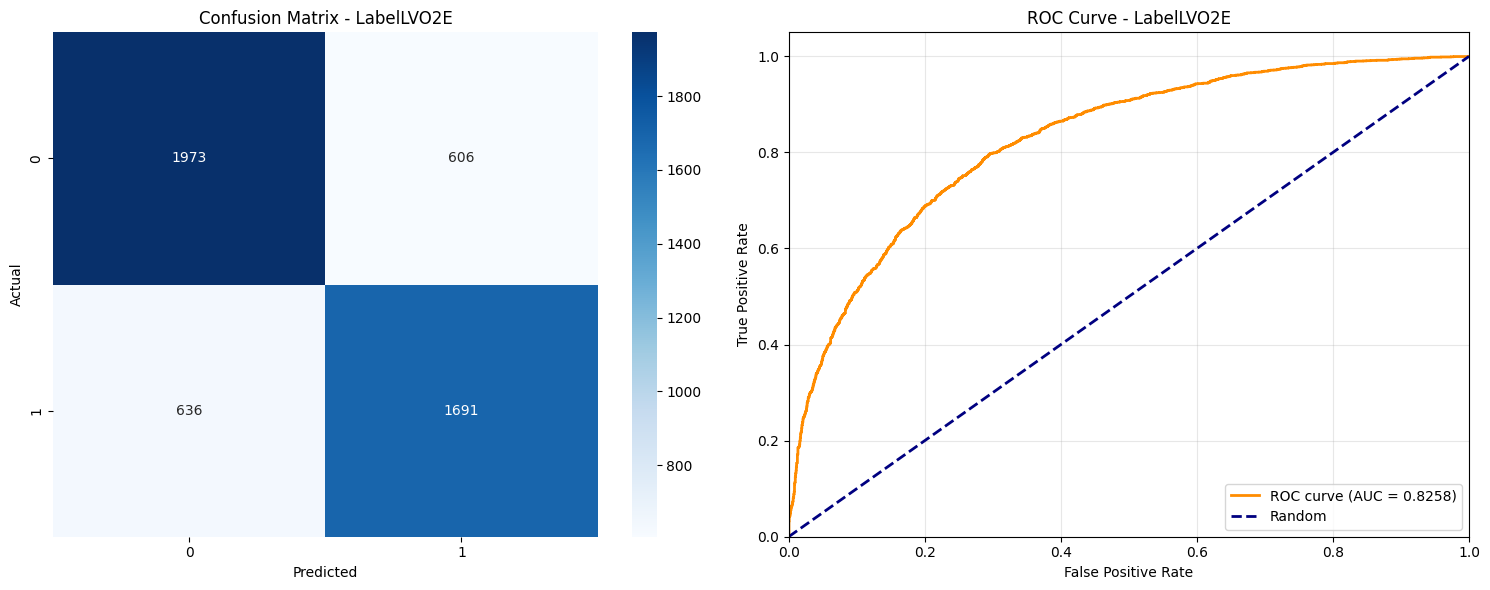

AUC: 0.8258
Accuracy: 0.7468
Precision: 0.7362
Recall: 0.7267
F1-Score: 0.7314

Evaluating LabelLVMVO2...


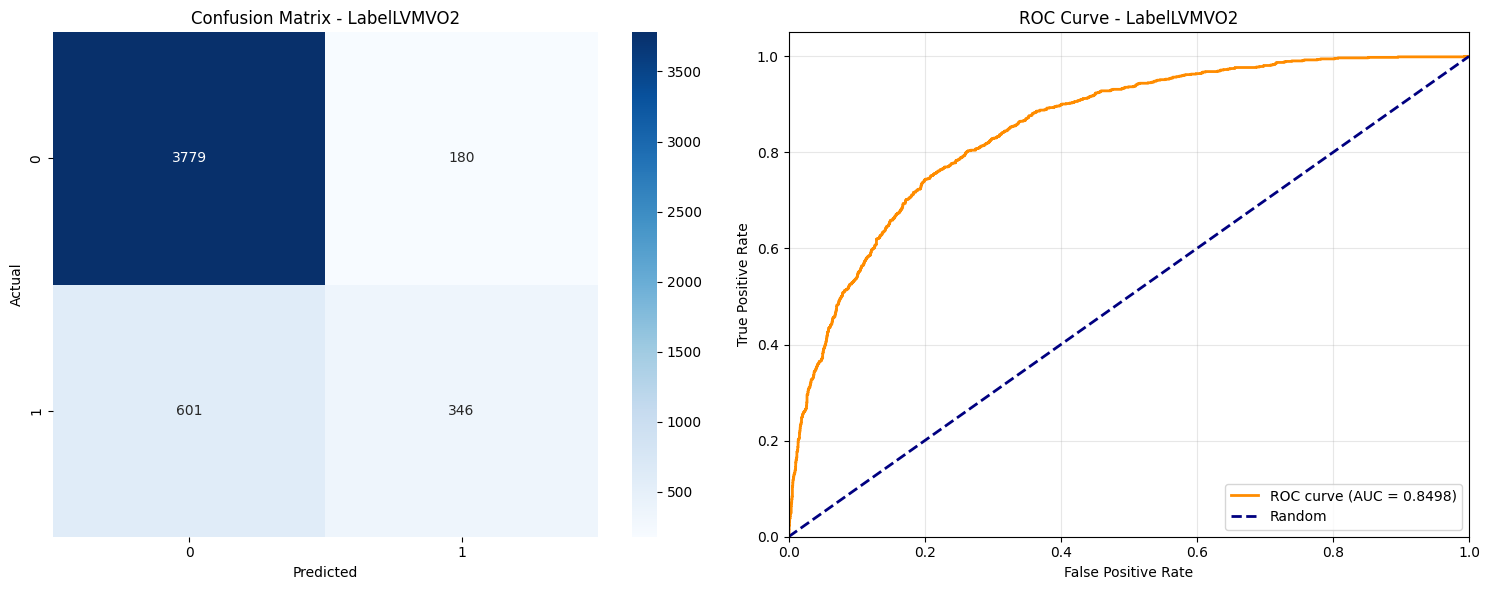

AUC: 0.8498
Accuracy: 0.8408
Precision: 0.6578
Recall: 0.3654
F1-Score: 0.4698

Evaluating LabelRVMVO2...


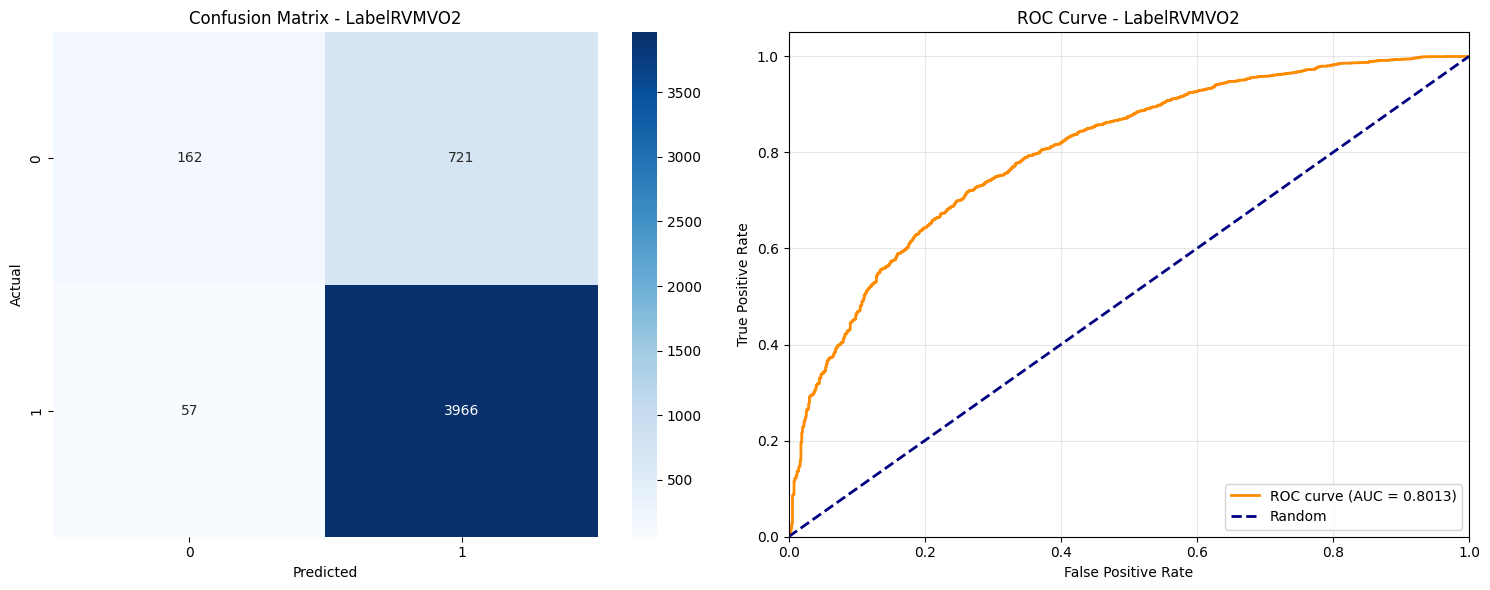

AUC: 0.8013
Accuracy: 0.8414
Precision: 0.8462
Recall: 0.9858
F1-Score: 0.9107

Evaluating LabelLVME...


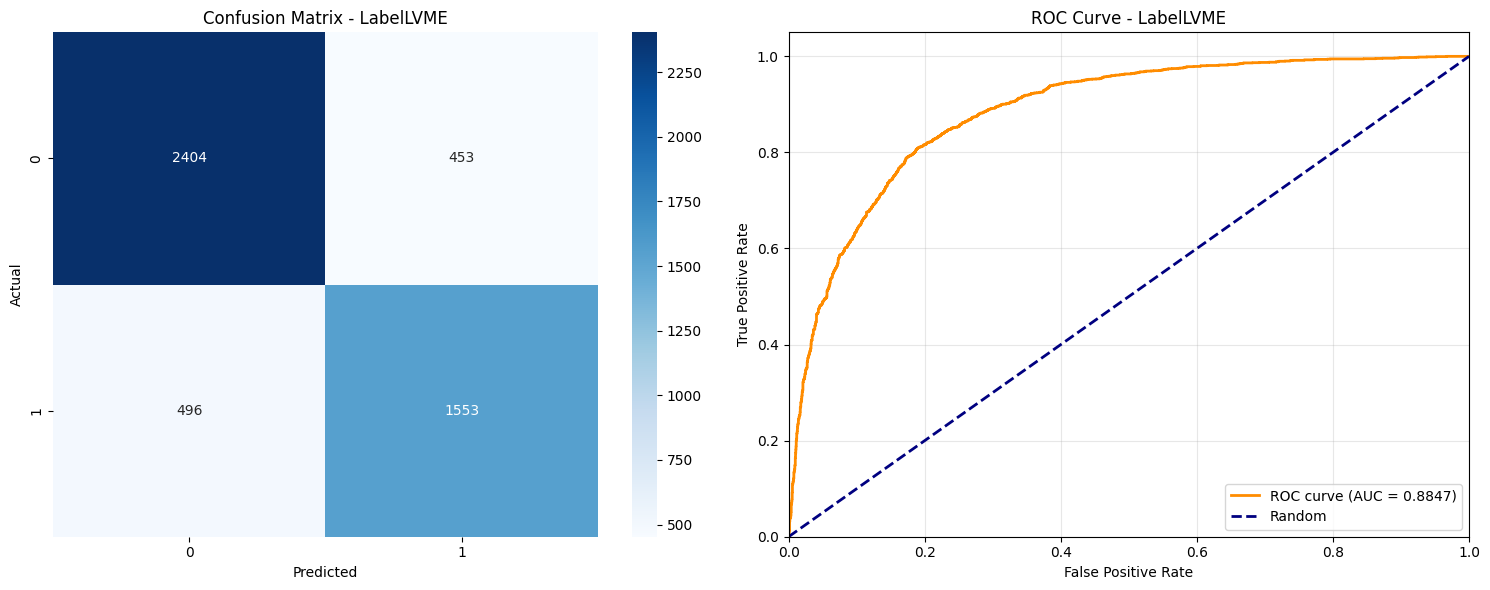

AUC: 0.8847
Accuracy: 0.8066
Precision: 0.7742
Recall: 0.7579
F1-Score: 0.7660

Evaluating LabelRVME...


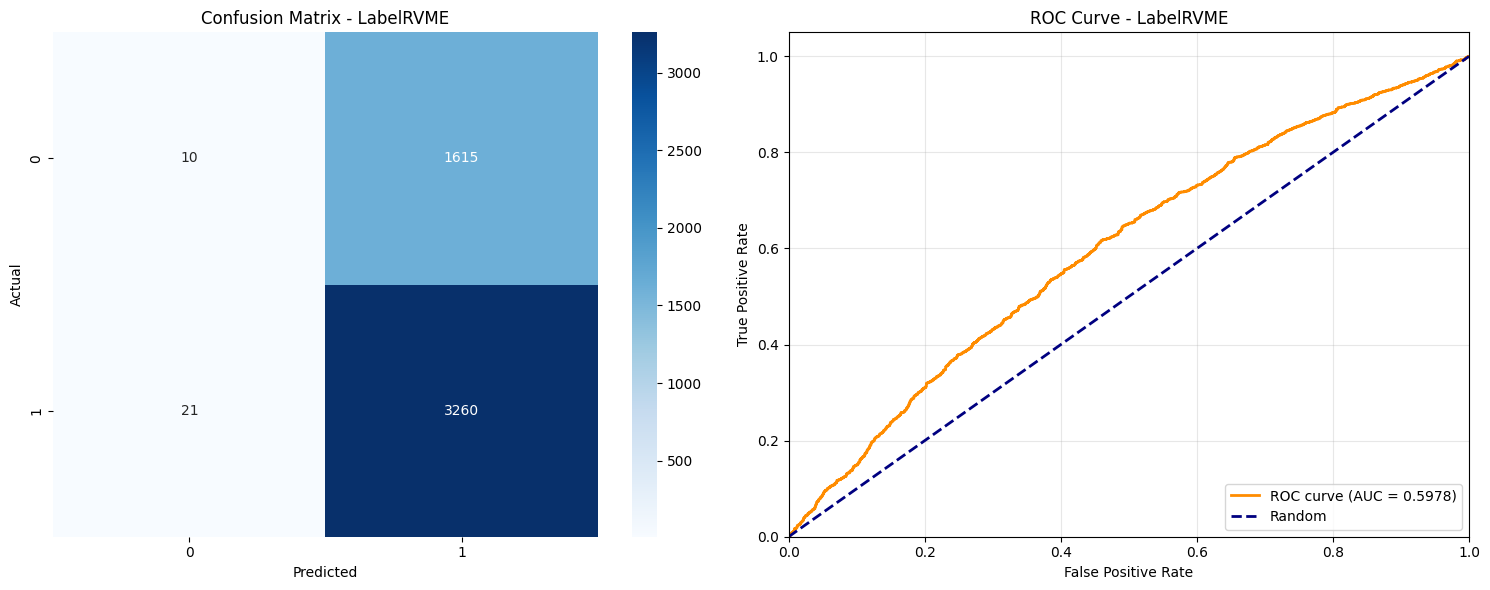

AUC: 0.5978
Accuracy: 0.6665
Precision: 0.6687
Recall: 0.9936
F1-Score: 0.7994

EVALUATION COMPLETED!
All plots saved in: evaluation_plots/


In [7]:
# Model Evaluation and Visualization
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Create directory for saving plots
plot_dir = "evaluation_plots"
os.makedirs(plot_dir, exist_ok=True)

print("="*80)
print("MODEL EVALUATION AND VISUALIZATION")
print("="*80)

# Dictionary to store all results
evaluation_results = {}

# Load and evaluate each trained model
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\nEvaluating {label_name}...")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions
        with torch.no_grad():
            X_val_tensor_device = X_val_tensor.to(device)
            val_outputs = eval_model(X_val_tensor_device)
            val_probs = val_outputs.cpu().numpy().flatten()
            val_preds = (val_probs > 0.5).astype(int)
            val_true = y_val_tensor[:, i].numpy().astype(int)
        
        # Calculate metrics
        val_auc = roc_auc_score(val_true, val_probs)
        
        # Confusion Matrix
        cm = confusion_matrix(val_true, val_preds)
        
        # Classification Report
        report = classification_report(val_true, val_preds, output_dict=True)
        
        # ROC Curve
        fpr, tpr, thresholds = roc_curve(val_true, val_probs)
        roc_auc = auc(fpr, tpr)
        
        # Store results
        evaluation_results[label_name] = {
            'confusion_matrix': cm,
            'classification_report': report,
            'auc': val_auc,
            'fpr': fpr,
            'tpr': tpr,
            'roc_auc': roc_auc,
            'predictions': val_preds,
            'probabilities': val_probs,
            'true_labels': val_true
        }
        
        # Create subplot figure for this label
        fig, axes = plt.subplots(1, 2, figsize=(15, 6))
        
        # Plot Confusion Matrix
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'Confusion Matrix - {label_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # Plot ROC Curve
        axes[1].plot(fpr, tpr, color='darkorange', lw=2, 
                    label=f'ROC curve (AUC = {roc_auc:.4f})')
        axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curve - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(os.path.join(plot_dir, f'{label_name}_evaluation.png'), dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print metrics
        print(f"AUC: {val_auc:.4f}")
        print(f"Accuracy: {report['accuracy']:.4f}")
        print(f"Precision: {report['1']['precision']:.4f}")
        print(f"Recall: {report['1']['recall']:.4f}")
        print(f"F1-Score: {report['1']['f1-score']:.4f}")
        
    else:
        print(f"Model file not found: {model_path}")

print("\n" + "="*80)
print("EVALUATION COMPLETED!")
print(f"All plots saved in: {plot_dir}/")
print("="*80)

DETAILED LABEL ANALYSIS

1. Label Distribution:
--------------------------------------------------
LabelFillingP   | Positive: 10753 (0.438) | Negative: 13775 (0.562) | Ratio: 0.781
LabelEF         | Positive: 11817 (0.482) | Negative: 12711 (0.518) | Ratio: 0.930
LabelCO         | Positive: 10227 (0.417) | Negative: 14301 (0.583) | Ratio: 0.715
LabelLAV        | Positive: 9329 (0.380) | Negative: 15199 (0.620) | Ratio: 0.614
LabelRVO2E      | Positive: 21510 (0.877) | Negative: 3018 (0.123) | Ratio: 7.127
LabelLVO2E      | Positive: 11965 (0.488) | Negative: 12563 (0.512) | Ratio: 0.952
LabelLVMVO2     | Positive: 4851 (0.198) | Negative: 19677 (0.802) | Ratio: 0.247
LabelRVMVO2     | Positive: 20078 (0.819) | Negative: 4450 (0.181) | Ratio: 4.512
LabelLVME       | Positive: 10250 (0.418) | Negative: 14278 (0.582) | Ratio: 0.718
LabelRVME       | Positive: 16333 (0.666) | Negative: 8195 (0.334) | Ratio: 1.993

2. Label Correlation Matrix:
----------------------------------------------

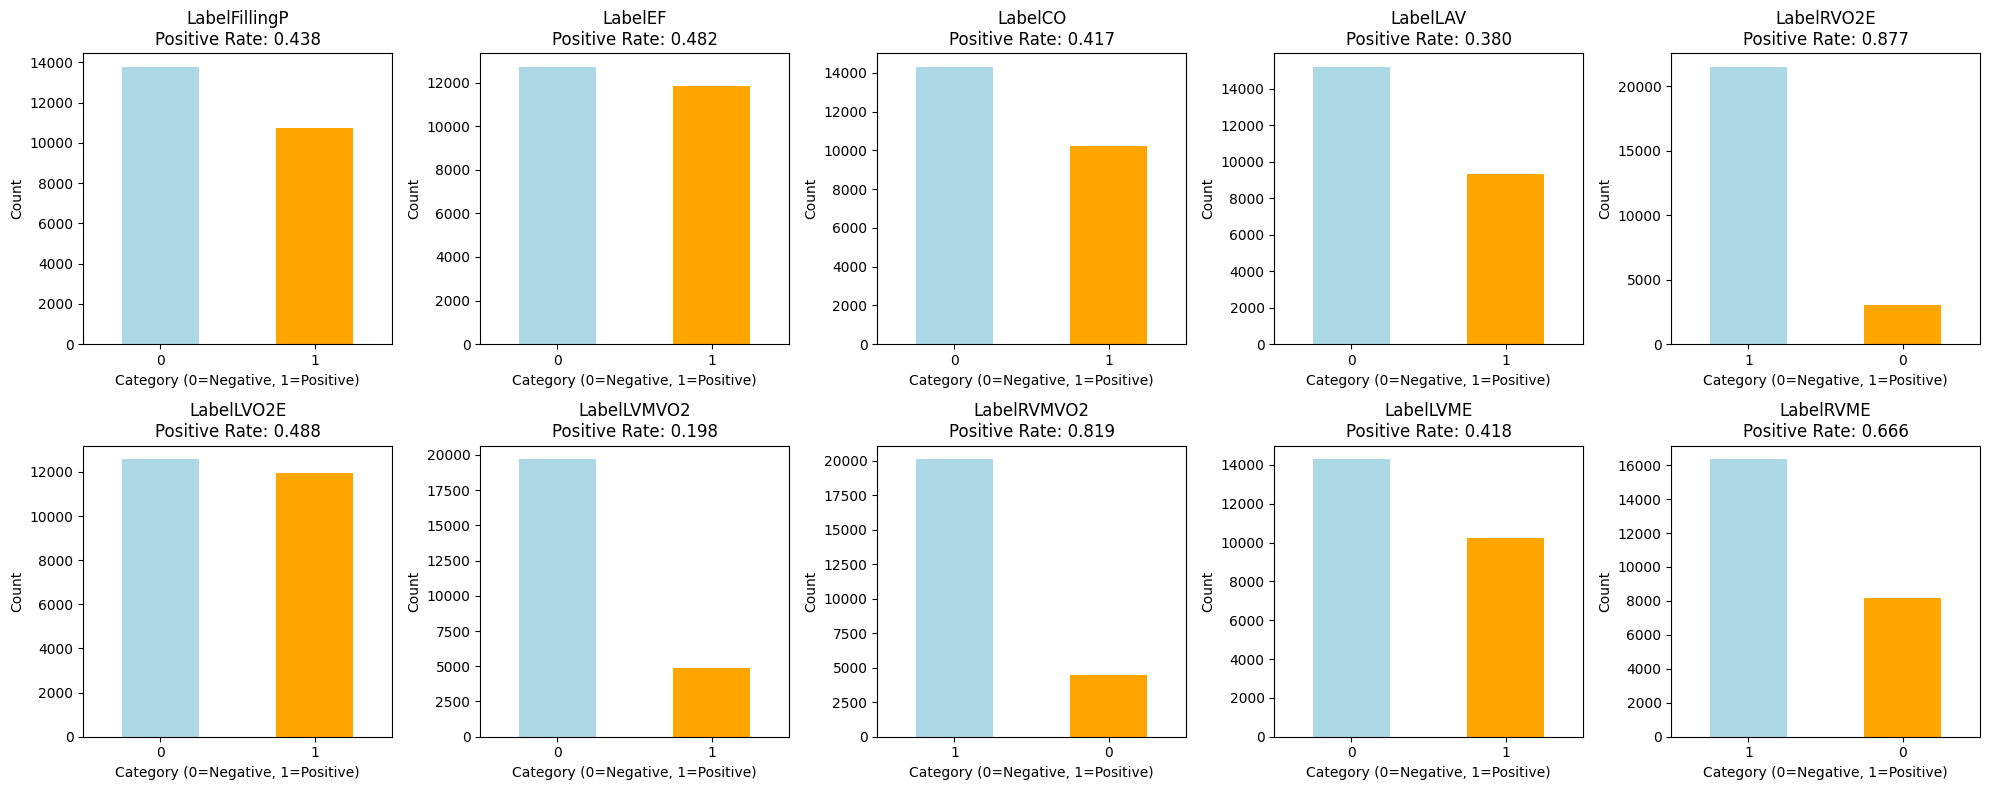


3. LabelRVME vs Other Labels Analysis:
--------------------------------------------------
LabelFillingP   vs LabelRVME: χ²=379.616, p=0.0000, Cramér's V=0.124
LabelEF         vs LabelRVME: χ²=166.061, p=0.0000, Cramér's V=0.082
LabelCO         vs LabelRVME: χ²=348.991, p=0.0000, Cramér's V=0.119
LabelLAV        vs LabelRVME: χ²=172.778, p=0.0000, Cramér's V=0.084
LabelRVO2E      vs LabelRVME: χ²=413.039, p=0.0000, Cramér's V=0.130
LabelLVO2E      vs LabelRVME: χ²=16.087, p=0.0001, Cramér's V=0.026
LabelLVMVO2     vs LabelRVME: χ²=53.759, p=0.0000, Cramér's V=0.047
LabelRVMVO2     vs LabelRVME: χ²=297.138, p=0.0000, Cramér's V=0.110
LabelLVME       vs LabelRVME: χ²=382.006, p=0.0000, Cramér's V=0.125

4. Feature Correlation with LabelRVME:
--------------------------------------------------
Feature  1 (Sex            ): -0.0208
Feature  2 (Height         ): 0.0068
Feature  3 (Weight         ): -0.0095
Feature  4 (SBP            ): 0.0338
Feature  5 (DBP            ): 0.0314
Feature  6 (

In [8]:
# 详细分析标签分布和相关性
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

print("="*80)
print("DETAILED LABEL ANALYSIS")
print("="*80)

# 1. 检查每个标签的类别分布
print("\n1. Label Distribution:")
print("-" * 50)
for i, col in enumerate(labels.columns):
    pos_count = labels[col].sum()
    neg_count = len(labels) - pos_count
    pos_ratio = pos_count / len(labels)
    print(f"{col:15s} | Positive: {pos_count:4d} ({pos_ratio:.3f}) | Negative: {neg_count:4d} ({1-pos_ratio:.3f}) | Ratio: {pos_count/neg_count:.3f}")

# 2. 标签之间的相关性矩阵
print(f"\n2. Label Correlation Matrix:")
print("-" * 50)
label_corr = labels.corr()
print(label_corr.round(3))

# 3. 可视化标签分布
fig, axes = plt.subplots(2, 5, figsize=(20, 8))
axes = axes.flatten()

for i, col in enumerate(labels.columns):
    labels[col].value_counts().plot(kind='bar', ax=axes[i], color=['lightblue', 'orange'])
    axes[i].set_title(f'{col}\nPositive Rate: {labels[col].mean():.3f}')
    axes[i].set_xlabel('Category (0=Negative, 1=Positive)')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig('label_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# 4. 检查最后一个标签与其他标签的关系
last_label = labels.columns[-1]
print(f"\n3. {last_label} vs Other Labels Analysis:")
print("-" * 50)

# 计算与其他标签的卡方检验
for col in labels.columns[:-1]:
    # 创建列联表
    contingency_table = pd.crosstab(labels[col], labels[last_label])
    chi2, p_value, dof, expected = chi2_contingency(contingency_table)
    
    # 计算Cramér's V (关联强度)
    n = contingency_table.sum().sum()
    cramers_v = np.sqrt(chi2 / (n * (min(contingency_table.shape) - 1)))
    
    print(f"{col:15s} vs {last_label}: χ²={chi2:.3f}, p={p_value:.4f}, Cramér's V={cramers_v:.3f}")

# 5. 特征与最后一个标签的相关性
print(f"\n4. Feature Correlation with {last_label}:")
print("-" * 50)
feature_label_corr = []
for i, feat_col in enumerate(features.columns):
    corr = np.corrcoef(features[feat_col], labels[last_label])[0, 1]
    feature_label_corr.append((feat_col, corr))
    print(f"Feature {i+1:2d} ({feat_col:15s}): {corr:.4f}")

# 排序显示最相关的特征
feature_label_corr.sort(key=lambda x: abs(x[1]), reverse=True)
print(f"\nTop 5 Most Correlated Features:")
for feat, corr in feature_label_corr[:5]:
    print(f"{feat:15s}: {corr:.4f}")

In [9]:
# 深度分析 LabelRVME 的问题
print("\n" + "="*80)
print("LabelRVME In-depth Problem Analysis")
print("="*80)

last_label = 'LabelRVME'
last_label_idx = list(labels.columns).index(last_label)

# 1. 检查特征相关性强度
print(f"\n1. {last_label} Feature Correlation Issue:")
print("-" * 50)
max_corr = max([abs(np.corrcoef(features.iloc[:, i], labels[last_label])[0, 1]) for i in range(len(features.columns))])
print(f"Maximum correlation with features: {max_corr:.4f}")
print("⚠️  All feature correlations are extremely low (<0.1), this is the main cause of poor performance!")

# 2. 类别不平衡分析
pos_ratio = labels[last_label].mean()
imbalance_ratio = (1-pos_ratio) / pos_ratio if pos_ratio > 0 else float('inf')
print(f"\n2. Class Imbalance Analysis:")
print("-" * 50)
print(f"Positive ratio: {pos_ratio:.3f}")
print(f"Negative ratio: {1-pos_ratio:.3f}")
print(f"Imbalance ratio: {imbalance_ratio:.2f}:1")

if imbalance_ratio > 2:
    print("⚠️  Moderate class imbalance detected")

# 3. 与其他标签的共线性检查
print(f"\n3. Correlation Analysis with Other Labels:")
print("-" * 50)
other_label_corrs = []
for col in labels.columns:
    if col != last_label:
        corr = labels[col].corr(labels[last_label])
        other_label_corrs.append((col, corr))
        
other_label_corrs.sort(key=lambda x: abs(x[1]), reverse=True)
print("Correlations with other labels (sorted by strength):")
for label, corr in other_label_corrs[:5]:
    print(f"  {label:15s}: {corr:.4f}")

# 4. 检查训练数据的可分性
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

print(f"\n4. Data Separability Test:")
print("-" * 50)

# 使用简单的逻辑回归测试
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train[:, last_label_idx])
lr_pred_proba = lr.predict_proba(X_val)[:, 1]
lr_auc = roc_auc_score(y_val[:, last_label_idx], lr_pred_proba)

print(f"Logistic Regression baseline AUC: {lr_auc:.4f}")
if lr_auc < 0.7:
    print("⚠️  Even linear models perform poorly, data itself may have issues")

# 5. 检查噪声水平
print(f"\n5. Data Quality Analysis:")
print("-" * 50)

# 计算特征的信息增益
from sklearn.feature_selection import mutual_info_classif
mi_scores = mutual_info_classif(X_train, y_train[:, last_label_idx], random_state=42)
max_mi = max(mi_scores)
print(f"Maximum mutual information score: {max_mi:.4f}")
if max_mi < 0.1:
    print("⚠️  Low mutual information between features and target, possible noise")

# 6. 建议的解决方案
print(f"\n6. Suggested Solutions:")
print("-" * 50)
print("Possible reasons for poor LabelRVME performance:")
print("1. Extremely low feature correlation - existing features contribute little")
print("2. Data may contain noise or annotation errors")
print("3. Need more relevant features or feature engineering")
print("\nRecommended approaches:")
print("• Feature combinations/interactions")
print("• Different loss functions (Focal Loss for imbalance)")
print("• Ensemble methods")
print("• Data cleaning and re-annotation")


LabelRVME In-depth Problem Analysis

1. LabelRVME Feature Correlation Issue:
--------------------------------------------------
Maximum correlation with features: 0.0858
⚠️  All feature correlations are extremely low (<0.1), this is the main cause of poor performance!

2. Class Imbalance Analysis:
--------------------------------------------------
Positive ratio: 0.666
Negative ratio: 0.334
Imbalance ratio: 0.50:1

3. Correlation Analysis with Other Labels:
--------------------------------------------------
Correlations with other labels (sorted by strength):
  LabelRVO2E     : 0.1299
  LabelLVME      : 0.1249
  LabelFillingP  : 0.1245
  LabelCO        : 0.1194
  LabelRVMVO2    : 0.1102

4. Data Separability Test:
--------------------------------------------------
Logistic Regression baseline AUC: 0.5855
⚠️  Even linear models perform poorly, data itself may have issues

5. Data Quality Analysis:
--------------------------------------------------
Maximum mutual information score: 0.00


Neural Network Complexity Impact Analysis for LabelRVME

Analysis on whether to increase neural network complexity (more neurons/hidden layers):

🔍 Current Network Structure: 17 → 64 → 32 → 1
📊 Data Scale: ~25,000 samples, 17 features

❌ Why increasing complexity may be ineffective:

1. Extremely low feature correlation (max=0.086)
   • Even with infinite model capacity, cannot extract useful info from uncorrelated features
   • This is a data problem, not a model problem

2. Overfitting risk
   • Current dropout=0.5 is already high, indicating model prone to overfitting
   • More complex models will exacerbate this issue
   • Validation AUC stagnating at 0.6 suggests model reached data's information limit

3. Simple baseline performs equally poorly
   • Logistic regression AUC=0.585, barely different from complex MLP
   • Indicates poor linear/non-linear separability of data

✅ More effective approaches:

1. Feature Engineering > Model Complexity
   • Feature interactions: LVEDV × LV

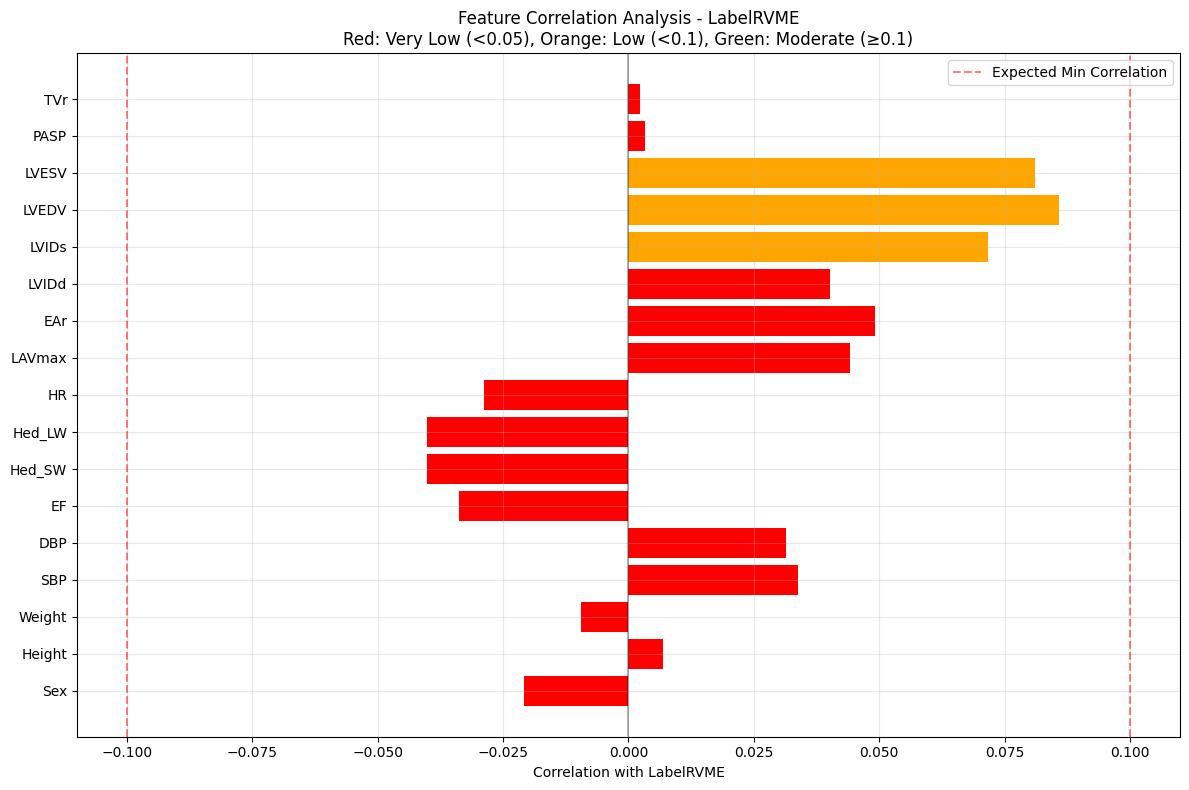

Average absolute correlation of all features: 0.0366
📊 Conclusion: Average correlation extremely low, increasing model complexity won't significantly improve performance


In [11]:
# 关于神经网络复杂度的分析
print("\n" + "="*80)
print("Neural Network Complexity Impact Analysis for LabelRVME")
print("="*80)

print("""
Analysis on whether to increase neural network complexity (more neurons/hidden layers):

🔍 Current Network Structure: 17 → 64 → 32 → 1
📊 Data Scale: ~25,000 samples, 17 features

❌ Why increasing complexity may be ineffective:

1. Extremely low feature correlation (max=0.086)
   • Even with infinite model capacity, cannot extract useful info from uncorrelated features
   • This is a data problem, not a model problem

2. Overfitting risk
   • Current dropout=0.5 is already high, indicating model prone to overfitting
   • More complex models will exacerbate this issue
   • Validation AUC stagnating at 0.6 suggests model reached data's information limit

3. Simple baseline performs equally poorly
   • Logistic regression AUC=0.585, barely different from complex MLP
   • Indicates poor linear/non-linear separability of data

✅ More effective approaches:

1. Feature Engineering > Model Complexity
   • Feature interactions: LVEDV × LVESV
   • Feature ratios: LVESV/LVEDV
   • Domain knowledge-driven feature combinations

2. Data Quality Improvement
   • Check annotation consistency
   • Outlier handling
   • Add more relevant features

3. Loss Function Optimization
   • Focal Loss for hard samples
   • Class-balanced loss
   • Custom weights

📊 Suggested experiment order:
1. Try feature engineering first (low cost, potentially significant effect)
2. Check data quality
3. Only then consider model complexity adjustments

Conclusion: With extremely low feature correlation, increasing neural network complexity 
           is usually ineffective and potentially harmful. Should prioritize data and 
           feature issues first.
""")

# 可视化特征重要性
print("\nFeature Correlation with LabelRVME Visualization:")
feature_names = features.columns.tolist()
correlations = [np.corrcoef(features[col], labels['LabelRVME'])[0, 1] for col in feature_names]

plt.figure(figsize=(12, 8))
colors = ['red' if abs(c) < 0.05 else 'orange' if abs(c) < 0.1 else 'green' for c in correlations]
bars = plt.barh(range(len(feature_names)), correlations, color=colors)
plt.yticks(range(len(feature_names)), feature_names)
plt.xlabel('Correlation with LabelRVME')
plt.title('Feature Correlation Analysis - LabelRVME\nRed: Very Low (<0.05), Orange: Low (<0.1), Green: Moderate (≥0.1)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Expected Min Correlation')
plt.axvline(x=-0.1, color='red', linestyle='--', alpha=0.5)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('feature_correlation_RVME.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Average absolute correlation of all features: {np.mean([abs(c) for c in correlations]):.4f}")
print("📊 Conclusion: Average correlation extremely low, increasing model complexity won't significantly improve performance")

EXTERNAL VALIDATION SET EVALUATION
✓ Successfully loaded external validation data: inputFGclassifier146.CSV

External validation data shape:
Features shape: (146, 17)
Labels shape: (146, 10)
External validation tensor size: torch.Size([146, 17])
External validation labels columns: ['LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET

External Validation: LabelFillingP


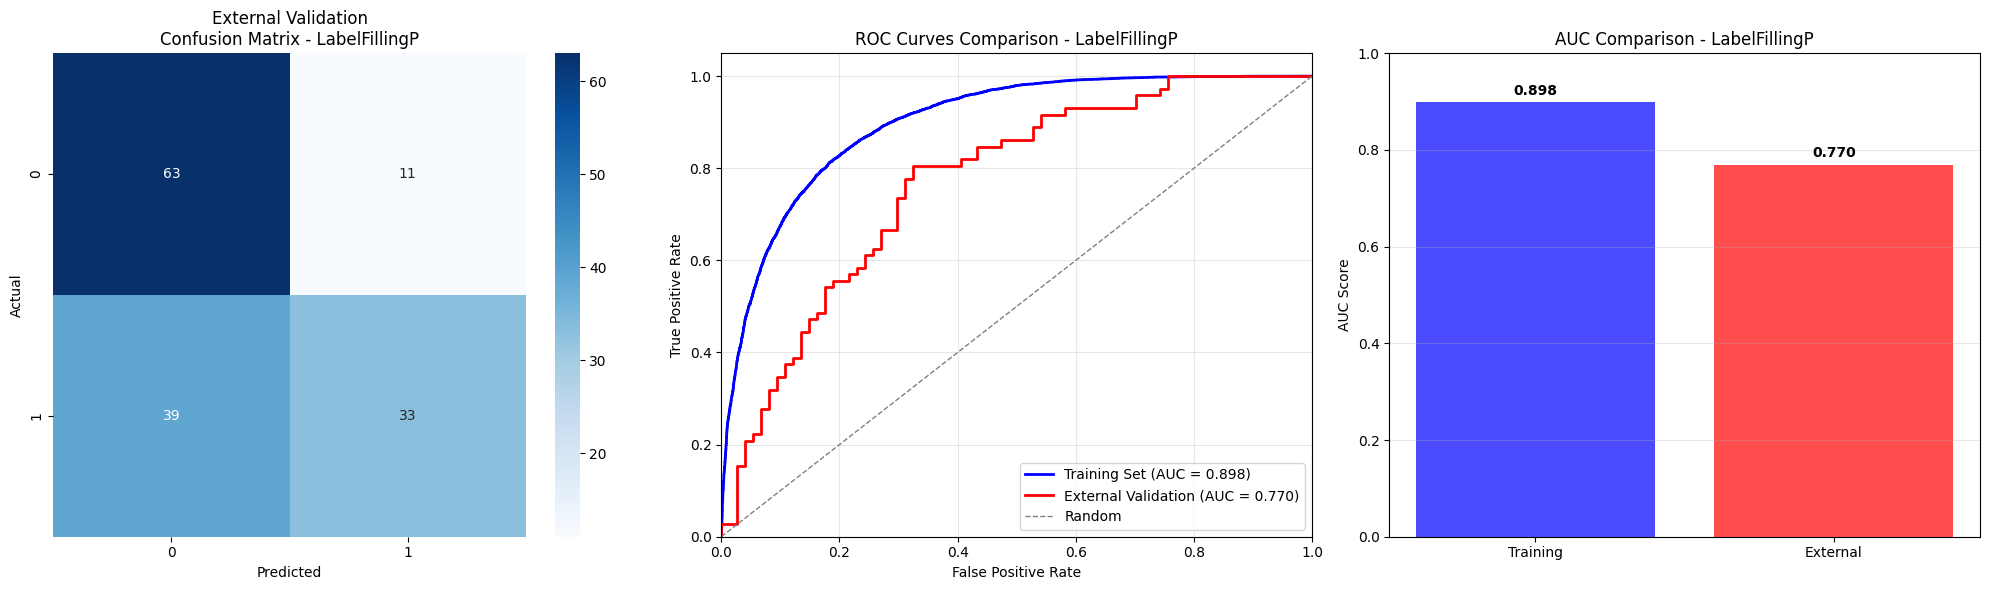

External Validation Results:
  AUC: 0.7697
  Accuracy: 0.6575
  Precision: 0.7500
  Recall: 0.4583
  F1-Score: 0.5690
Training vs External AUC Difference: 0.1284
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelEF


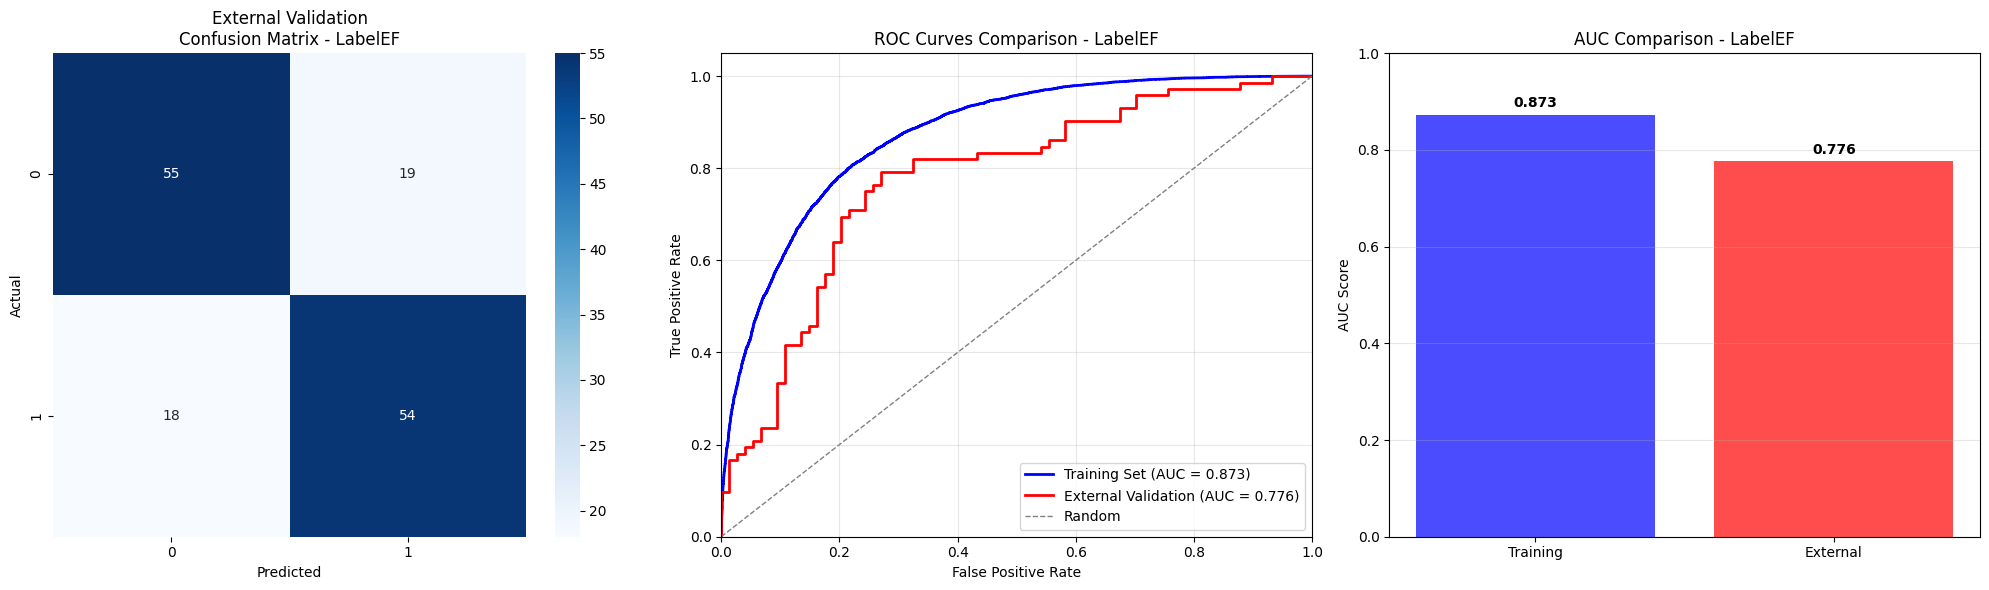

External Validation Results:
  AUC: 0.7761
  Accuracy: 0.7466
  Precision: 0.7397
  Recall: 0.7500
  F1-Score: 0.7448
Training vs External AUC Difference: 0.0969
✓ Acceptable performance on external validation

External Validation: LabelCO


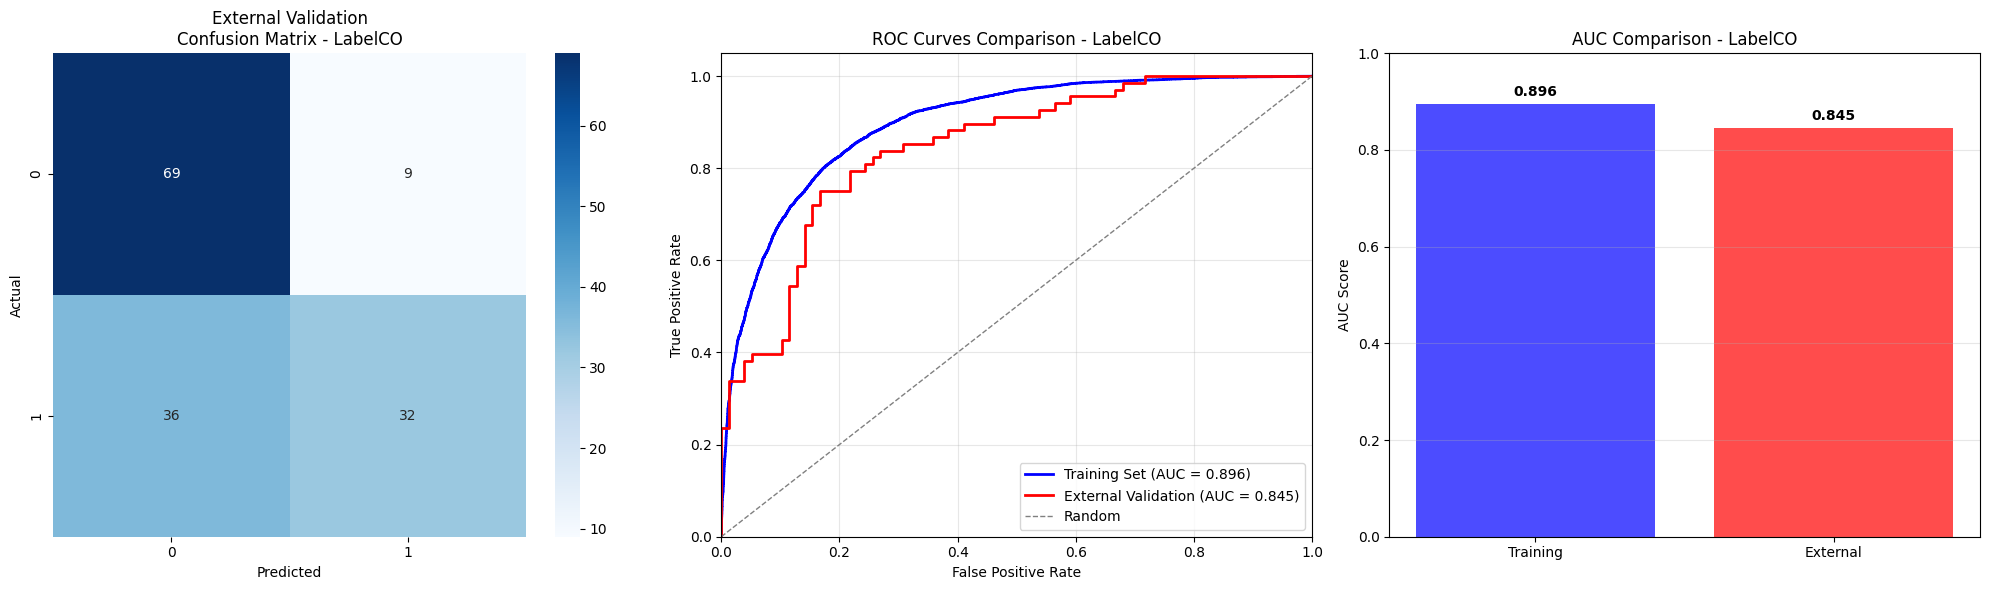

External Validation Results:
  AUC: 0.8454
  Accuracy: 0.6918
  Precision: 0.7805
  Recall: 0.4706
  F1-Score: 0.5872
Training vs External AUC Difference: 0.0504
✓ Acceptable performance on external validation

External Validation: LabelLAV


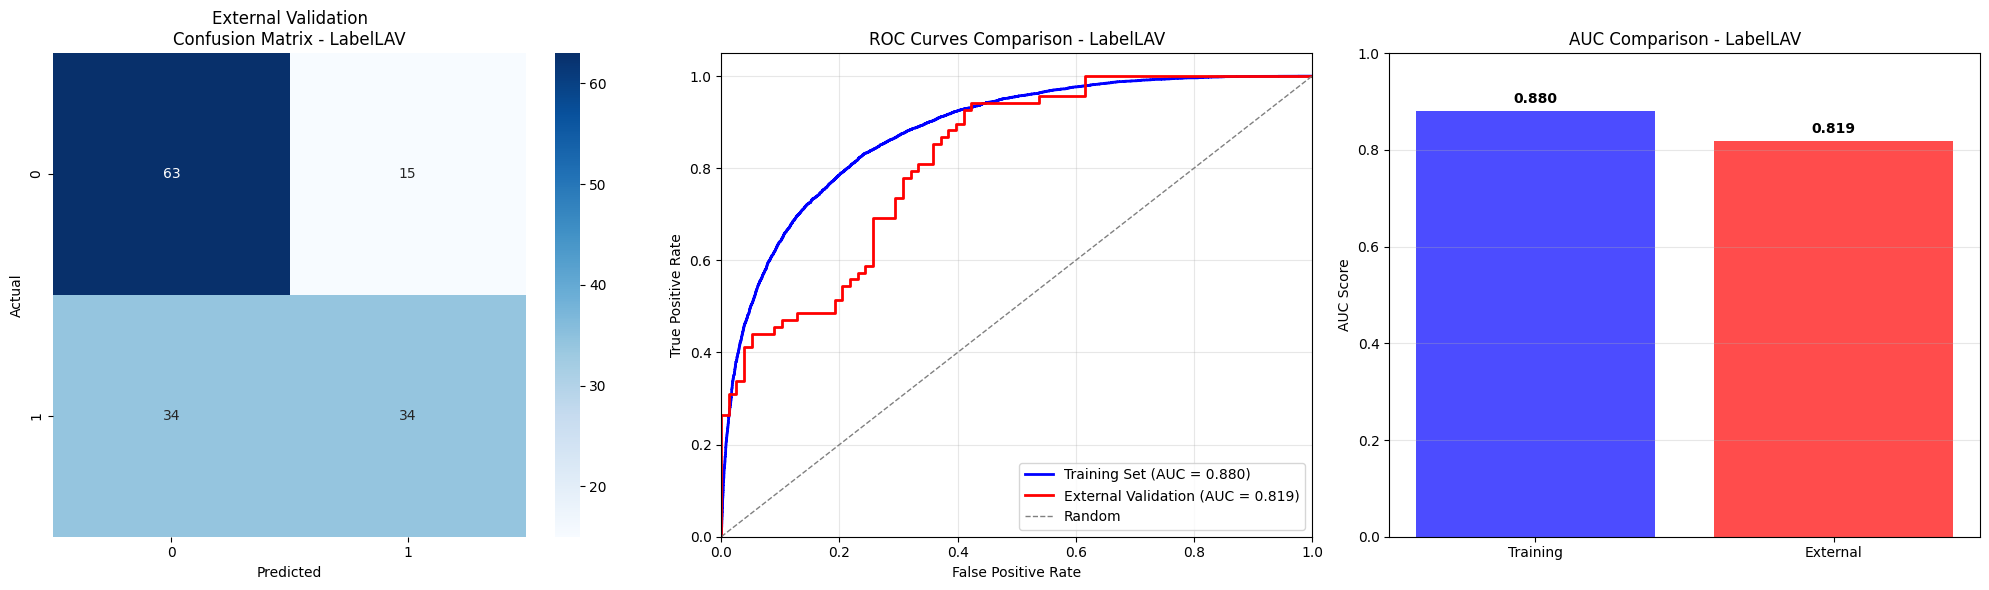

External Validation Results:
  AUC: 0.8190
  Accuracy: 0.6644
  Precision: 0.6939
  Recall: 0.5000
  F1-Score: 0.5812
Training vs External AUC Difference: 0.0608
✓ Acceptable performance on external validation

External Validation: LabelRVO2E


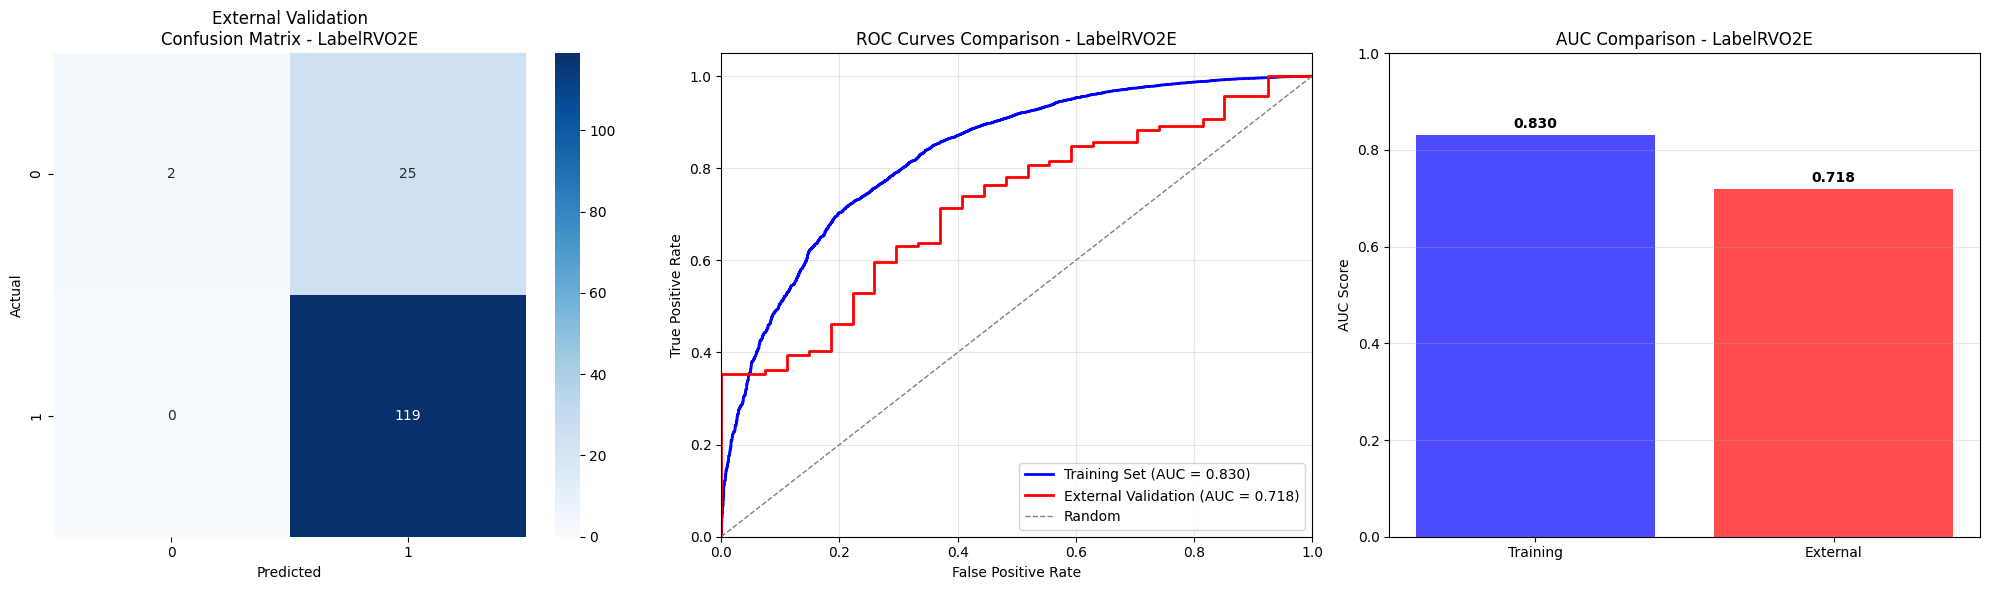

External Validation Results:
  AUC: 0.7183
  Accuracy: 0.8288
  Precision: 0.8264
  Recall: 1.0000
  F1-Score: 0.9049
Training vs External AUC Difference: 0.1116
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelLVO2E


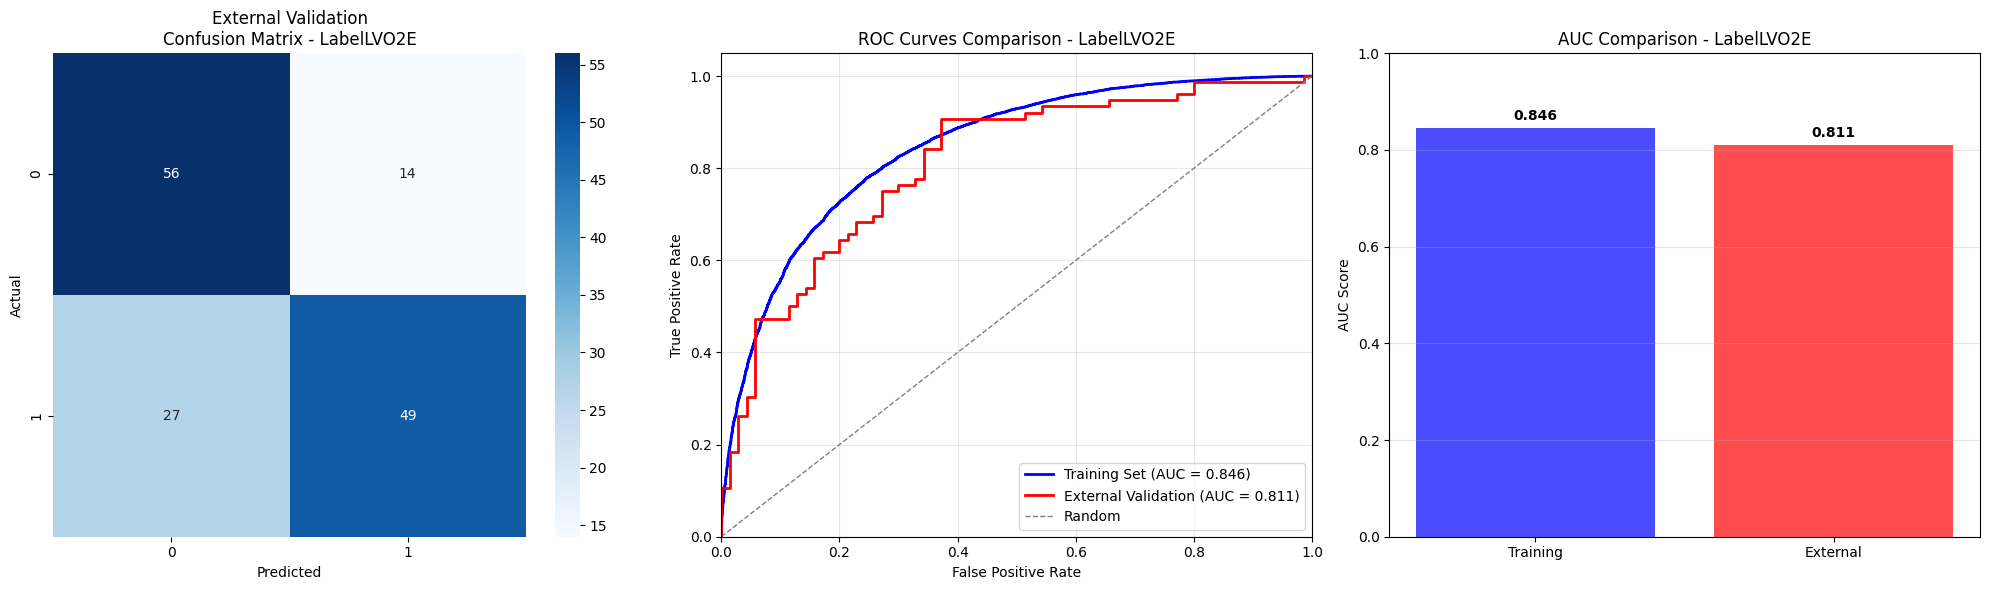

External Validation Results:
  AUC: 0.8105
  Accuracy: 0.7192
  Precision: 0.7778
  Recall: 0.6447
  F1-Score: 0.7050
Training vs External AUC Difference: 0.0355
✓ Acceptable performance on external validation

External Validation: LabelLVMVO2


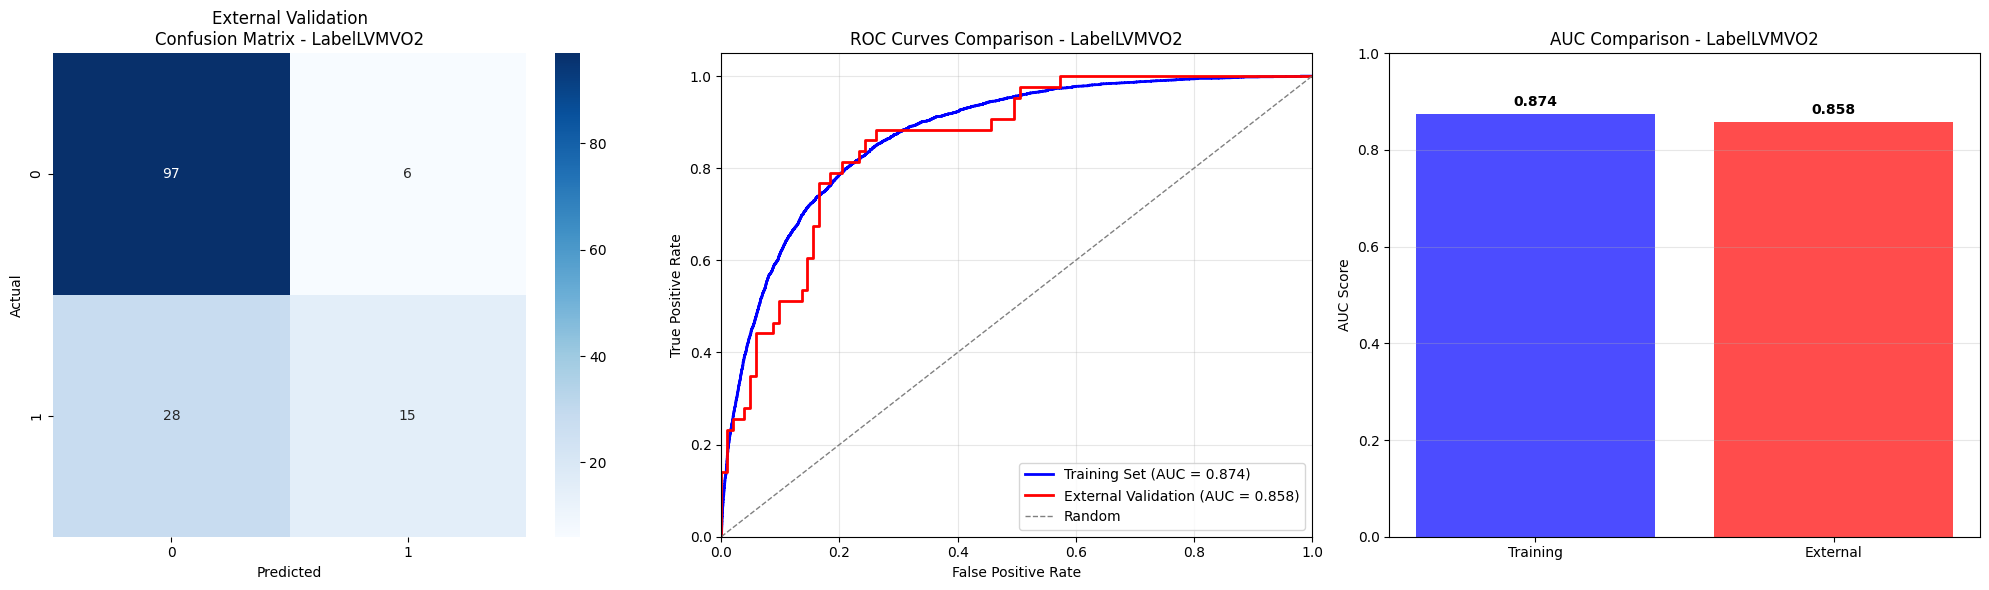

External Validation Results:
  AUC: 0.8580
  Accuracy: 0.7671
  Precision: 0.7143
  Recall: 0.3488
  F1-Score: 0.4688
Training vs External AUC Difference: 0.0158
✓ Acceptable performance on external validation

External Validation: LabelRVMVO2


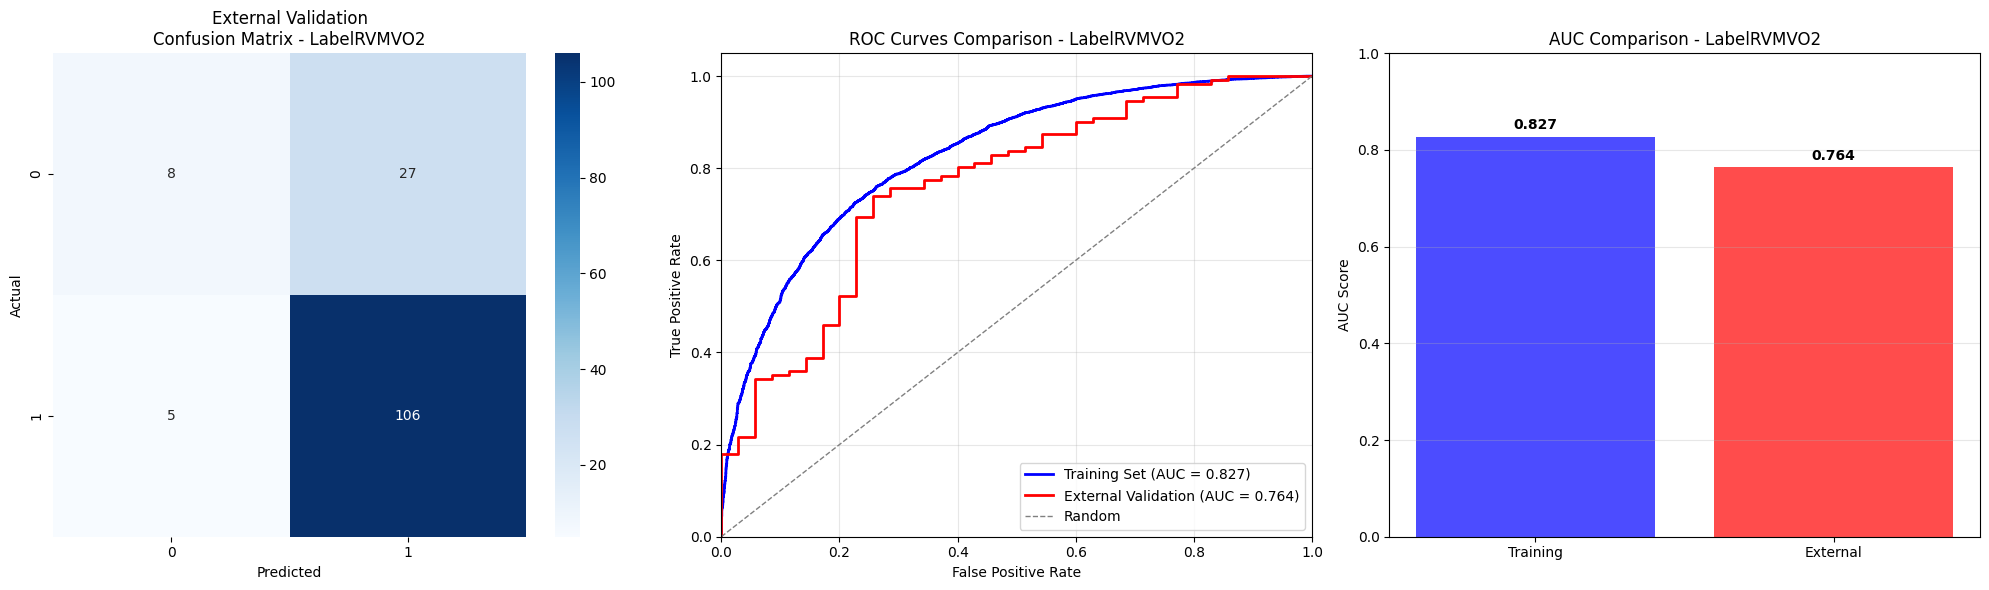

External Validation Results:
  AUC: 0.7637
  Accuracy: 0.7808
  Precision: 0.7970
  Recall: 0.9550
  F1-Score: 0.8689
Training vs External AUC Difference: 0.0638
✓ Acceptable performance on external validation

External Validation: LabelLVME


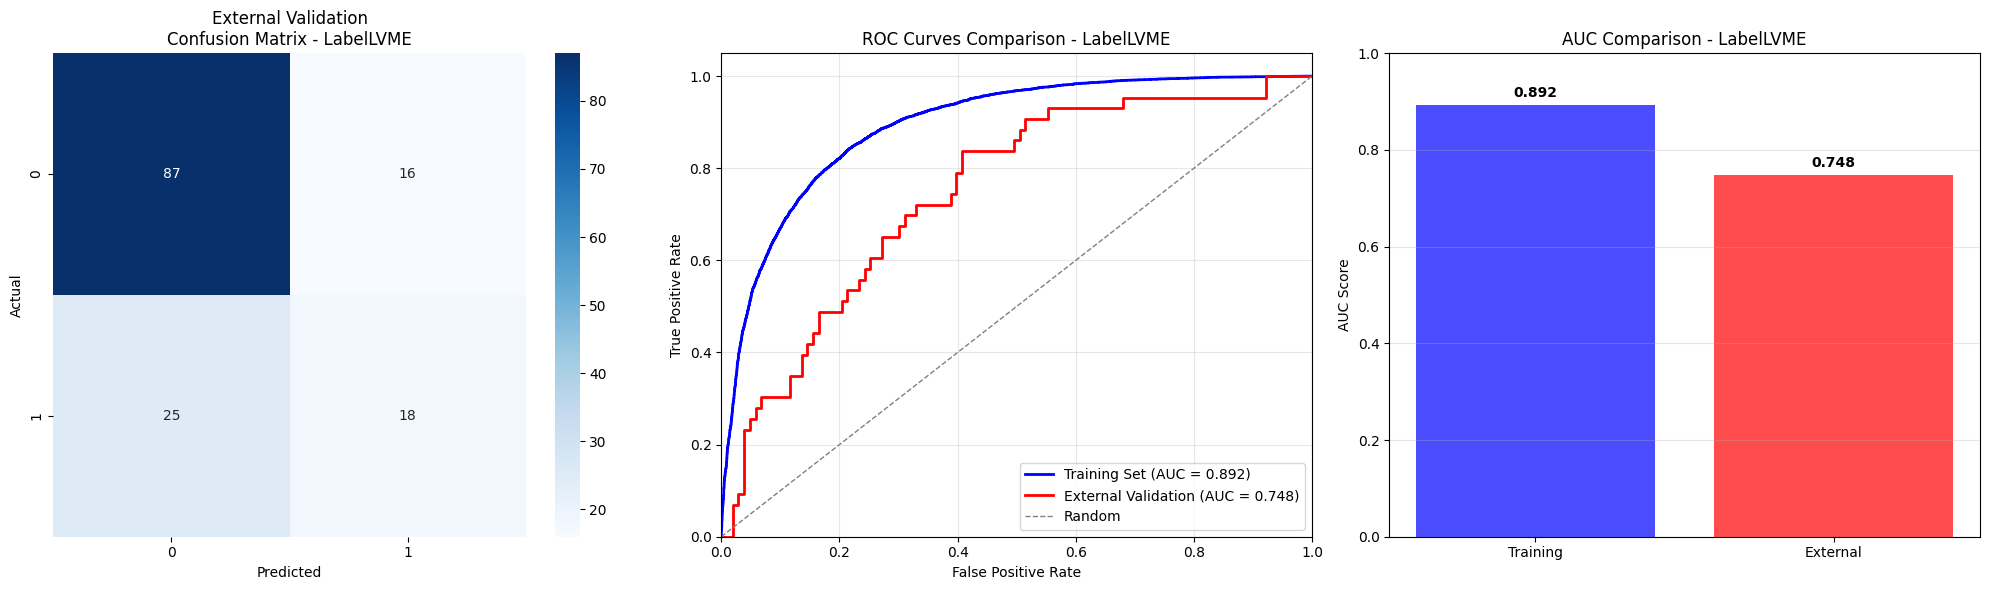

External Validation Results:
  AUC: 0.7476
  Accuracy: 0.7192
  Precision: 0.5294
  Recall: 0.4186
  F1-Score: 0.4675
Training vs External AUC Difference: 0.1446
⚠️  Large performance drop detected - possible overfitting

External Validation: LabelRVME


c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

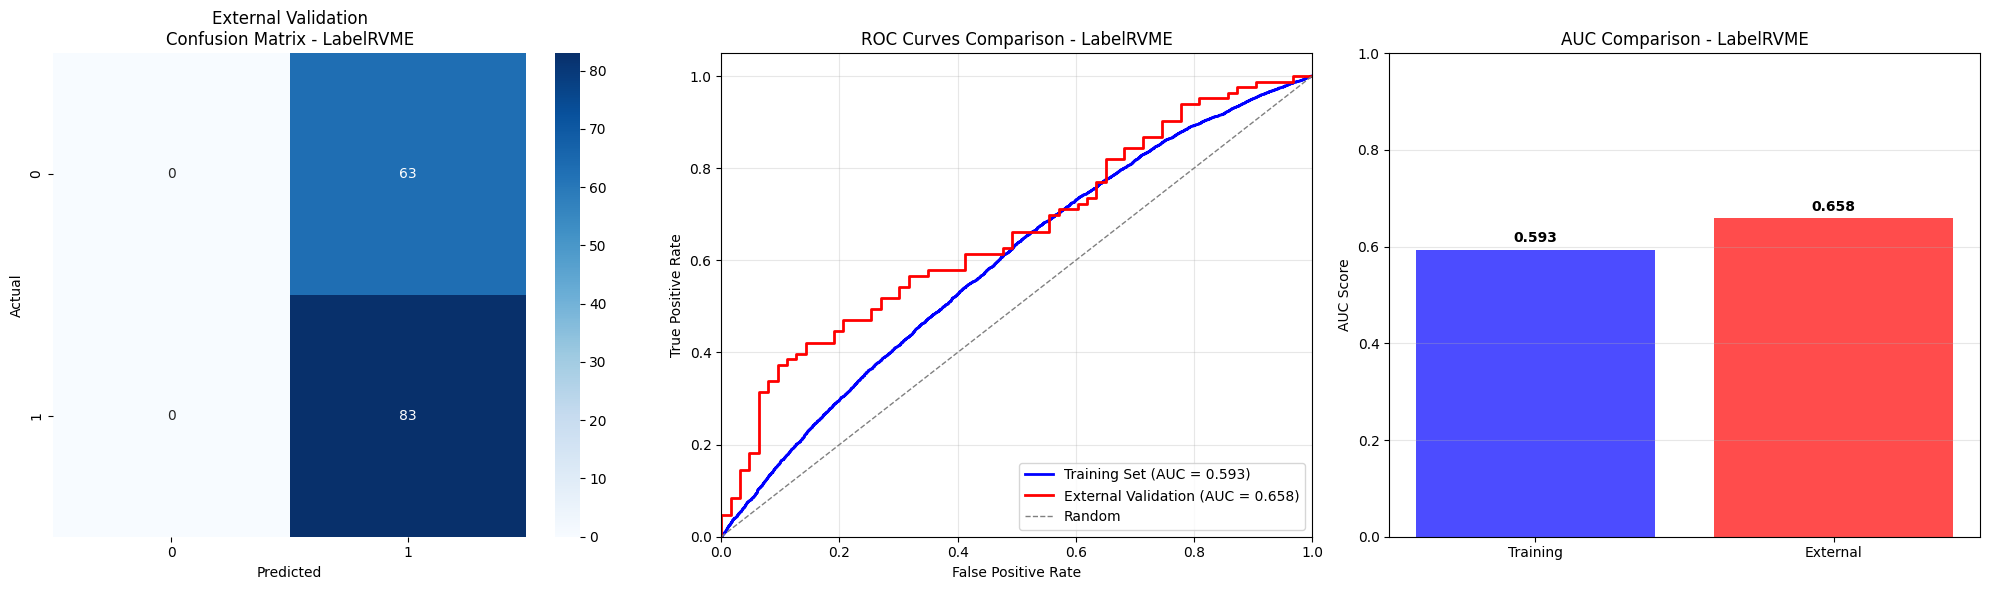

External Validation Results:
  AUC: 0.6581
  Accuracy: 0.5685
  Precision: 0.5685
  Recall: 1.0000
  F1-Score: 0.7249
Training vs External AUC Difference: -0.0653
✓ External validation performance better than training - good generalization

EXTERNAL VALIDATION COMPLETED!
All external validation plots saved in: external_validation_plots/

SUMMARY: Training vs External Validation Performance
Label           Train AUC  External AUC  Difference Status
-----------------------------------------------------------------
LabelFillingP   0.8937     0.7697        0.1240     ⚠️ Large Gap
LabelEF         0.8610     0.7761        0.0849     ✓ Good
LabelCO         0.8864     0.8454        0.0410     ✓ Good
LabelLAV        0.8669     0.8190        0.0479     ✓ Good
LabelRVO2E      0.8169     0.7183        0.0985     ✓ Good
LabelLVO2E      0.8258     0.8105        0.0153     ✓ Good
LabelLVMVO2     0.8498     0.8580        -0.0081    ✓ Better
LabelRVMVO2     0.8013     0.7637        0.0376     ✓ Good
La

In [12]:
# External Validation Set Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load external validation dataset
print("="*80)
print("EXTERNAL VALIDATION SET EVALUATION")
print("="*80)

# Load the external validation data
df_external = pd.read_csv('inputFGclassifier146.CSV')
print(f"✓ Successfully loaded external validation data: inputFGclassifier146.CSV")

# Preprocess external validation data (same as training data preprocessing)
external_processed = df_external.drop(df_external.columns[[0, 12]], axis=1)
external_features = external_processed.iloc[:, 0:17]
external_labels = external_processed.iloc[:, -10:]

print(f"\nExternal validation data shape:")
print(f"Features shape: {external_features.shape}")
print(f"Labels shape: {external_labels.shape}")

# Normalize external features using the same preprocessing pipeline as training
external_continuous = external_features.iloc[:, 1:-1]
external_normalized = scaler.transform(external_continuous)  # Use existing scaler from training

# Combine binary and normalized continuous features (same as training)
external_normalized_df = pd.DataFrame(external_normalized, columns=external_continuous.columns)
external_normalized_df.insert(0, external_features.columns[0], external_features.iloc[:, 0])  # First binary column
external_normalized_df[external_features.columns[-1]] = external_features.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_external_tensor = torch.tensor(external_normalized_df.values, dtype=torch.float32)

print(f"External validation tensor size: {X_external_tensor.size()}")
print(f"External validation labels columns: {external_labels.columns.tolist()}")

# Create directory for external validation plots
external_plot_dir = "external_validation_plots"
os.makedirs(external_plot_dir, exist_ok=True)

print("\n" + "="*80)
print("EVALUATING ALL CLASSIFIERS ON EXTERNAL VALIDATION SET")
print("="*80)

# Dictionary to store external validation results
external_results = {}

# Evaluate each trained model on external validation set
for i in range(labels.shape[1]):
    label_name = labels.columns[i]
    print(f"\n{'='*60}")
    print(f"External Validation: {label_name}")
    print(f"{'='*60}")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions on external validation set
        with torch.no_grad():
            X_external_device = X_external_tensor.to(device)
            external_outputs = eval_model(X_external_device)
            external_probs = external_outputs.cpu().numpy().flatten()
            external_preds = (external_probs > 0.5).astype(int)
            external_true = external_labels.iloc[:, i].values.astype(int)
        
        # Get training set predictions for comparison
        with torch.no_grad():
            X_train_device = X_train_tensor.to(device)
            train_outputs = eval_model(X_train_device)
            train_probs = train_outputs.cpu().numpy().flatten()
            train_true = y_train_tensor[:, i].numpy().astype(int)
        
        # Calculate metrics for external validation
        external_auc = roc_auc_score(external_true, external_probs)
        external_cm = confusion_matrix(external_true, external_preds)
        external_report = classification_report(external_true, external_preds, output_dict=True)
        
        # Calculate ROC curves
        external_fpr, external_tpr, _ = roc_curve(external_true, external_probs)
        train_fpr, train_tpr, _ = roc_curve(train_true, train_probs)
        
        # Store results
        external_results[label_name] = {
            'external_auc': external_auc,
            'external_cm': external_cm,
            'external_report': external_report,
            'external_fpr': external_fpr,
            'external_tpr': external_tpr
        }
        
        # Create comprehensive visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # 1. External Validation Confusion Matrix
        sns.heatmap(external_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
        axes[0].set_title(f'External Validation\nConfusion Matrix - {label_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # 2. Training vs External ROC Comparison
        axes[1].plot(train_fpr, train_tpr, color='blue', lw=2, 
                    label=f'Training Set (AUC = {roc_auc_score(train_true, train_probs):.3f})')
        axes[1].plot(external_fpr, external_tpr, color='red', lw=2, 
                    label=f'External Validation (AUC = {external_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'ROC Curves Comparison - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        # 3. Performance Metrics Comparison
        train_auc = roc_auc_score(train_true, train_probs)
        metrics_comparison = {
            'AUC': [train_auc, external_auc],
            'Dataset': ['Training', 'External']
        }
        
        bars = axes[2].bar(['Training', 'External'], [train_auc, external_auc], 
                          color=['blue', 'red'], alpha=0.7)
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('AUC Score')
        axes[2].set_title(f'AUC Comparison - {label_name}')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, value in zip(bars, [train_auc, external_auc]):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(external_plot_dir, f'{label_name}_external_validation.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detailed metrics
        print(f"External Validation Results:")
        print(f"  AUC: {external_auc:.4f}")
        print(f"  Accuracy: {external_report['accuracy']:.4f}")
        if '1' in external_report:
            print(f"  Precision: {external_report['1']['precision']:.4f}")
            print(f"  Recall: {external_report['1']['recall']:.4f}")
            print(f"  F1-Score: {external_report['1']['f1-score']:.4f}")
        
        print(f"Training vs External AUC Difference: {train_auc - external_auc:.4f}")
        
        if abs(train_auc - external_auc) > 0.1:
            print("⚠️  Large performance drop detected - possible overfitting")
        elif external_auc > train_auc:
            print("✓ External validation performance better than training - good generalization")
        else:
            print("✓ Acceptable performance on external validation")
            
    else:
        print(f"❌ Model file not found: {model_path}")

print("\n" + "="*80)
print("EXTERNAL VALIDATION COMPLETED!")
print(f"All external validation plots saved in: {external_plot_dir}/")
print("="*80)

# Summary table of all results
print(f"\n{'='*80}")
print("SUMMARY: Training vs External Validation Performance")
print(f"{'='*80}")
print(f"{'Label':<15} {'Train AUC':<10} {'External AUC':<13} {'Difference':<10} {'Status'}")
print("-" * 65)

for label_name in labels.columns:
    if label_name in external_results:
        # Get training AUC from evaluation_results if available
        if label_name in evaluation_results:
            train_auc = evaluation_results[label_name]['auc']
        else:
            # Fallback: load model and calculate
            model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
            if os.path.exists(model_path):
                eval_model = MLPClassifier(input_size=17).to(device)
                eval_model.load_state_dict(torch.load(model_path, map_location=device))
                eval_model.eval()
                with torch.no_grad():
                    X_train_device = X_train_tensor.to(device)
                    train_outputs = eval_model(X_train_device)
                    train_probs = train_outputs.cpu().numpy().flatten()
                    train_true = y_train_tensor[:, list(labels.columns).index(label_name)].numpy().astype(int)
                    train_auc = roc_auc_score(train_true, train_probs)
            else:
                train_auc = 0.0
                
        external_auc = external_results[label_name]['external_auc']
        diff = train_auc - external_auc
        
        if abs(diff) > 0.1:
            status = "⚠️ Large Gap"
        elif external_auc > train_auc:
            status = "✓ Better"
        else:
            status = "✓ Good"
            
        print(f"{label_name:<15} {train_auc:<10.4f} {external_auc:<13.4f} {diff:<10.4f} {status}")

print(f"\n✓ External validation complete! 146 patients evaluated across all 10 classifiers.")

In [13]:
# MYPACE Dataset Prediction with Missing Data Imputation
from sklearn.impute import KNNImputer
import pandas as pd
import numpy as np
import torch

print("="*80)
print("MYPACE DATASET PREDICTION")
print("="*80)

# Load MYPACE dataset
mypace_file_path = "inputFGclassifierMYPACE.CSV"
df_mypace = pd.read_csv(mypace_file_path)
print(f"✓ Successfully loaded MYPACE data from: {mypace_file_path}")
print(f"Original MYPACE data shape: {df_mypace.shape}")

# Display basic info about the dataset
print(f"\nMYPACE Dataset Info:")
print(f"Number of rows: {len(df_mypace)}")
print(f"Number of columns: {len(df_mypace.columns)}")
print(f"Column names: {df_mypace.columns.tolist()}")

# Clean and standardize missing values first
print(f"\n🔧 Cleaning missing values...")
# Replace various missing value representations with NaN
missing_values = ['N/a', 'n/a', 'N/A', 'NA', 'na', 'NaN', 'nan', '', ' ', 'null', 'NULL']
df_mypace = df_mypace.replace(missing_values, np.nan)

# Convert all columns to numeric where possible
for col in df_mypace.columns:
    try:
        df_mypace[col] = pd.to_numeric(df_mypace[col], errors='coerce')
    except:
        pass

print(f"✓ Missing value representations standardized to NaN")

# Check for missing values
missing_info = df_mypace.isnull().sum()
missing_percentage = (missing_info / len(df_mypace)) * 100
print(f"\nMissing Value Analysis:")
print("-" * 50)
for col, missing_count in missing_info.items():
    if missing_count > 0:
        print(f"{col:20s}: {missing_count:3d} missing ({missing_percentage[col]:.1f}%)")

total_missing = missing_info.sum()
if total_missing > 0:
    print(f"\nTotal missing values: {total_missing}")
else:
    print(f"\n✓ No missing values found in the dataset")

# Preprocess MYPACE data (same structure as training data)
# Remove the same columns as in training (column 0 and 12)
mypace_processed = df_mypace.drop(df_mypace.columns[[0, 12]], axis=1)

# Extract features (first 17 columns after preprocessing)
mypace_features = mypace_processed.iloc[:, 0:17]
print(f"\nMYPACE Features shape after preprocessing: {mypace_features.shape}")
print(f"Feature columns: {mypace_features.columns.tolist()}")

# Identify categorical columns (binary variables - first and last feature columns)
categorical_cols = [mypace_features.columns[0], mypace_features.columns[-1]]  # First and last columns
continuous_cols = mypace_features.columns[1:-1].tolist()  # Middle columns

print(f"\nCategorical columns (binary): {categorical_cols}")
print(f"Continuous columns: {continuous_cols}")

# Handle missing values using KNNImputer with K=5
if mypace_features.isnull().sum().sum() > 0:
    print(f"\n🔧 Applying KNN Imputation (K=5) for missing values...")
    
    # Separate categorical and continuous features for appropriate imputation
    mypace_categorical = mypace_features[categorical_cols].copy()
    mypace_continuous = mypace_features[continuous_cols].copy()
    
    # Check missing values in each type
    cat_missing = mypace_categorical.isnull().sum().sum()
    cont_missing = mypace_continuous.isnull().sum().sum()
    
    print(f"Missing in categorical features: {cat_missing}")
    print(f"Missing in continuous features: {cont_missing}")
    
    # Apply KNN imputation
    if cont_missing > 0:
        # For continuous features, use KNN imputation
        knn_imputer = KNNImputer(n_neighbors=5)
        mypace_continuous_imputed = knn_imputer.fit_transform(mypace_continuous)
        mypace_continuous_imputed = pd.DataFrame(mypace_continuous_imputed, 
                                                columns=mypace_continuous.columns,
                                                index=mypace_continuous.index)
        print(f"✓ KNN imputation applied to continuous features")
    else:
        mypace_continuous_imputed = mypace_continuous.copy()
    
    if cat_missing > 0:
        # For categorical features, use mode imputation or KNN with rounding
        knn_cat_imputer = KNNImputer(n_neighbors=5)
        mypace_categorical_imputed = knn_cat_imputer.fit_transform(mypace_categorical)
        # Round to nearest integer for binary variables
        mypace_categorical_imputed = np.round(mypace_categorical_imputed).astype(int)
        mypace_categorical_imputed = pd.DataFrame(mypace_categorical_imputed,
                                                 columns=mypace_categorical.columns,
                                                 index=mypace_categorical.index)
        print(f"✓ KNN imputation with rounding applied to categorical features")
    else:
        mypace_categorical_imputed = mypace_categorical.copy()
    
    # Combine imputed features
    mypace_features_imputed = pd.concat([
        mypace_categorical_imputed.iloc[:, [0]],  # First categorical column
        mypace_continuous_imputed,                 # All continuous columns
        mypace_categorical_imputed.iloc[:, [1]]   # Last categorical column
    ], axis=1)
    
    print(f"✓ Imputation completed. No missing values remaining: {mypace_features_imputed.isnull().sum().sum() == 0}")
    
else:
    mypace_features_imputed = mypace_features.copy()
    print(f"✓ No missing values to impute")

# Normalize MYPACE features using the same preprocessing pipeline as training
print(f"\n🔧 Normalizing MYPACE features using training scaler...")
mypace_continuous_imputed = mypace_features_imputed.iloc[:, 1:-1]
mypace_normalized = scaler.transform(mypace_continuous_imputed)  # Use existing scaler from training

# Combine binary and normalized continuous features (same as training)
mypace_normalized_df = pd.DataFrame(mypace_normalized, columns=mypace_continuous_imputed.columns)
mypace_normalized_df.insert(0, mypace_features_imputed.columns[0], mypace_features_imputed.iloc[:, 0])  # First binary column
mypace_normalized_df[mypace_features_imputed.columns[-1]] = mypace_features_imputed.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_mypace_tensor = torch.tensor(mypace_normalized_df.values, dtype=torch.float32)

print(f"✓ MYPACE tensor ready for prediction: {X_mypace_tensor.size()}")

# Predict labels using all trained classifiers
print(f"\n{'='*80}")
print("PREDICTING LABELS FOR MYPACE DATASET")
print(f"{'='*80}")

# Dictionary to store predictions
mypace_predictions = {}
mypace_probabilities = {}

# Predict using each trained model
for i, label_name in enumerate(labels.columns):
    print(f"\nPredicting {label_name}...")
    
    # Load the best model
    model_path = os.path.join(save_dir, f"model_{label_name}_best.pth")
    if os.path.exists(model_path):
        # Initialize and load model
        eval_model = MLPClassifier(input_size=17).to(device)
        eval_model.load_state_dict(torch.load(model_path, map_location=device))
        eval_model.eval()
        
        # Get predictions
        with torch.no_grad():
            X_mypace_device = X_mypace_tensor.to(device)
            mypace_outputs = eval_model(X_mypace_device)
            mypace_probs = mypace_outputs.cpu().numpy().flatten()
            mypace_preds = (mypace_probs > 0.5).astype(int)
        
        # Store predictions
        mypace_predictions[label_name] = mypace_preds
        mypace_probabilities[label_name] = mypace_probs
        
        # Print prediction statistics
        positive_count = np.sum(mypace_preds)
        positive_rate = positive_count / len(mypace_preds)
        mean_prob = np.mean(mypace_probs)
        
        print(f"  Positive predictions: {positive_count}/{len(mypace_preds)} ({positive_rate:.3f})")
        print(f"  Mean probability: {mean_prob:.4f}")
        print(f"  Probability range: [{np.min(mypace_probs):.4f}, {np.max(mypace_probs):.4f}]")
        
    else:
        print(f"❌ Model file not found: {model_path}")
        mypace_predictions[label_name] = np.zeros(len(df_mypace), dtype=int)
        mypace_probabilities[label_name] = np.zeros(len(df_mypace))

# Create results DataFrame
print(f"\n{'='*80}")
print("CREATING RESULTS TABLE")
print(f"{'='*80}")

# Start with original MYPACE data
df_mypace_with_predictions = df_mypace.copy()

# Add predicted labels and probabilities
for label_name in labels.columns:
    # Add binary predictions
    df_mypace_with_predictions[f'{label_name}'] = mypace_predictions[label_name]
    # Add probability scores (rounded to 4 decimal places for consistency)
    df_mypace_with_predictions[f'{label_name}_prob'] = np.round(mypace_probabilities[label_name], 4)

print(f"✓ Added predictions for all {len(labels.columns)} labels")
print(f"Final dataset shape: {df_mypace_with_predictions.shape}")

# Display prediction summary
print(f"\n📊 PREDICTION SUMMARY:")
print("-" * 80)
print(f"{'Label':<15} {'Negative (0)':<12} {'Positive (1)':<12} {'Pos Rate':<10} {'Mean Prob':<10}")
print("-" * 80)
for label_name in labels.columns:
    preds = mypace_predictions[label_name]
    probs = mypace_probabilities[label_name]
    
    # Count 0s and 1s
    neg_count = np.sum(preds == 0)  # Count of 0s (negative predictions)
    pos_count = np.sum(preds == 1)  # Count of 1s (positive predictions)
    pos_rate = pos_count / len(preds)
    mean_prob = np.mean(probs)
    
    print(f"{label_name:<15} {neg_count:<12} {pos_count:<12} {pos_rate:<10.3f} {mean_prob:<10.4f}")

# Additional detailed breakdown
print(f"\n📈 DETAILED PREDICTION BREAKDOWN:")
print("-" * 80)
total_patients = len(df_mypace)
print(f"Total patients processed: {total_patients}")
print(f"Labels analyzed: {len(labels.columns)}")

for label_name in labels.columns:
    preds = mypace_predictions[label_name]
    probs = mypace_probabilities[label_name]
    
    neg_count = np.sum(preds == 0)
    pos_count = np.sum(preds == 1)
    
    print(f"\n{label_name}:")
    print(f"  Negative (0): {neg_count:3d} patients ({neg_count/total_patients*100:5.1f}%)")
    print(f"  Positive (1): {pos_count:3d} patients ({pos_count/total_patients*100:5.1f}%)")
    print(f"  Mean probability: {np.mean(probs):.4f}")
    print(f"  Prob range: [{np.min(probs):.4f}, {np.max(probs):.4f}]")

# Save results back to file
output_path = mypace_file_path.replace('.CSV', '_with_predictions.CSV')
df_mypace_with_predictions.to_csv(output_path, index=False)

print(f"\n✅ COMPLETED!")
print(f"Results saved to: {output_path}")
print(f"Total patients processed: {len(df_mypace)}")
print(f"Added {len(labels.columns)} label predictions and {len(labels.columns)} probability scores")
print(f"Output columns: {len(df_mypace_with_predictions.columns)} (original: {len(df_mypace.columns)})")

# Display first few rows of results
print(f"\n📋 Sample Results (first 5 rows, prediction columns only):")
prediction_columns = [col for col in df_mypace_with_predictions.columns if col in labels.columns or col.endswith('_prob')]
print(df_mypace_with_predictions[prediction_columns].head())

MYPACE DATASET PREDICTION
✓ Successfully loaded MYPACE data from: inputFGclassifierMYPACE.CSV
Original MYPACE data shape: (107, 29)

MYPACE Dataset Info:
Number of rows: 107
Number of columns: 29
Column names: ['Patient_No', 'Sex', 'Height', 'Weight', 'SBP', 'DBP', 'EF', 'Hed_SW', 'Hed_LW', 'HR', 'LAVmax', 'EAr', 'IVRT', 'LVIDd', 'LVIDs', 'LVEDV', 'LVESV', 'PASP', 'TVr', 'LabelFillingP', 'LabelEF', 'LabelCO', 'LabelLAV', 'LabelRVO2E', 'LabelLVO2E', 'LabelLVMVO2', 'LabelRVMVO2', 'LabelLVME', 'LabelRVME']

🔧 Cleaning missing values...
✓ Missing value representations standardized to NaN

Missing Value Analysis:
--------------------------------------------------
SBP                 :   2 missing (1.9%)
DBP                 :   2 missing (1.9%)
EF                  :   2 missing (1.9%)
Hed_SW              :  18 missing (16.8%)
Hed_LW              :  19 missing (17.8%)
HR                  :   4 missing (3.7%)
LAVmax              :   8 missing (7.5%)
EAr                 :  30 missing (28.0%)
IV

[独立范围筛选] 参数：
  空间: original  分位数: [5%, 95%]  放宽比例: 10.0%  最小满足比例: 80%
  使用特征数: 17  (连续: 15, 分类: 2)
  训练样本总数: 24528  选中: 6910  比例: 28.17%

部分连续特征范围示例（原始单位/或归一化值）：
  - Height: [146.290, 193.930]
  - Weight: [45.198, 139.182]
  - SBP: [98.260, 171.940]
  - DBP: [57.000, 93.000]
  - EF: [51.000, 69.000]
  - Hed_SW: [9.440, 16.160]
  - Hed_LW: [8.500, 14.500]
  - HR: [58.500, 76.500]

DISTRIBUTION COMPARISON: Original vs MYPACE vs Selected Subset
Subset size: 6910
Saved: distribution_plots\continuous_distribution_original.png
Saved: distribution_plots\continuous_distribution_original.png


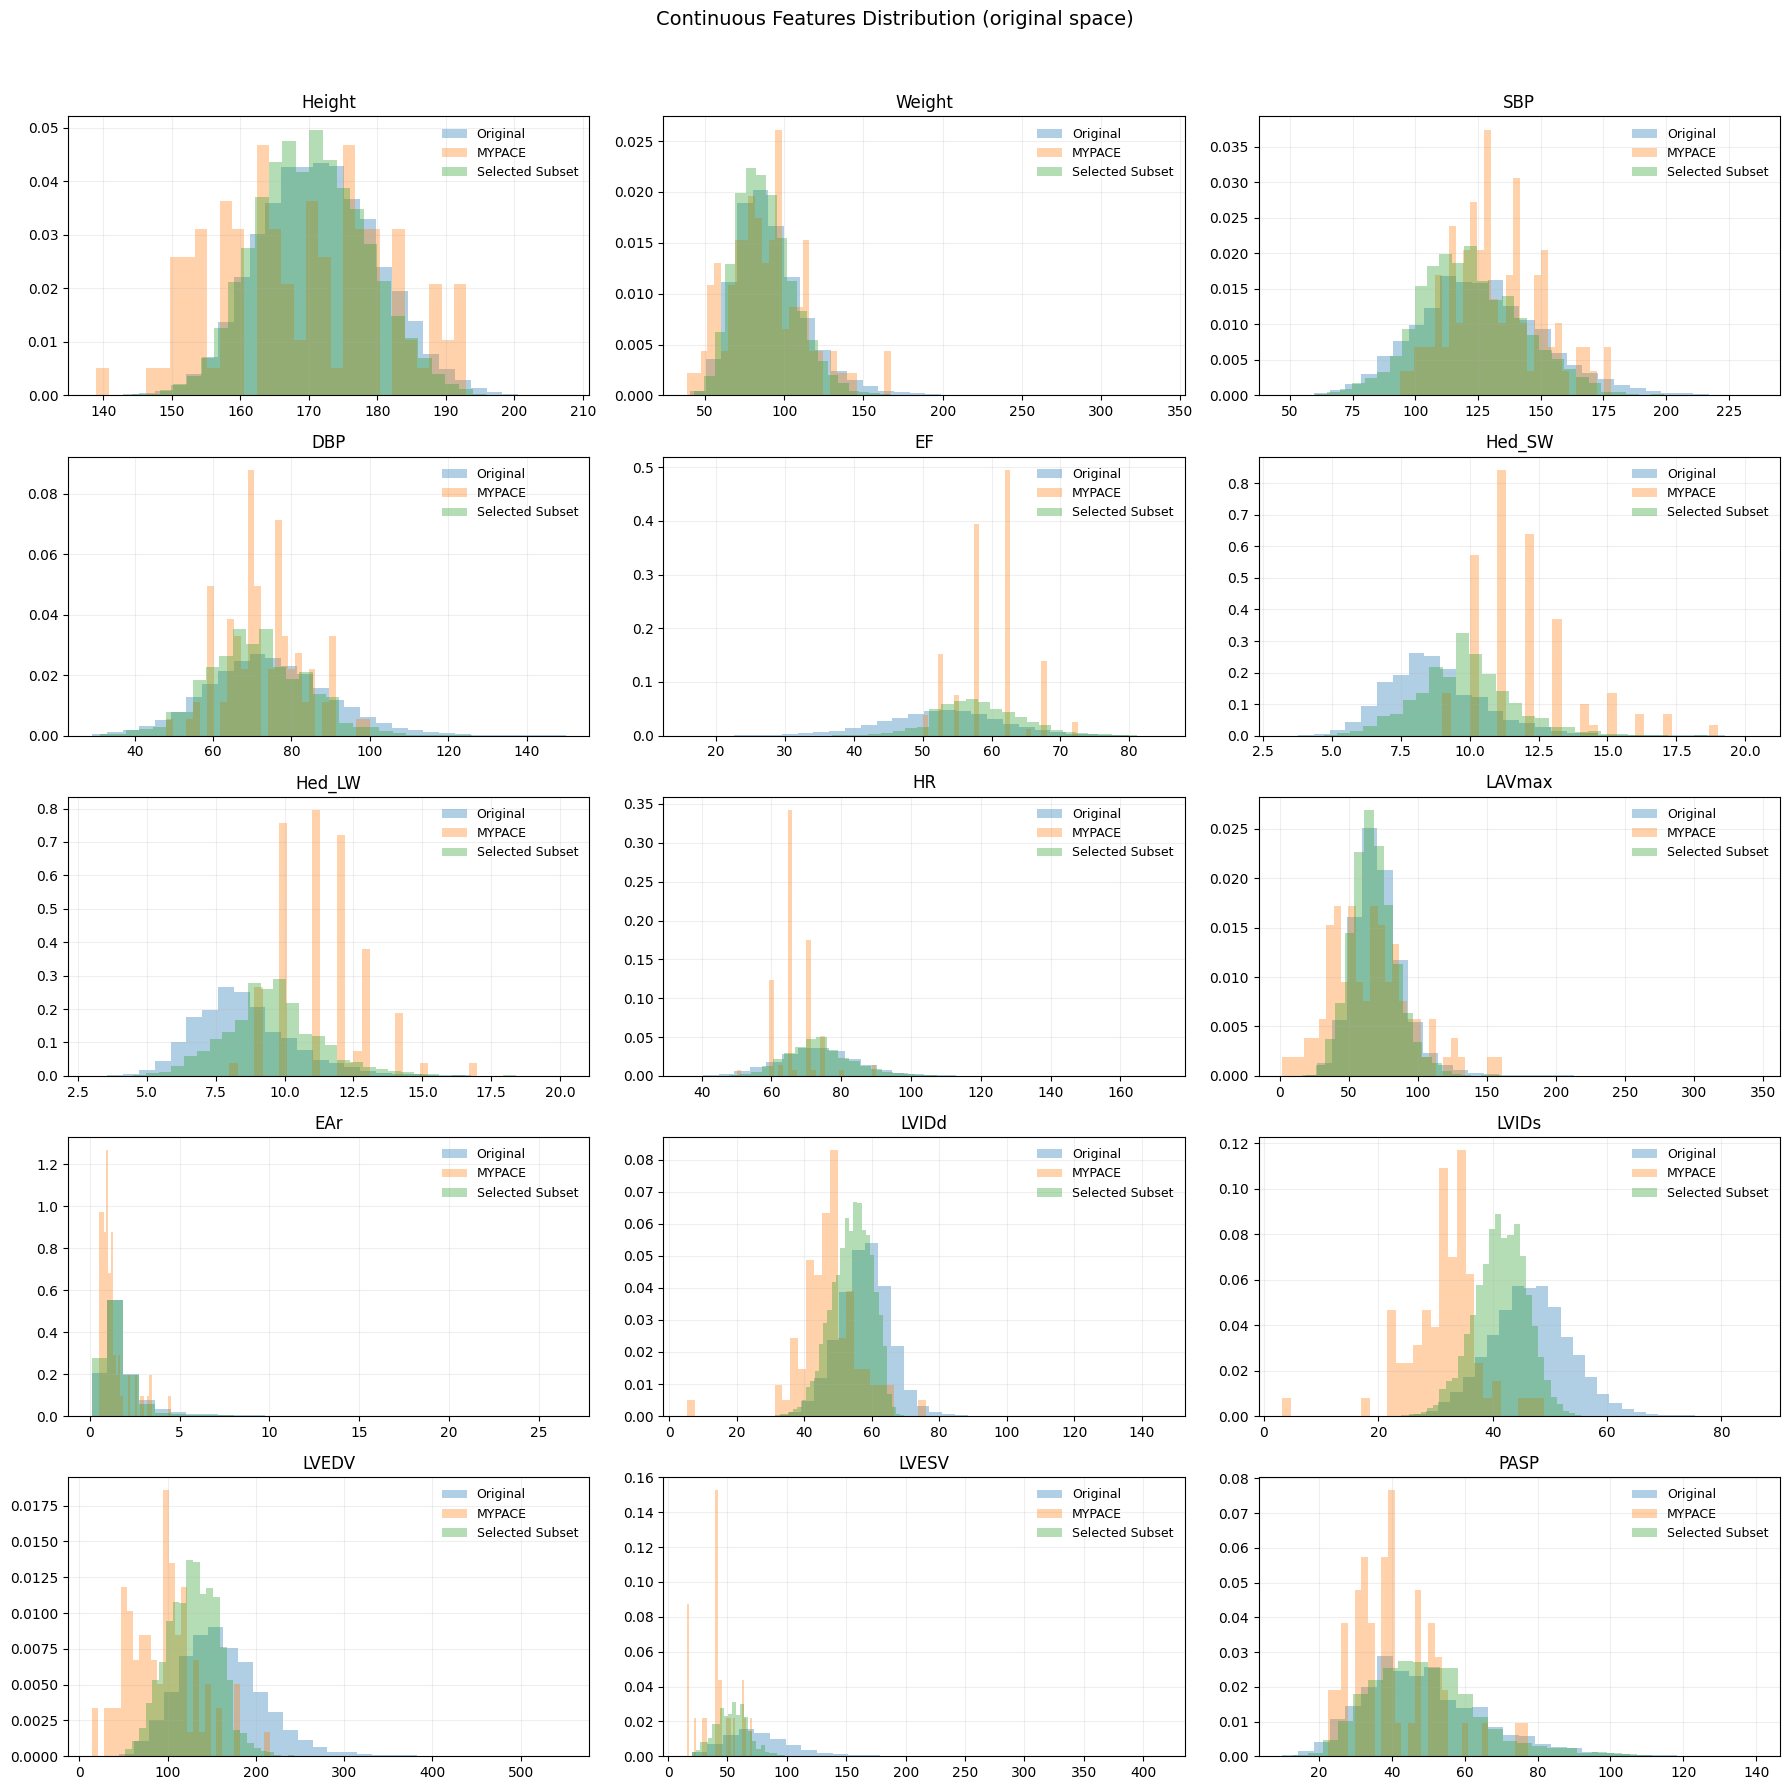

Saved: distribution_plots\categorical_distribution_original.png


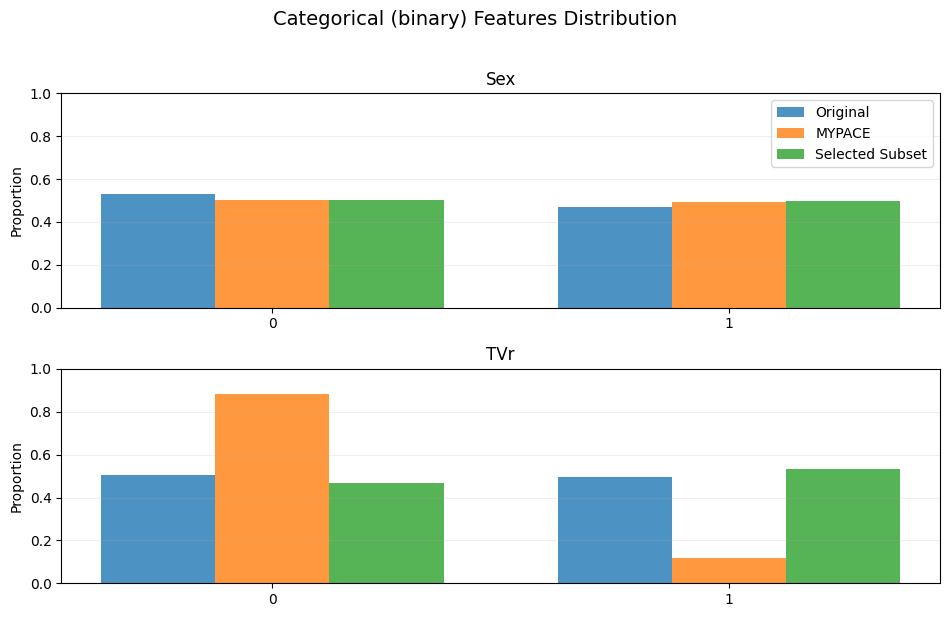

In [27]:
# 按每个特征的范围进行筛选（独立、粗范围，不学协方差）
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import math

# —— 可调参数 ——
space = "original"          # 选择在原始空间("original")还是归一化空间("normalized")做筛选
q_low, q_high = 5, 95        # MYPACE 分位数范围（如 5~95 更宽；10~90 更严格）
margin_frac = 0.1            # 在分位数范围外再放宽的比例（按区间宽度的百分比）
min_in_range_frac = 0.80     # 至少有多少比例的特征落在范围内才算“像”（0.8 即至少 80% 特征满足）

# —— 选择数据视图 ——
if space == "normalized":
    train_df = normalized_features.copy()
    mypace_df = mypace_normalized_df.copy()
else:
    train_df = features.copy()            # 原始单位，更直观（如心率 60-90）
    mypace_df = mypace_features.copy()

# 防御：仅使用双方都存在的列
common_cols = [c for c in train_df.columns if c in mypace_df.columns]
train_df = train_df[common_cols]
mypace_df = mypace_df[common_cols]

# 根据已存在的列，拆分连续 / 分类
active_cont_cols = [c for c in continuous_cols if c in common_cols]
active_cat_cols = [c for c in categorical_cols if c in common_cols]

# —— 连续特征：用 MYPACE 的分位数画“盒子范围”，再加少量边际放宽 ——
cont_ranges = {}
for col in active_cont_cols:
    s = mypace_df[col].dropna()
    if s.empty:
        continue
    lo = np.percentile(s, q_low)
    hi = np.percentile(s, q_high)
    width = hi - lo
    lo_adj = lo - width * margin_frac
    hi_adj = hi + width * margin_frac
    cont_ranges[col] = (lo_adj, hi_adj)

# —— 构造布尔矩阵：每列一个条件，行表示样本是否满足 ——
conds = []
col_names = []

for col in active_cont_cols:
    if col not in cont_ranges:
        continue
    lo_adj, hi_adj = cont_ranges[col]
    cond = train_df[col].ge(lo_adj) & train_df[col].le(hi_adj)
    conds.append(cond.fillna(False))
    col_names.append(col)

for col in active_cat_cols:
    allowed = set(mypace_df[col].dropna().unique())
    if len(allowed) == 0:
        continue
    cond = train_df[col].isin(allowed)
    conds.append(cond.fillna(False))
    col_names.append(col)

if len(conds) == 0:
    raise RuntimeError("没有可用于筛选的特征列（请检查 continuous_cols/categorical_cols 或数据列名）。")

cond_df = pd.concat(conds, axis=1)
cond_df.columns = col_names

# —— 至少满足一定比例特征在范围内 ——
ratio_in_range = cond_df.sum(axis=1) / cond_df.shape[1]
mask = ratio_in_range >= min_in_range_frac

selected_indices = np.flatnonzero(mask.to_numpy()).tolist()
selected_subset_indices = selected_indices  # 覆盖之前的选择结果

# —— 结果汇报 ——
print("[独立范围筛选] 参数：")
print(f"  空间: {space}  分位数: [{q_low}%, {q_high}%]  放宽比例: {margin_frac*100:.1f}%  最小满足比例: {min_in_range_frac*100:.0f}%")
print(f"  使用特征数: {cond_df.shape[1]}  (连续: {len(cont_ranges)}, 分类: {cond_df.shape[1]-len(cont_ranges)})")
print(f"  训练样本总数: {len(train_df)}  选中: {len(selected_subset_indices)}  比例: {len(selected_subset_indices)/len(train_df)*100:.2f}%")

# 展示前若干个连续特征的范围示例
show_cols = list(cont_ranges.keys())[:8]
if show_cols:
    print("\n部分连续特征范围示例（原始单位/或归一化值）：")
    for c in show_cols:
        lo_adj, hi_adj = cont_ranges[c]
        print(f"  - {c}: [{lo_adj:.3f}, {hi_adj:.3f}]")

# —— 可视化：原始数据 vs MYPACE vs 选中子集 ——
print("\n" + "="*80)
print("DISTRIBUTION COMPARISON: Original vs MYPACE vs Selected Subset")
print("="*80)

# 输出目录
out_dir = "distribution_plots"
os.makedirs(out_dir, exist_ok=True)

subset_df = train_df.iloc[selected_subset_indices].copy() if len(selected_subset_indices) > 0 else train_df.iloc[[]].copy()
has_subset = len(subset_df) > 0
print(f"Subset size: {len(subset_df)}")

# 1) 连续特征分布（叠加直方图，密度归一；每个子图右上角放 legend）
if active_cont_cols:
    n = len(active_cont_cols)
    ncols = 3
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(6*ncols, 3.5*nrows), squeeze=False)
    for idx, col in enumerate(active_cont_cols):
        r, c = divmod(idx, ncols)
        ax = axes[r][c]
        ax.hist(train_df[col].dropna(), bins=30, alpha=0.35, density=True, label='Original', color='#1f77b4')
        ax.hist(mypace_df[col].dropna(), bins=30, alpha=0.35, density=True, label='MYPACE', color='#ff7f0e')
        if has_subset:
            ax.hist(subset_df[col].dropna(), bins=30, alpha=0.35, density=True, label='Selected Subset', color='#2ca02c')
        ax.set_title(col)
        ax.grid(alpha=0.2)
        # 子图右上角 legend
        ax.legend(loc='upper right', frameon=False, fontsize=9)
    # 隐藏多余子图
    for k in range(n, nrows*ncols):
        r, c = divmod(k, ncols)
        axes[r][c].axis('off')
    fig.suptitle(f"Continuous Features Distribution ({'normalized' if space=='normalized' else 'original'} space)", y=1.02, fontsize=14)
    plt.tight_layout()
    # 保存图片
    cont_path = os.path.join(out_dir, f"continuous_distribution_{space}.png")
    plt.savefig(cont_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {cont_path}")
    plt.show()
else:
    print("No continuous features available for plotting.")

# 2) 分类（二元）特征分布（分组柱状：比例）
if active_cat_cols:
    fig, axes = plt.subplots(len(active_cat_cols), 1, figsize=(9.6, 3*len(active_cat_cols)))
    if len(active_cat_cols) == 1:
        axes = [axes]
    for j, col in enumerate(active_cat_cols):
        ax = axes[j]
        # 计算比例
        train_props = train_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values
        mypace_props = mypace_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values
        subset_props = (subset_df[col].value_counts(normalize=True).reindex([0, 1]).fillna(0).values if has_subset else np.array([0, 0]))
        x = np.array([0, 1], dtype=float)
        width = 0.25
        ax.bar(x - width, train_props, width, label='Original', color='#1f77b4', alpha=0.8)
        ax.bar(x,         mypace_props, width, label='MYPACE',   color='#ff7f0e', alpha=0.8)
        if has_subset:
            ax.bar(x + width, subset_props, width, label='Selected Subset', color='#2ca02c', alpha=0.8)
        ax.set_xticks([0, 1]); ax.set_xticklabels(['0', '1'])
        ax.set_ylim(0, 1)
        ax.set_ylabel('Proportion')
        ax.set_title(col)
        ax.grid(axis='y', alpha=0.2)
        if j == 0:
            ax.legend(loc='upper right')
    fig.suptitle("Categorical (binary) Features Distribution", y=1.02, fontsize=14)
    plt.tight_layout()
    # 保存图片
    cat_path = os.path.join(out_dir, f"categorical_distribution_{space}.png")
    plt.savefig(cat_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {cat_path}")
    plt.show()
else:
    print("No categorical features available for plotting.")

In [28]:
# Subset Training Pipeline Based on MYPACE-Similar Patients
import time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

print("="*80)
print("MYPACE-SIMILAR SUBSET TRAINING PIPELINE")
print("="*80)

print("🎯 Training new models on MYPACE-similar patient subset")
print(f"📊 Subset size: {len(selected_subset_indices)} patients ({len(selected_subset_indices)/len(training_for_analysis)*100:.1f}% of original)")

# Create subset training data
subset_features = features.iloc[selected_subset_indices].copy()
subset_labels = labels.iloc[selected_subset_indices].copy()

# Fit scaler on subset ONLY (continuous features: middle columns)
subset_continuous = subset_features.iloc[:, 1:-1].copy()
subset_scaler = MinMaxScaler()  # 基于子集重新拟合
subset_normalized_cont = subset_scaler.fit_transform(subset_continuous)

# 记录子集的 min/max 供外部数据剪裁使用
subset_cont_mins = pd.Series(subset_continuous.min(), name="min")
subset_cont_maxs = pd.Series(subset_continuous.max(), name="max")

# Reconstruct normalized subset with binary columns unchanged
subset_normalized = pd.DataFrame(subset_normalized_cont, columns=subset_continuous.columns, index=subset_features.index)
subset_normalized.insert(0, subset_features.columns[0], subset_features.iloc[:, 0])  # First binary
subset_normalized[subset_features.columns[-1]] = subset_features.iloc[:, -1]        # Last binary

print(f"\nSubset data shapes:")
print(f"Features: {subset_features.shape}")
print(f"Labels: {subset_labels.shape}")
print(f"Normalized (subset-fitted scaler): {subset_normalized.shape}")

# Convert to tensors
subset_input_tensor = torch.tensor(subset_normalized.values, dtype=torch.float32)

# Split subset into training and validation
X_subset_train, X_subset_val, y_subset_train, y_subset_val = train_test_split(
    subset_input_tensor.numpy(), subset_labels.values, test_size=0.2, random_state=42
)

# Convert to PyTorch tensors
X_subset_train_tensor = torch.tensor(X_subset_train, dtype=torch.float32)
X_subset_val_tensor = torch.tensor(X_subset_val, dtype=torch.float32)
y_subset_train_tensor = torch.tensor(y_subset_train, dtype=torch.float32)
y_subset_val_tensor = torch.tensor(y_subset_val, dtype=torch.float32)

print(f"\nSubset training split:")
print(f"Training samples: {len(X_subset_train)}")
print(f"Validation samples: {len(X_subset_val)}")

# Create DataLoader for subset training
subset_train_dataset = torch_data.TensorDataset(X_subset_train_tensor, y_subset_train_tensor)
subset_train_loader = torch_data.DataLoader(subset_train_dataset, batch_size=batch_size, shuffle=True)

# Directory to save subset models
subset_save_dir = "saved_models_mypace_subset"
os.makedirs(subset_save_dir, exist_ok=True)

print(f"\n🔧 Training parameters:")
print(f"Batch size: {batch_size}")
print(f"Learning rate: {learning_rate}")
print(f"Max epochs: {num_epochs}")
print(f"Device: {device}")

# Train models on subset data
print(f"\n" + "="*80)
print("TRAINING CLASSIFIERS ON MYPACE-SIMILAR SUBSET")
print("="*80)

subset_training_results = {}

for i in range(subset_labels.shape[1]):
    label_name = subset_labels.columns[i]
    start_time = time.time()
    print(f"\n{'='*60}")
    print(f"Training SUBSET classifier for {label_name}... (Label {i+1}/{subset_labels.shape[1]})")
    print(f"{'='*60}")
    
    # Check label distribution in subset
    subset_label_dist = subset_labels[label_name].value_counts()
    pos_count = subset_label_dist.get(1, 0)
    neg_count = subset_label_dist.get(0, 0)
    total_count = pos_count + neg_count
    
    print(f"Subset label distribution for {label_name}:")
    print(f"  Positive (1): {pos_count} ({pos_count/total_count*100:.1f}%)")
    print(f"  Negative (0): {neg_count} ({neg_count/total_count*100:.1f}%)")
    
    # Skip if too few positive samples
    if pos_count < 5:
        print(f"⚠️  Skipping {label_name} - too few positive samples ({pos_count})")
        continue
    
    # Initialize model for subset training
    subset_model = MLPClassifier(input_size=17).to(device)
    criterion = nn.BCELoss()
    optimizer = optim.Adam(subset_model.parameters(), lr=learning_rate)
    
    best_val_auc = 0.0
    best_loss = float('inf')
    early_stop = False
    epoch_count = 0
    
    # Training loop
    for epoch in range(num_epochs):
        if early_stop:
            break
            
        epoch_count += 1
        subset_model.train()
        epoch_loss = 0.0
        
        for batch_X, batch_y in subset_train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)
            batch_y = batch_y[:, i].unsqueeze(1)
            
            outputs = subset_model(batch_X)
            loss = criterion(outputs, batch_y)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
        
        # Validation
        subset_model.eval()
        with torch.no_grad():
            X_subset_val_device = X_subset_val_tensor.to(device)
            val_outputs = subset_model(X_subset_val_device)
            val_labels_device = y_subset_val_tensor[:, i].unsqueeze(1).to(device)
            
            # Only calculate AUC if we have both classes in validation set
            val_labels_np = val_labels_device.cpu().numpy()
            val_outputs_np = val_outputs.cpu().numpy()
            
            if len(np.unique(val_labels_np)) > 1:
                val_auc = roc_auc_score(val_labels_np, val_outputs_np)
            else:
                val_auc = 0.5  # Default AUC when only one class present
        
        # Save best model
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            best_loss = epoch_loss
            subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
            torch.save(subset_model.state_dict(), subset_model_path)
        
        # Progress display
        if epoch_count % 10 == 0 or val_auc > (best_val_auc - 0.001):
            print(f"[{label_name}] Epoch {epoch+1:4d} | Best AUC: {best_val_auc:.4f} | Best Loss: {best_loss:.4f}")
        
        # Early stopping
        if best_val_auc >= 0.975:
            print(f"[{label_name}] ✓ Early stopping! Best AUC: {best_val_auc:.4f}")
            early_stop = True
    
    elapsed_time = time.time() - start_time
    print(f"[{label_name}] ✓ SUBSET TRAINING COMPLETED | Best AUC: {best_val_auc:.4f} | Time: {elapsed_time:.1f}s | Epochs: {epoch_count}")
    
    # Store results
    subset_training_results[label_name] = {
        'best_auc': best_val_auc,
        'best_loss': best_loss,
        'epochs': epoch_count,
        'time': elapsed_time,
        'pos_samples': pos_count,
        'neg_samples': neg_count
    }

print(f"\n" + "="*80)
print("SUBSET TRAINING SUMMARY")
print("="*80)

print(f"{'Label':<15} {'AUC':<8} {'Pos/Neg':<10} {'Epochs':<8} {'Time(s)':<8}")
print("-" * 60)
for label_name, results in subset_training_results.items():
    pos_neg = f"{results['pos_samples']}/{results['neg_samples']}"
    print(f"{label_name:<15} {results['best_auc']:<8.4f} {pos_neg:<10} {results['epochs']:<8} {results['time']:<8.1f}")

print(f"\n✅ Subset training completed!")
print(f"📁 Models saved in: {subset_save_dir}/")
print(f"📊 {len(subset_training_results)} classifiers trained on MYPACE-similar subset")
print(f"🔄 Ready for subset model evaluation and MYPACE prediction comparison!")

MYPACE-SIMILAR SUBSET TRAINING PIPELINE
🎯 Training new models on MYPACE-similar patient subset
📊 Subset size: 6910 patients (28.2% of original)

Subset data shapes:
Features: (6910, 17)
Labels: (6910, 10)
Normalized (subset-fitted scaler): (6910, 17)

Subset training split:
Training samples: 5528
Validation samples: 1382

🔧 Training parameters:
Batch size: 48
Learning rate: 0.0005
Max epochs: 5000
Device: cuda

TRAINING CLASSIFIERS ON MYPACE-SIMILAR SUBSET

Training SUBSET classifier for LabelFillingP... (Label 1/10)
Subset label distribution for LabelFillingP:
  Positive (1): 2058 (29.8%)
  Negative (0): 4852 (70.2%)
[LabelFillingP] Epoch    1 | Best AUC: 0.7607 | Best Loss: 78.2914
[LabelFillingP] Epoch    1 | Best AUC: 0.7607 | Best Loss: 78.2914
[LabelFillingP] Epoch    2 | Best AUC: 0.7886 | Best Loss: 71.8793
[LabelFillingP] Epoch    2 | Best AUC: 0.7886 | Best Loss: 71.8793
[LabelFillingP] Epoch    3 | Best AUC: 0.8032 | Best Loss: 67.2141
[LabelFillingP] Epoch    3 | Best AUC: 

SUBSET MODEL EVALUATION - PARALLEL PIPELINE
🎯 Complete parallel evaluation of MYPACE-subset trained models
📊 Same evaluation pipeline as original models

SUBSET MODEL EVALUATION ON VALIDATION SET

Evaluating SUBSET model: LabelFillingP...


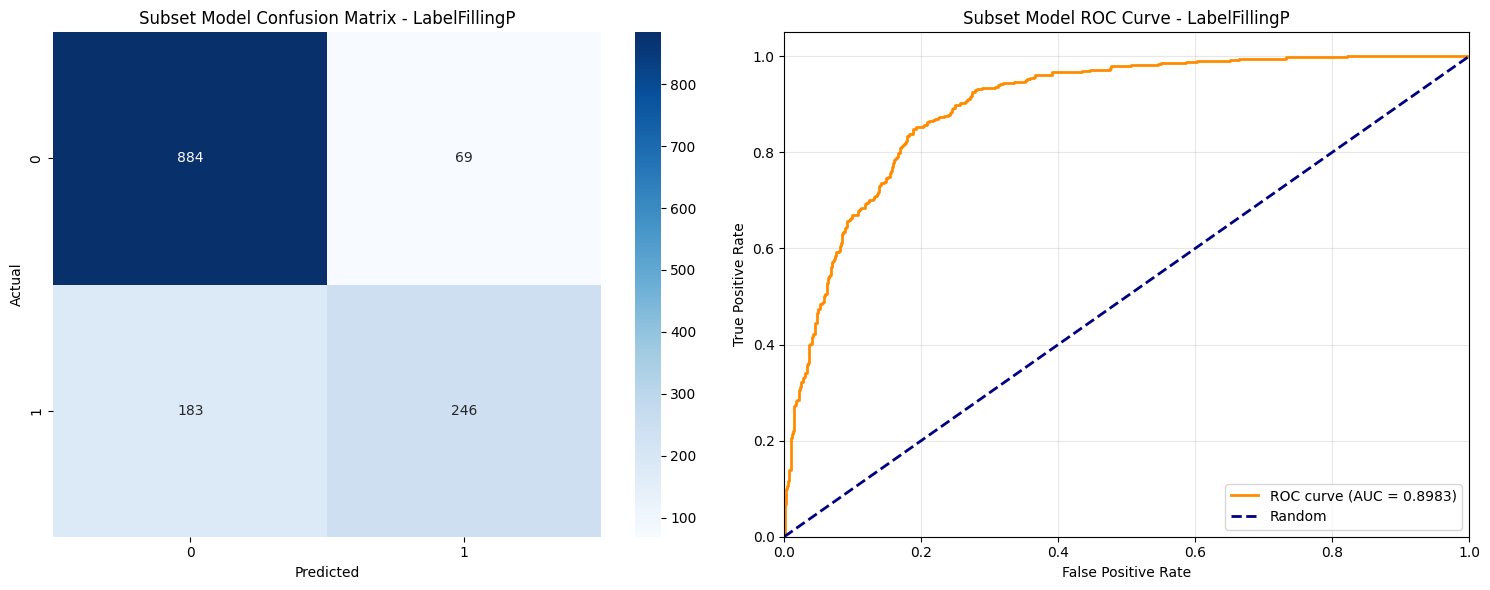

Subset Model AUC: 0.8983
Accuracy: 0.8177
Precision: 0.7810
Recall: 0.5734
F1-Score: 0.6613

Evaluating SUBSET model: LabelEF...


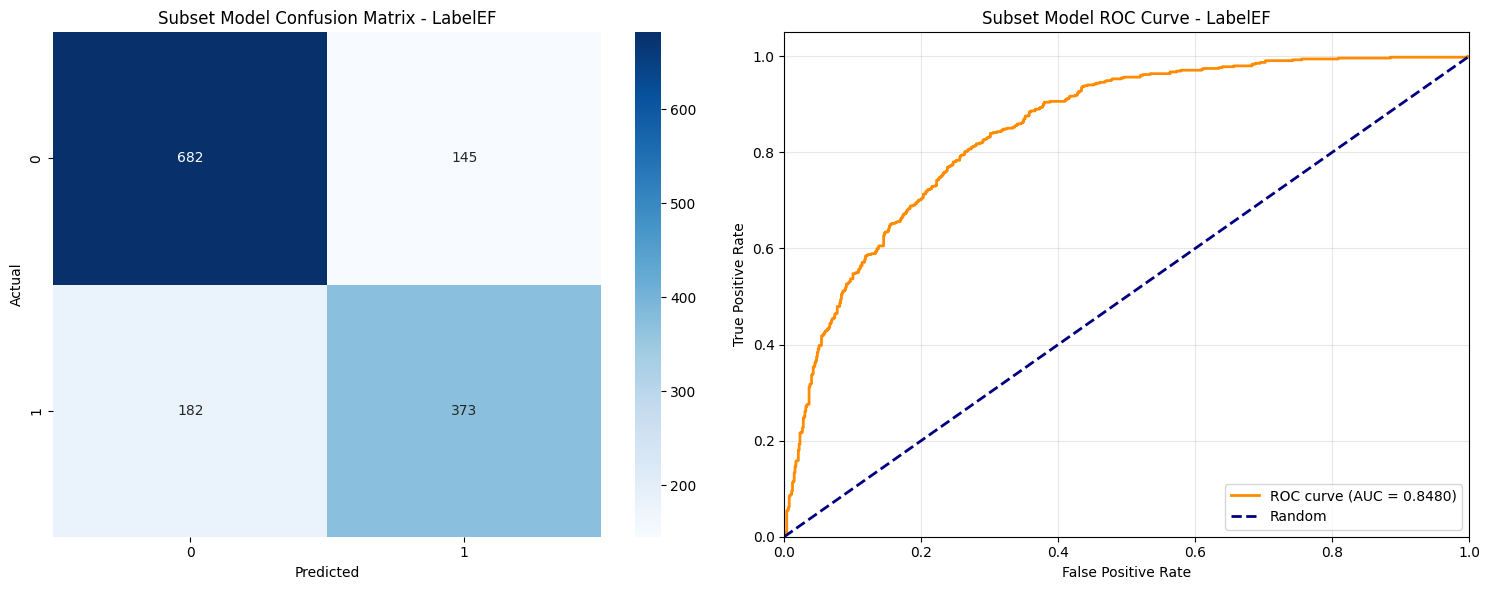

Subset Model AUC: 0.8480
Accuracy: 0.7634
Precision: 0.7201
Recall: 0.6721
F1-Score: 0.6952

Evaluating SUBSET model: LabelCO...


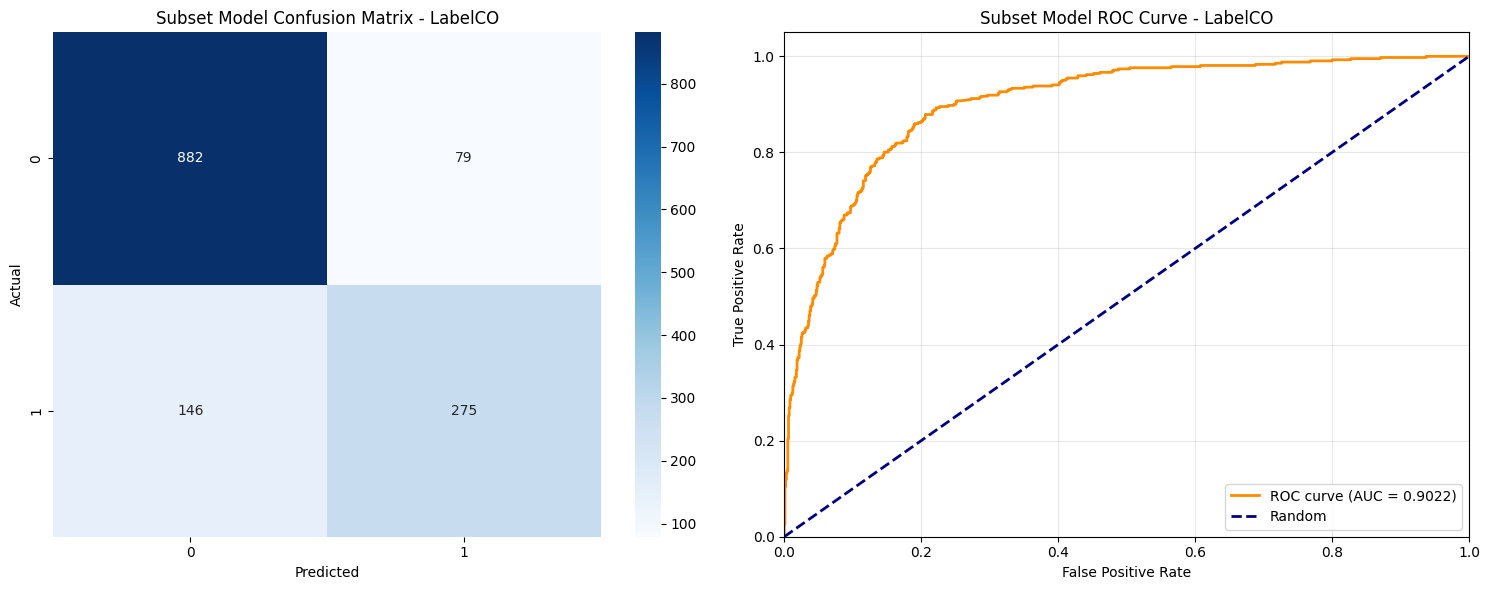

Subset Model AUC: 0.9022
Accuracy: 0.8372
Precision: 0.7768
Recall: 0.6532
F1-Score: 0.7097

Evaluating SUBSET model: LabelLAV...


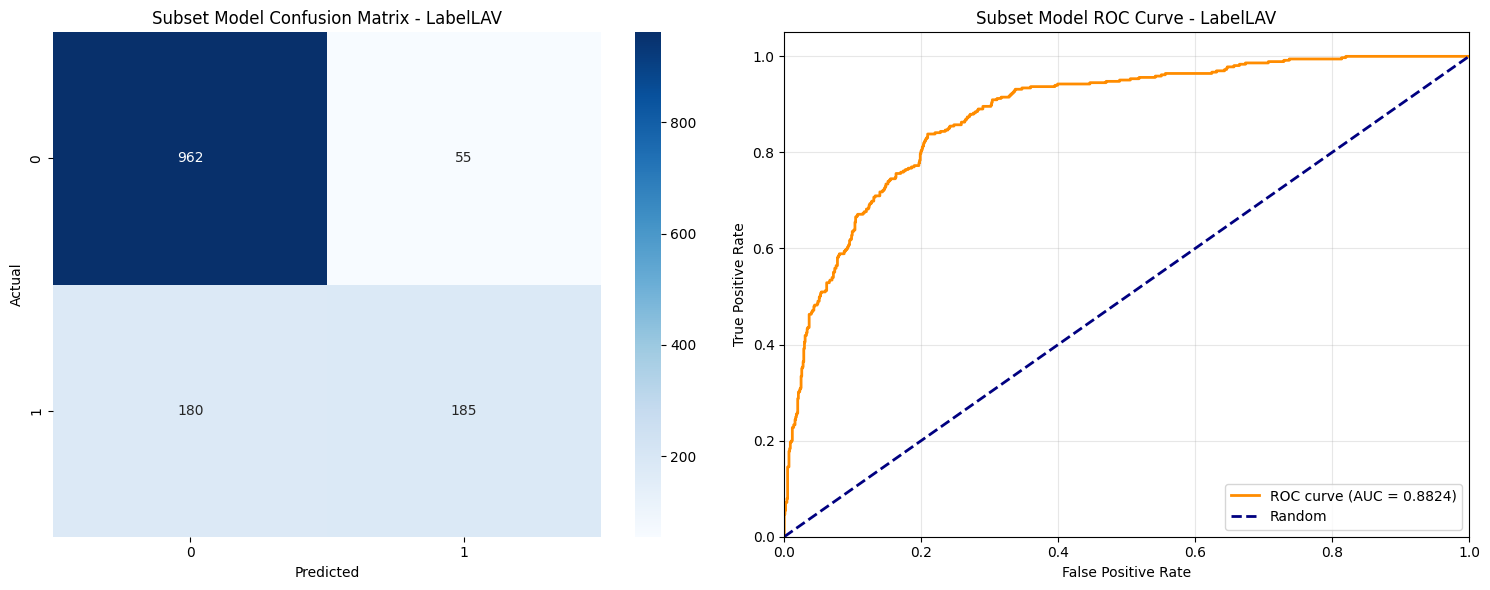

Subset Model AUC: 0.8824
Accuracy: 0.8300
Precision: 0.7708
Recall: 0.5068
F1-Score: 0.6116

Evaluating SUBSET model: LabelRVO2E...


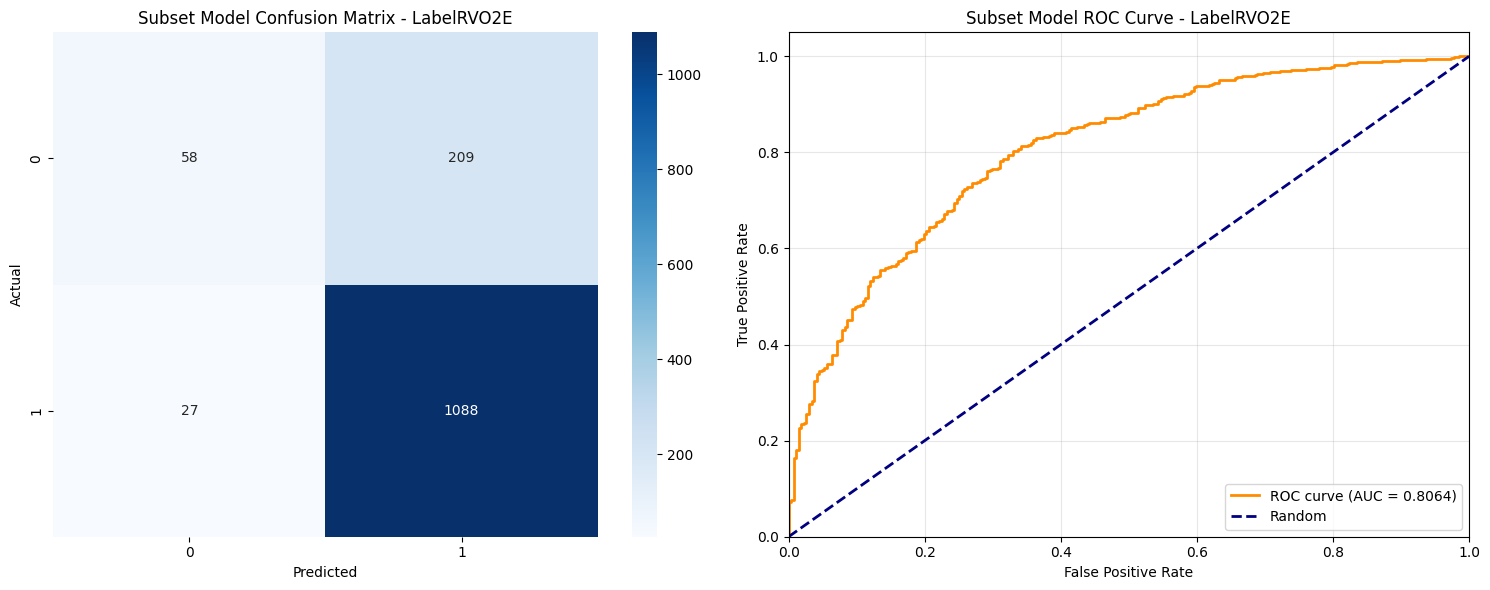

Subset Model AUC: 0.8064
Accuracy: 0.8292
Precision: 0.8389
Recall: 0.9758
F1-Score: 0.9022

Evaluating SUBSET model: LabelLVO2E...


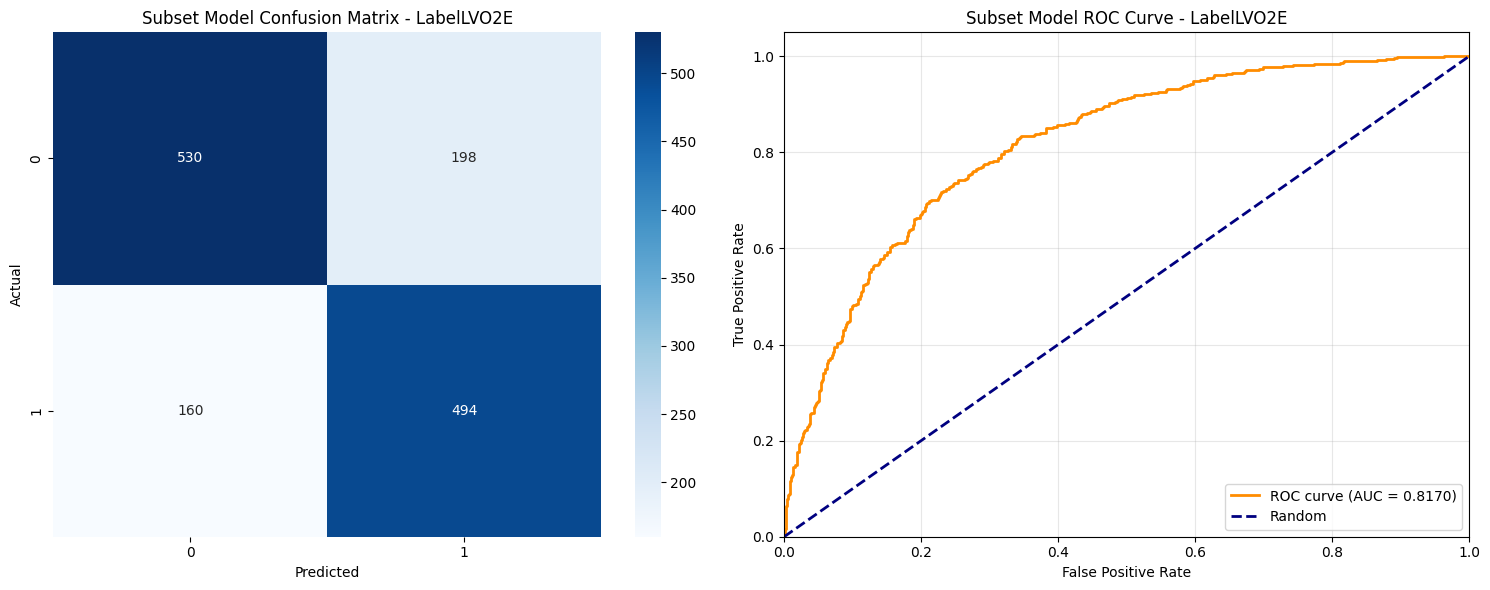

Subset Model AUC: 0.8170
Accuracy: 0.7410
Precision: 0.7139
Recall: 0.7554
F1-Score: 0.7340

Evaluating SUBSET model: LabelLVMVO2...


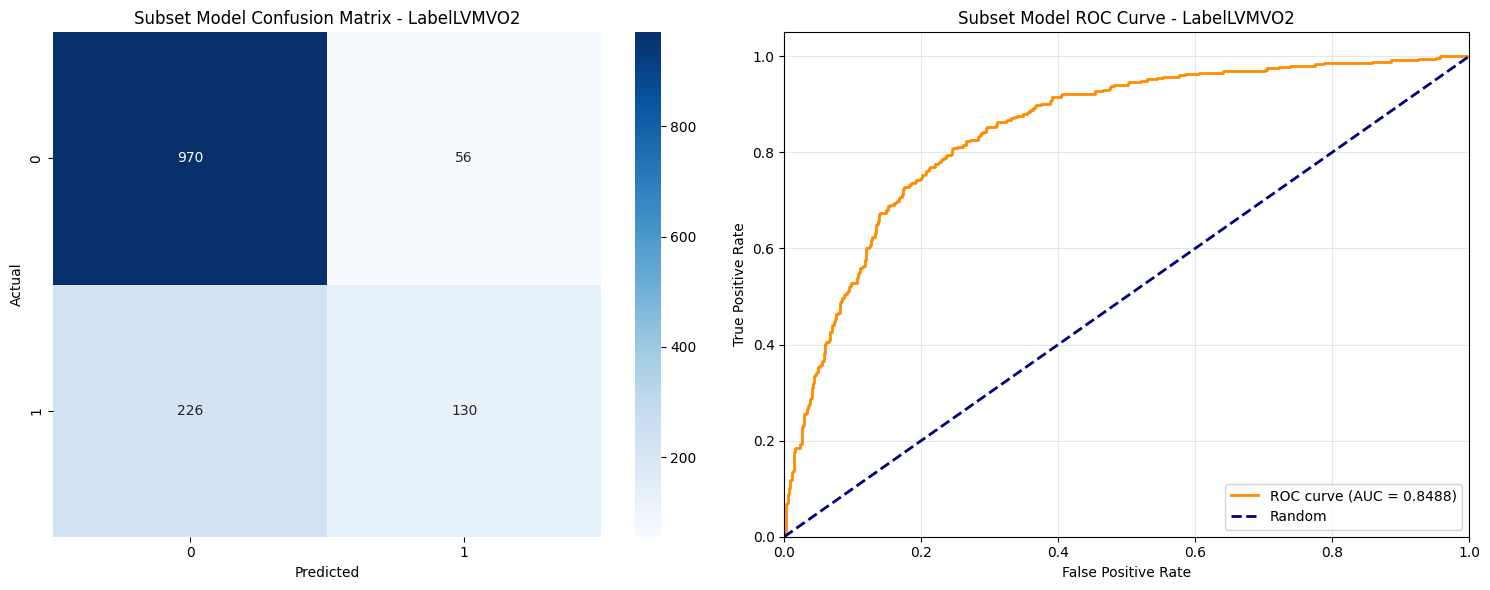

Subset Model AUC: 0.8488
Accuracy: 0.7959
Precision: 0.6989
Recall: 0.3652
F1-Score: 0.4797

Evaluating SUBSET model: LabelRVMVO2...


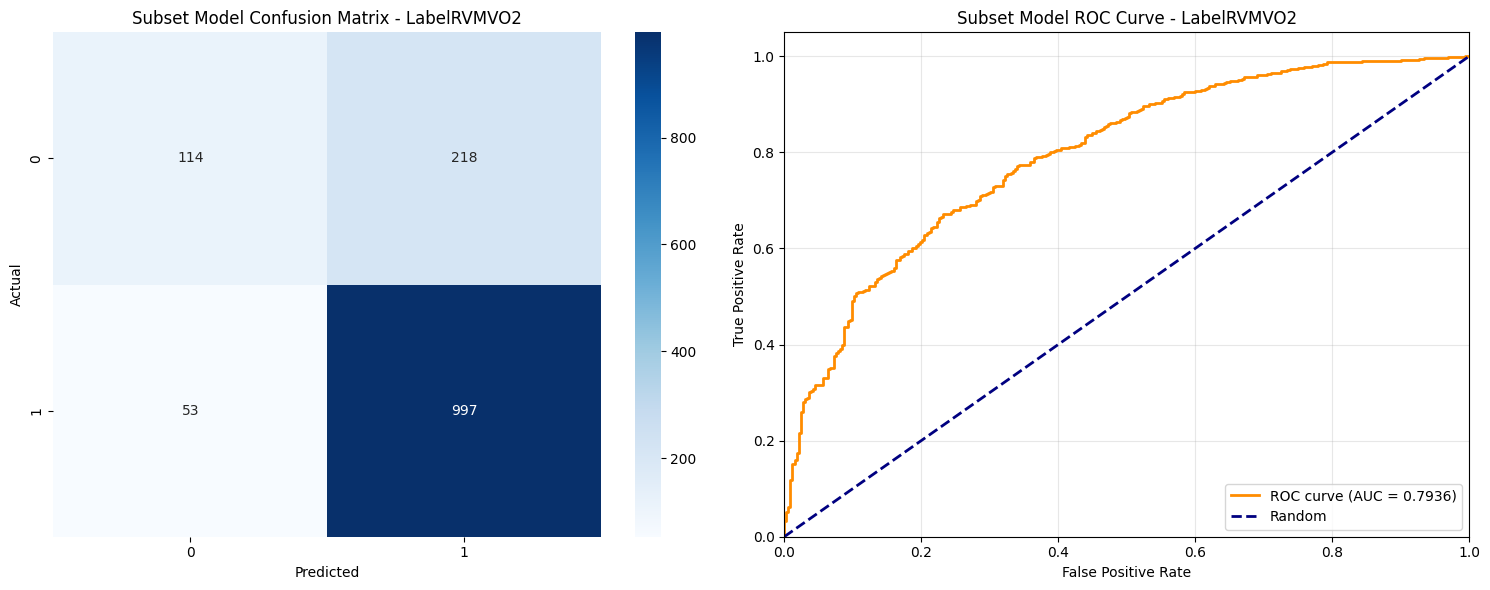

Subset Model AUC: 0.7936
Accuracy: 0.8039
Precision: 0.8206
Recall: 0.9495
F1-Score: 0.8804

Evaluating SUBSET model: LabelLVME...


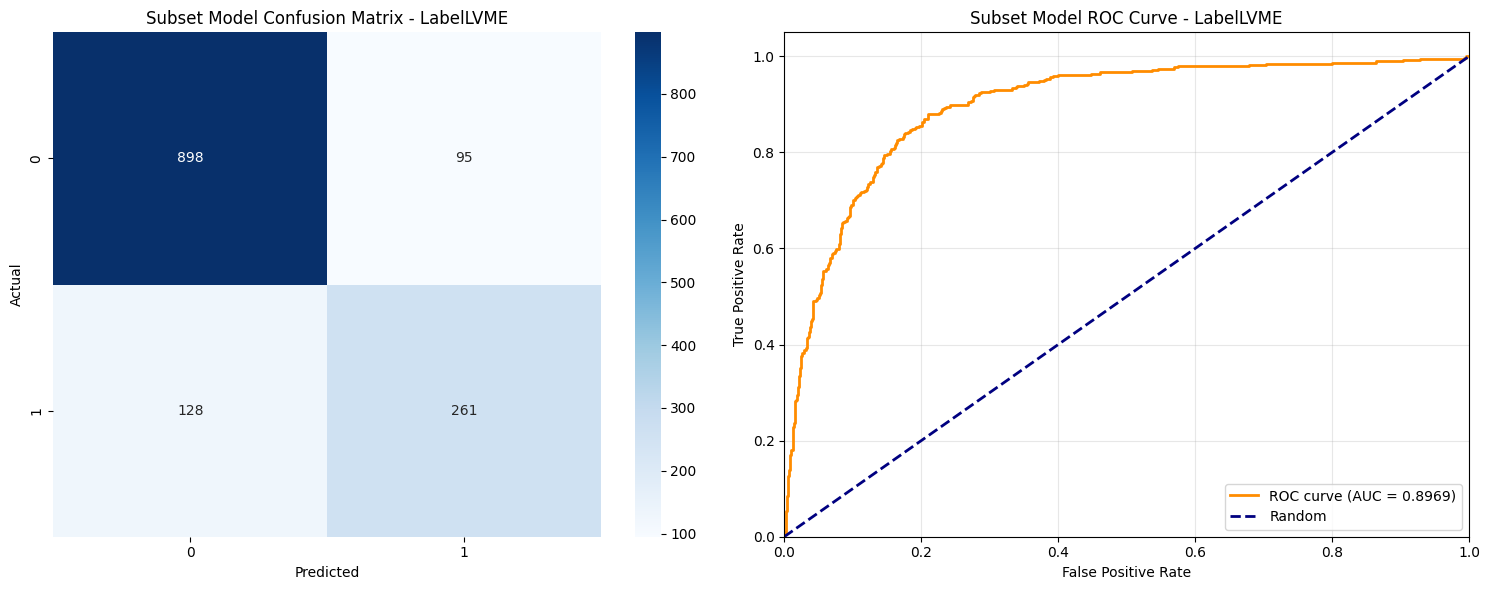

Subset Model AUC: 0.8969
Accuracy: 0.8386
Precision: 0.7331
Recall: 0.6710
F1-Score: 0.7007

Evaluating SUBSET model: LabelRVME...


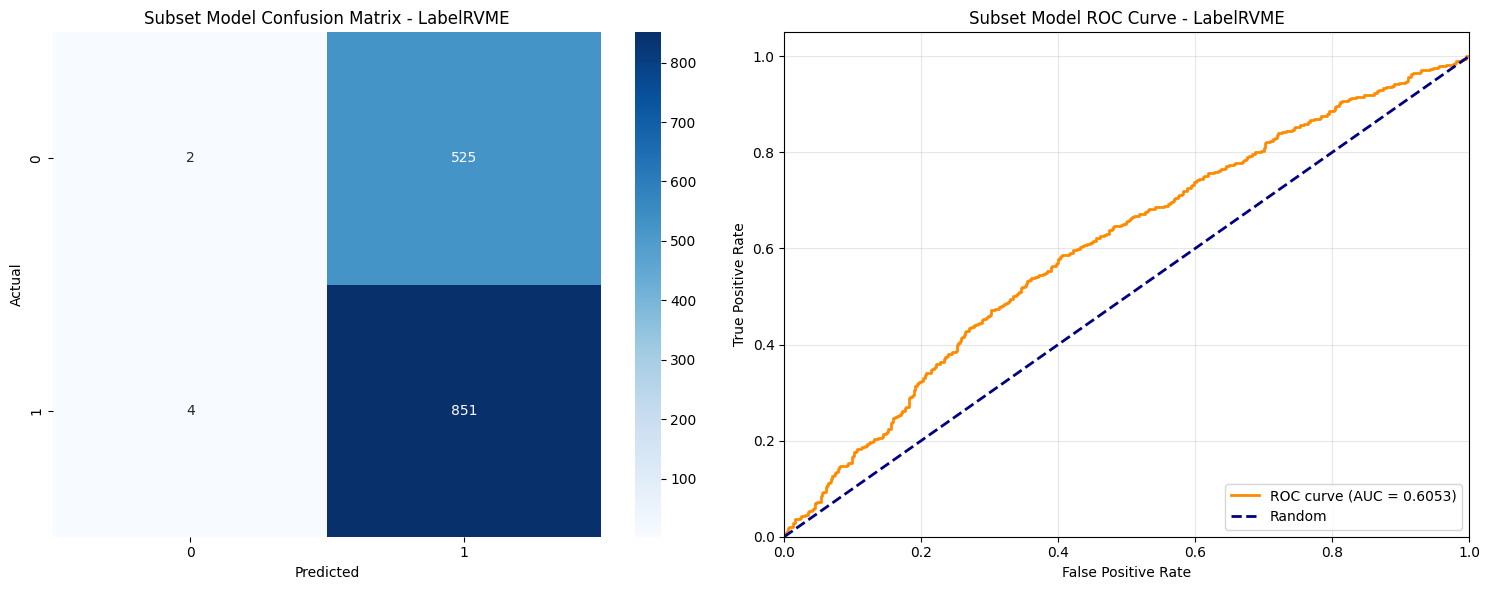

Subset Model AUC: 0.6053
Accuracy: 0.6172
Precision: 0.6185
Recall: 0.9953
F1-Score: 0.7629

SUBSET MODEL EVALUATION COMPLETED!
All subset evaluation plots saved in: subset_evaluation_plots/


In [29]:
# Complete Parallel Pipeline: Subset Model Evaluation
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("SUBSET MODEL EVALUATION - PARALLEL PIPELINE")
print("="*80)

print("🎯 Complete parallel evaluation of MYPACE-subset trained models")
print("📊 Same evaluation pipeline as original models")

# Create directory for subset evaluation plots
subset_plot_dir = "subset_evaluation_plots"
os.makedirs(subset_plot_dir, exist_ok=True)

print(f"\n" + "="*80)
print("SUBSET MODEL EVALUATION ON VALIDATION SET")
print("="*80)

# Dictionary to store subset evaluation results
subset_evaluation_results = {}

# Load and evaluate each subset-trained model on its validation set
for i in range(subset_labels.shape[1]):
    label_name = subset_labels.columns[i]
    print(f"\nEvaluating SUBSET model: {label_name}...")
    
    # Load the subset model
    subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
    if os.path.exists(subset_model_path):
        # Initialize and load subset model
        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()
        
        # Get predictions on subset validation set
        with torch.no_grad():
            X_subset_val_device = X_subset_val_tensor.to(device)
            subset_val_outputs = eval_subset_model(X_subset_val_device)
            subset_val_probs = subset_val_outputs.cpu().numpy().flatten()
            subset_val_preds = (subset_val_probs > 0.5).astype(int)
            subset_val_true = y_subset_val_tensor[:, i].numpy().astype(int)
        
        # Only proceed if we have both classes
        if len(np.unique(subset_val_true)) > 1:
            # Calculate metrics
            subset_val_auc = roc_auc_score(subset_val_true, subset_val_probs)
            
            # Confusion Matrix
            subset_cm = confusion_matrix(subset_val_true, subset_val_preds)
            
            # Classification Report
            subset_report = classification_report(subset_val_true, subset_val_preds, output_dict=True)
            
            # ROC Curve
            subset_fpr, subset_tpr, subset_thresholds = roc_curve(subset_val_true, subset_val_probs)
            subset_roc_auc = auc(subset_fpr, subset_tpr)
            
            # Store results
            subset_evaluation_results[label_name] = {
                'confusion_matrix': subset_cm,
                'classification_report': subset_report,
                'auc': subset_val_auc,
                'fpr': subset_fpr,
                'tpr': subset_tpr,
                'roc_auc': subset_roc_auc,
                'predictions': subset_val_preds,
                'probabilities': subset_val_probs,
                'true_labels': subset_val_true
            }
            
            # Create subplot figure for this label
            fig, axes = plt.subplots(1, 2, figsize=(15, 6))
            
            # Plot Confusion Matrix
            sns.heatmap(subset_cm, annot=True, fmt='d', cmap='Blues', ax=axes[0])
            axes[0].set_title(f'Subset Model Confusion Matrix - {label_name}')
            axes[0].set_xlabel('Predicted')
            axes[0].set_ylabel('Actual')
            
            # Plot ROC Curve
            axes[1].plot(subset_fpr, subset_tpr, color='darkorange', lw=2, 
                        label=f'ROC curve (AUC = {subset_roc_auc:.4f})')
            axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
            axes[1].set_xlim([0.0, 1.0])
            axes[1].set_ylim([0.0, 1.05])
            axes[1].set_xlabel('False Positive Rate')
            axes[1].set_ylabel('True Positive Rate')
            axes[1].set_title(f'Subset Model ROC Curve - {label_name}')
            axes[1].legend(loc="lower right")
            axes[1].grid(True, alpha=0.3)
            
            plt.tight_layout()
            plt.savefig(os.path.join(subset_plot_dir, f'{label_name}_subset_evaluation.png'), 
                       dpi=300, bbox_inches='tight')
            plt.show()
            
            # Print metrics
            print(f"Subset Model AUC: {subset_val_auc:.4f}")
            print(f"Accuracy: {subset_report['accuracy']:.4f}")
            if '1' in subset_report:
                print(f"Precision: {subset_report['1']['precision']:.4f}")
                print(f"Recall: {subset_report['1']['recall']:.4f}")
                print(f"F1-Score: {subset_report['1']['f1-score']:.4f}")
        else:
            print(f"❌ Skipping {label_name} - only one class in validation set")
            
    else:
        print(f"❌ Subset model file not found: {subset_model_path}")

print("\n" + "="*80)
print("SUBSET MODEL EVALUATION COMPLETED!")
print(f"All subset evaluation plots saved in: {subset_plot_dir}/")
print("="*80)

SUBSET MODEL EXTERNAL VALIDATION - 146 LABELED PATIENTS
🎯 Evaluating subset-trained models on 146 external validation patients
📊 Same external validation as original models, but with subset-trained models and subset-fitted scaler
✓ Successfully loaded external validation data: inputFGclassifier146.CSV

External validation data shape:
Features shape: (146, 17)
Labels shape: (146, 10)
External validation tensor size: torch.Size([146, 17])

EVALUATING SUBSET MODELS ON EXTERNAL VALIDATION SET

Subset External Validation: LabelFillingP


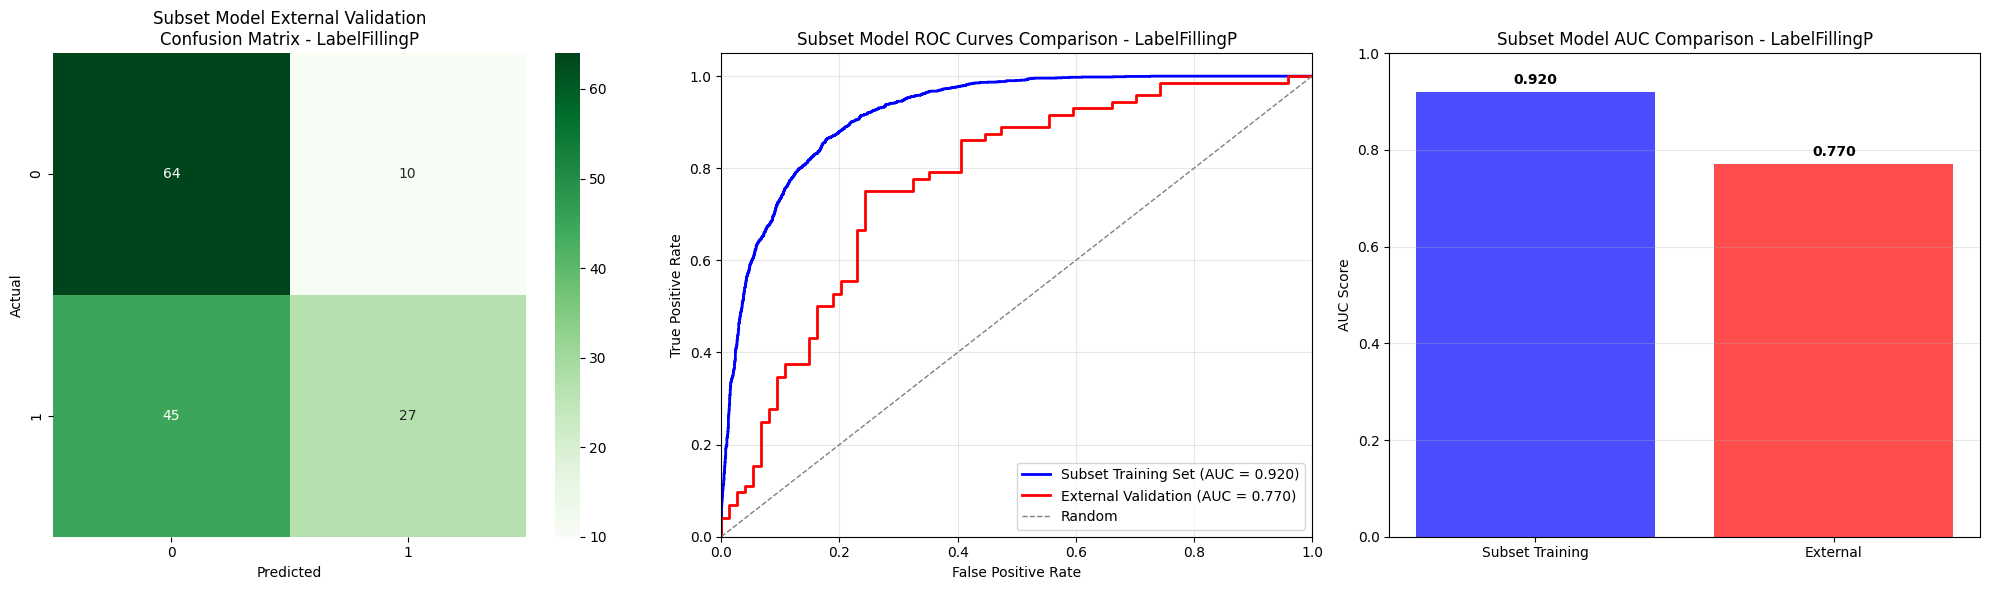

Subset Model External Validation Results:
  AUC: 0.7701
  Accuracy: 0.6233
  Precision: 0.7297
  Recall: 0.3750
  F1-Score: 0.4954
Subset Training vs External AUC Difference: 0.1502
⚠️  Large performance drop detected - possible overfitting

Subset External Validation: LabelEF


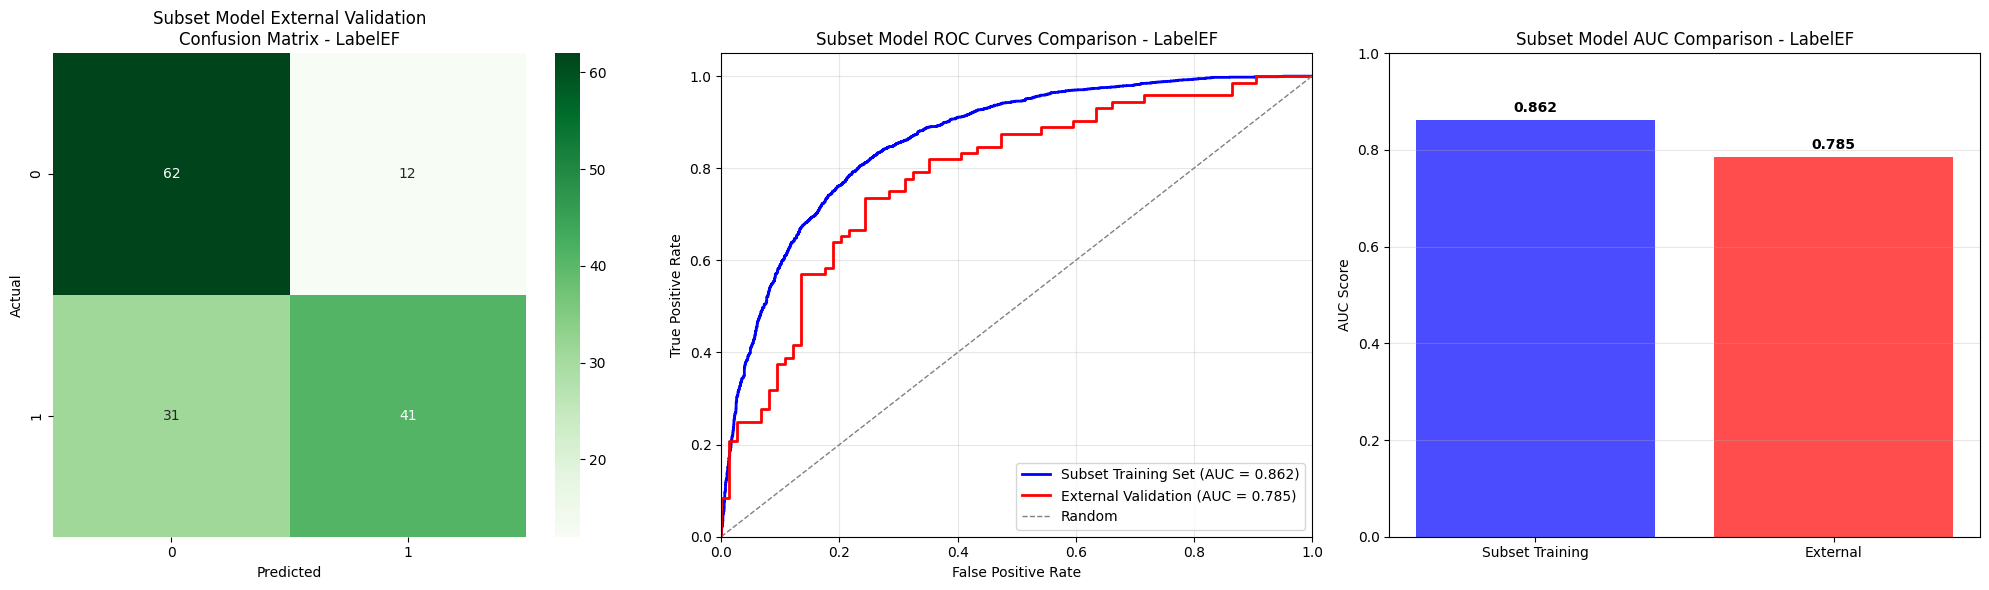

Subset Model External Validation Results:
  AUC: 0.7847
  Accuracy: 0.7055
  Precision: 0.7736
  Recall: 0.5694
  F1-Score: 0.6560
Subset Training vs External AUC Difference: 0.0768
✅ Acceptable performance on external validation

Subset External Validation: LabelCO


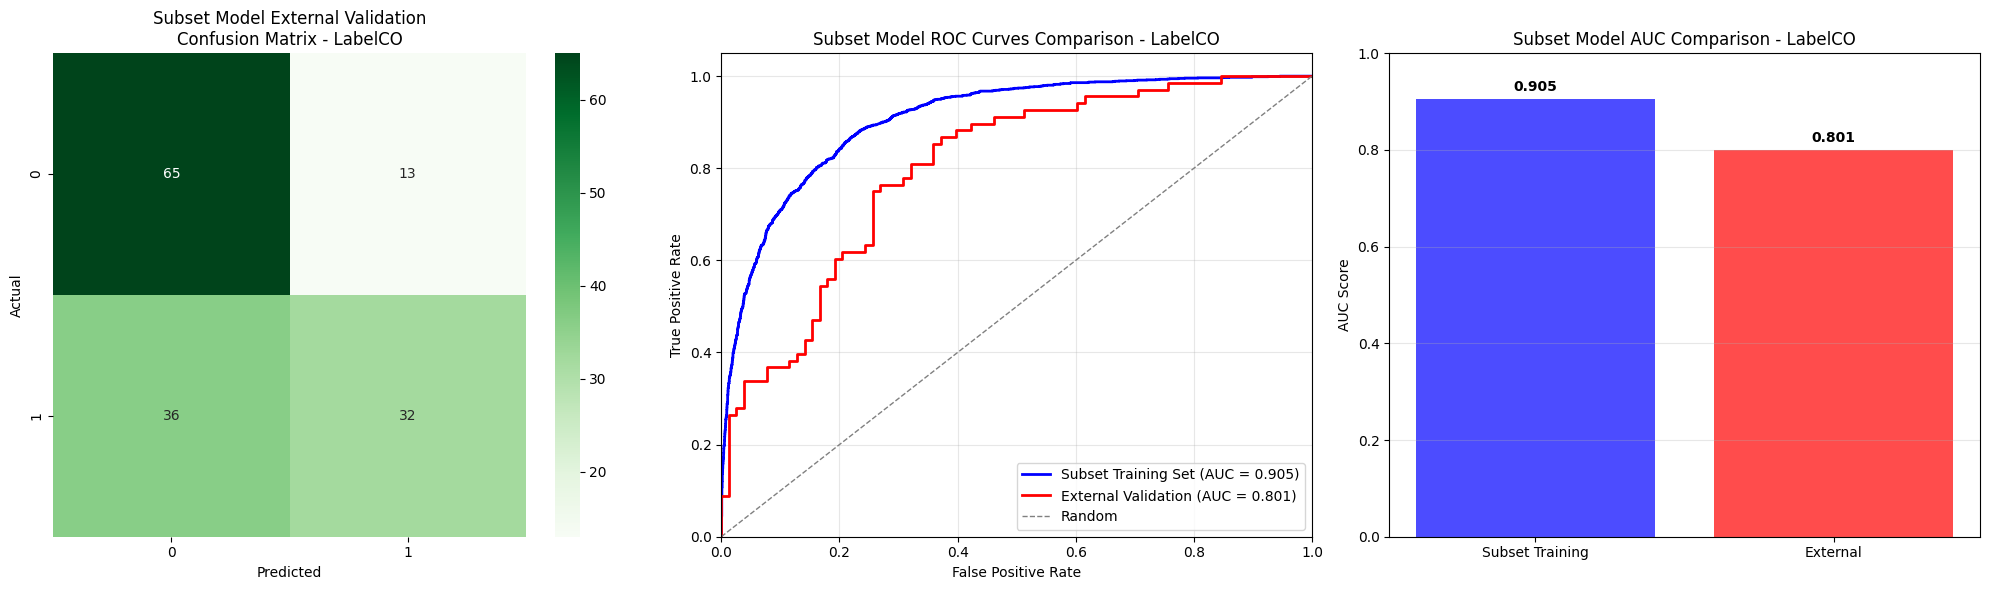

Subset Model External Validation Results:
  AUC: 0.8007
  Accuracy: 0.6644
  Precision: 0.7111
  Recall: 0.4706
  F1-Score: 0.5664
Subset Training vs External AUC Difference: 0.1048
⚠️  Large performance drop detected - possible overfitting

Subset External Validation: LabelLAV


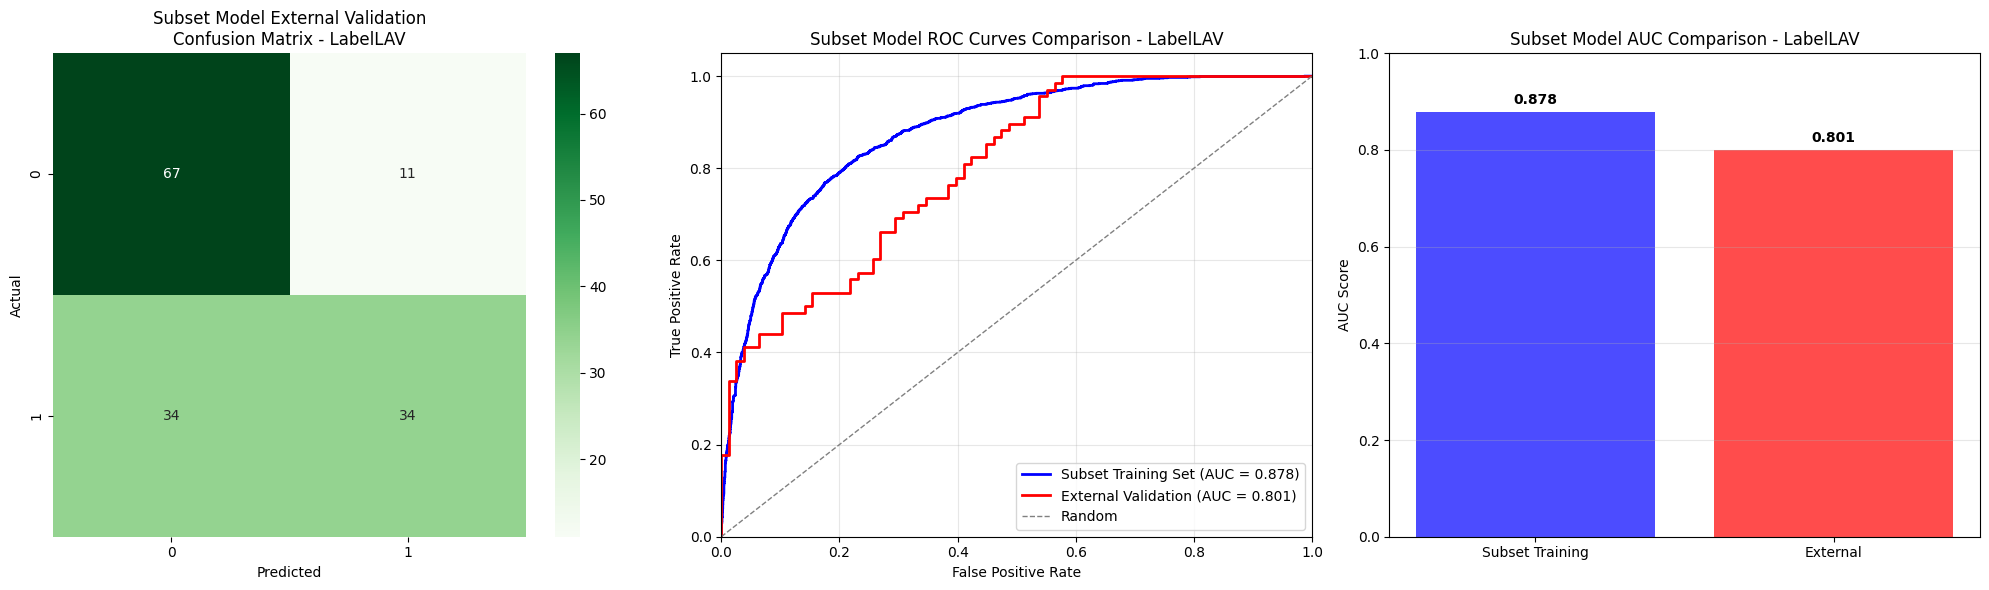

Subset Model External Validation Results:
  AUC: 0.8005
  Accuracy: 0.6918
  Precision: 0.7556
  Recall: 0.5000
  F1-Score: 0.6018
Subset Training vs External AUC Difference: 0.0772
✅ Acceptable performance on external validation

Subset External Validation: LabelRVO2E


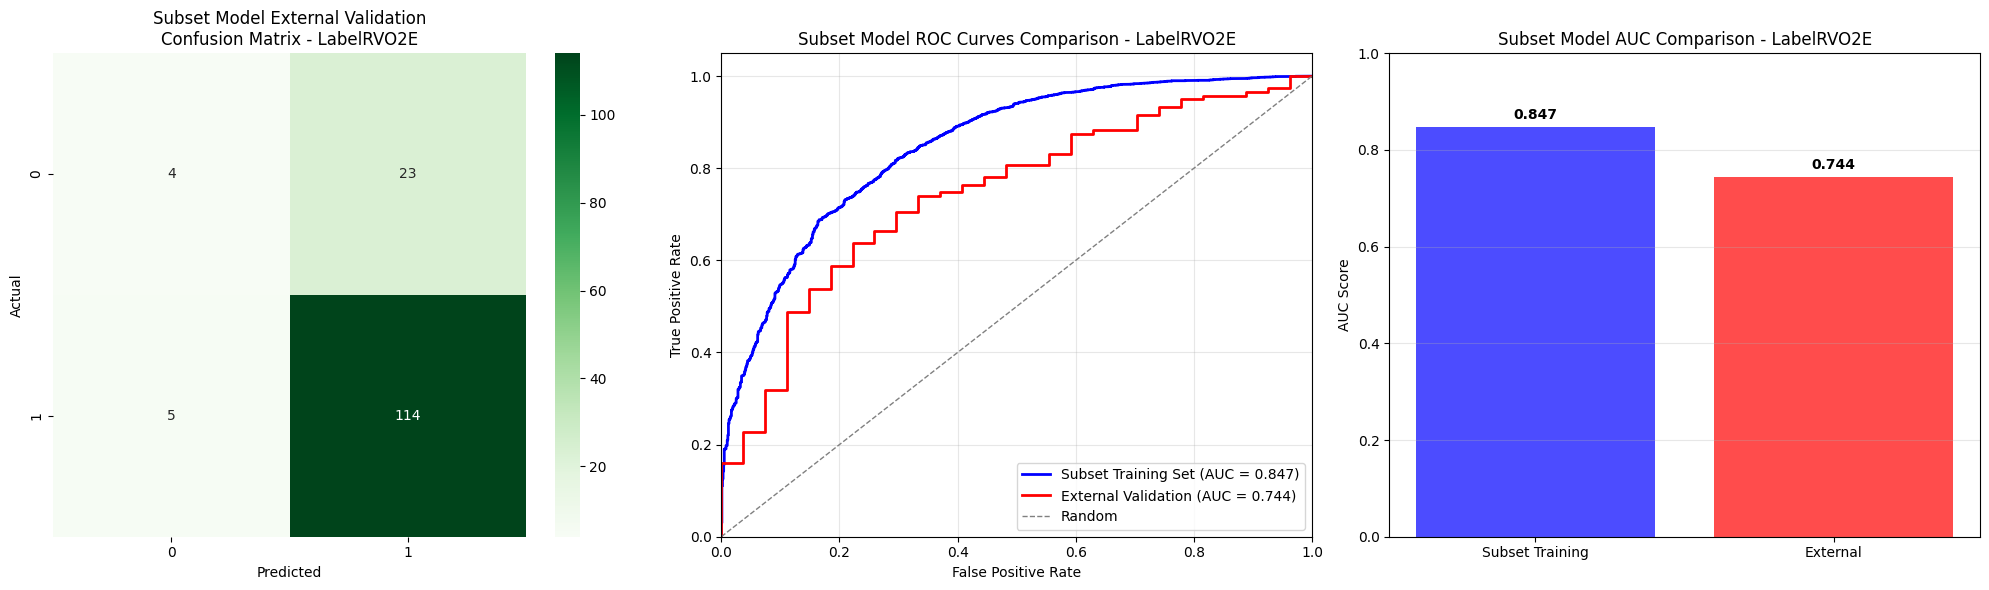

Subset Model External Validation Results:
  AUC: 0.7445
  Accuracy: 0.8082
  Precision: 0.8321
  Recall: 0.9580
  F1-Score: 0.8906
Subset Training vs External AUC Difference: 0.1026
⚠️  Large performance drop detected - possible overfitting

Subset External Validation: LabelLVO2E


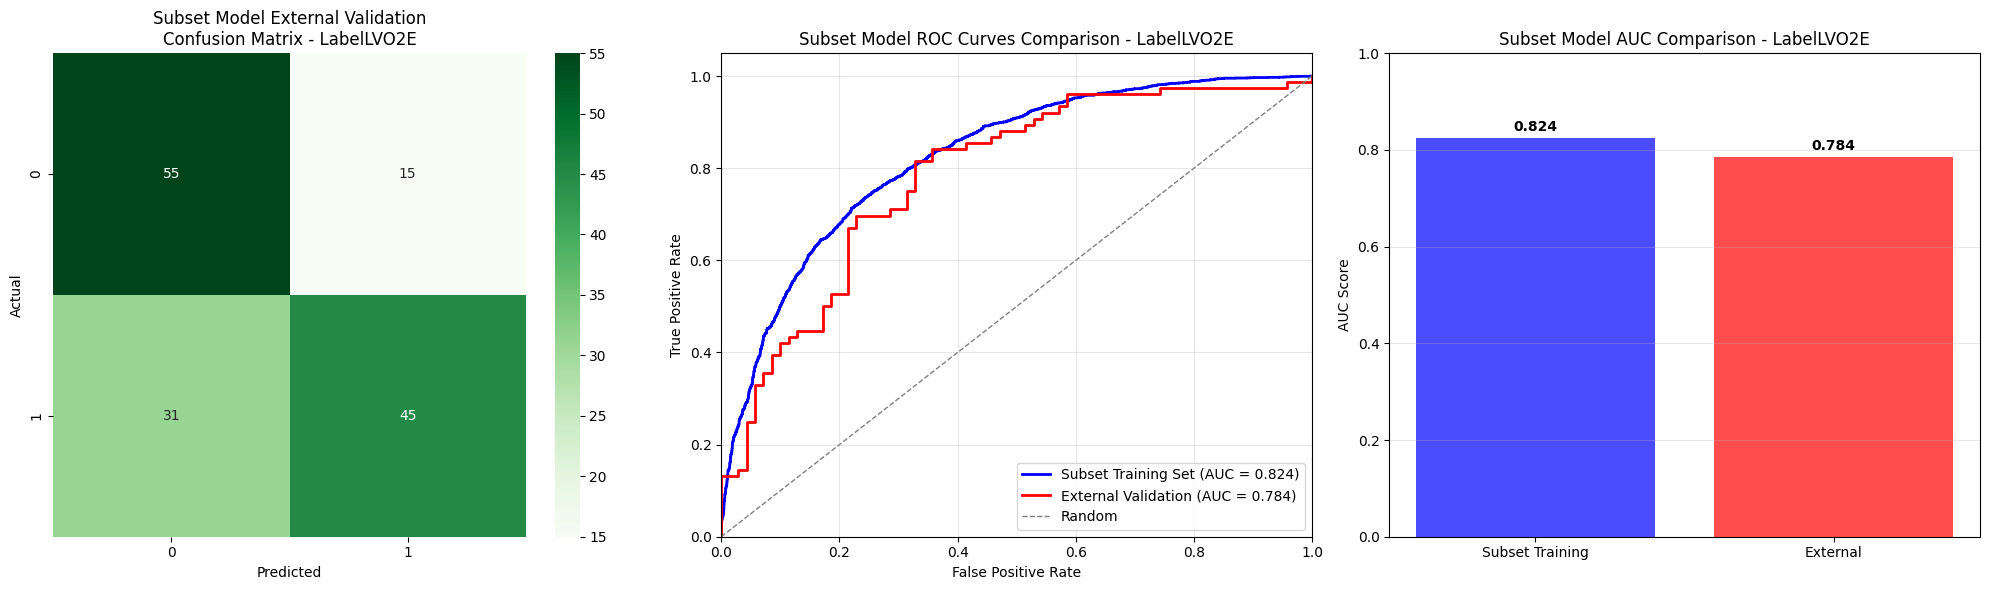

Subset Model External Validation Results:
  AUC: 0.7844
  Accuracy: 0.6849
  Precision: 0.7500
  Recall: 0.5921
  F1-Score: 0.6618
Subset Training vs External AUC Difference: 0.0394
✅ Acceptable performance on external validation

Subset External Validation: LabelLVMVO2


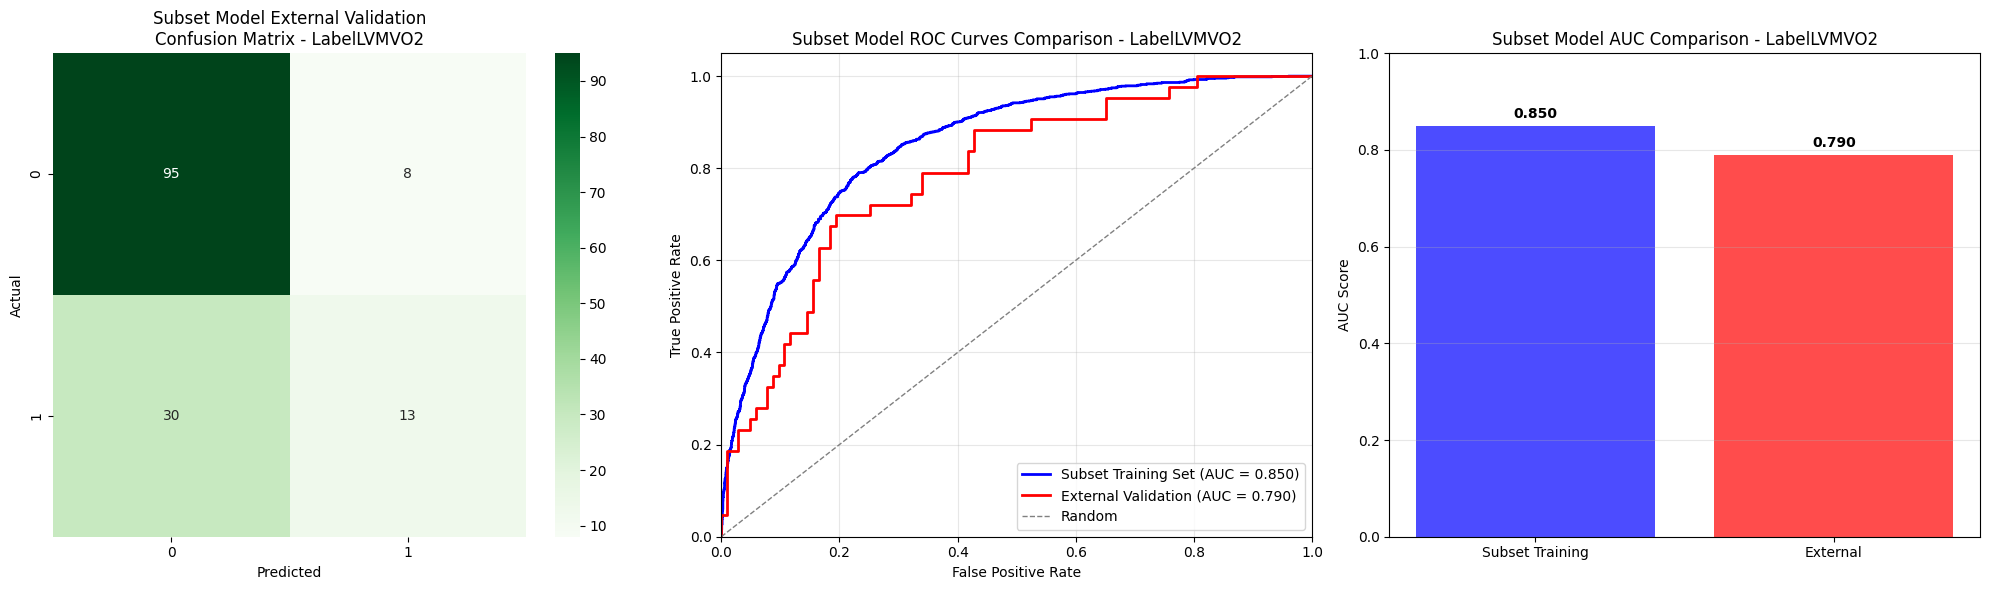

Subset Model External Validation Results:
  AUC: 0.7898
  Accuracy: 0.7397
  Precision: 0.6190
  Recall: 0.3023
  F1-Score: 0.4062
Subset Training vs External AUC Difference: 0.0603
✅ Acceptable performance on external validation

Subset External Validation: LabelRVMVO2


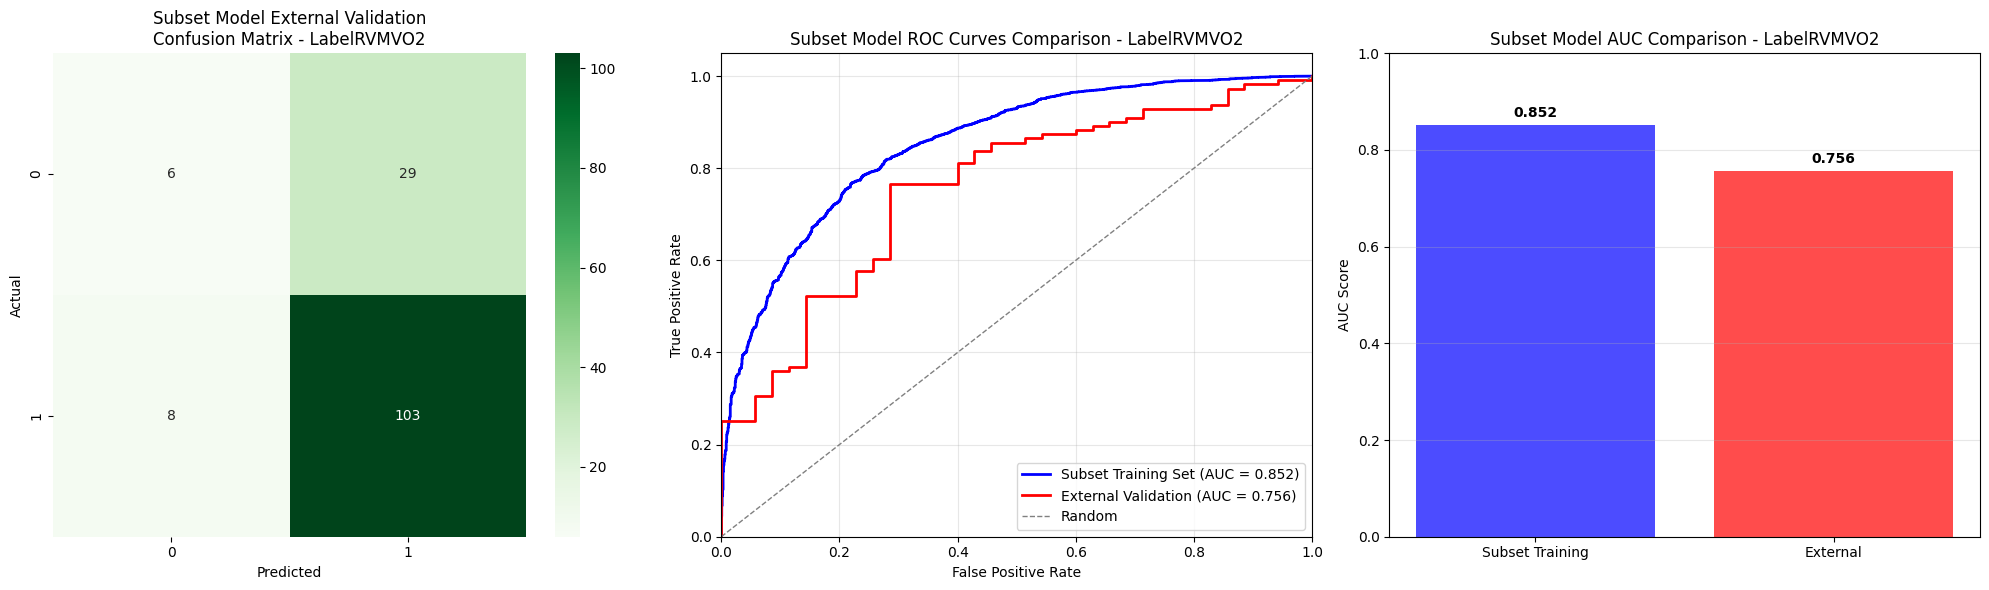

Subset Model External Validation Results:
  AUC: 0.7565
  Accuracy: 0.7466
  Precision: 0.7803
  Recall: 0.9279
  F1-Score: 0.8477
Subset Training vs External AUC Difference: 0.0957
✅ Acceptable performance on external validation

Subset External Validation: LabelLVME


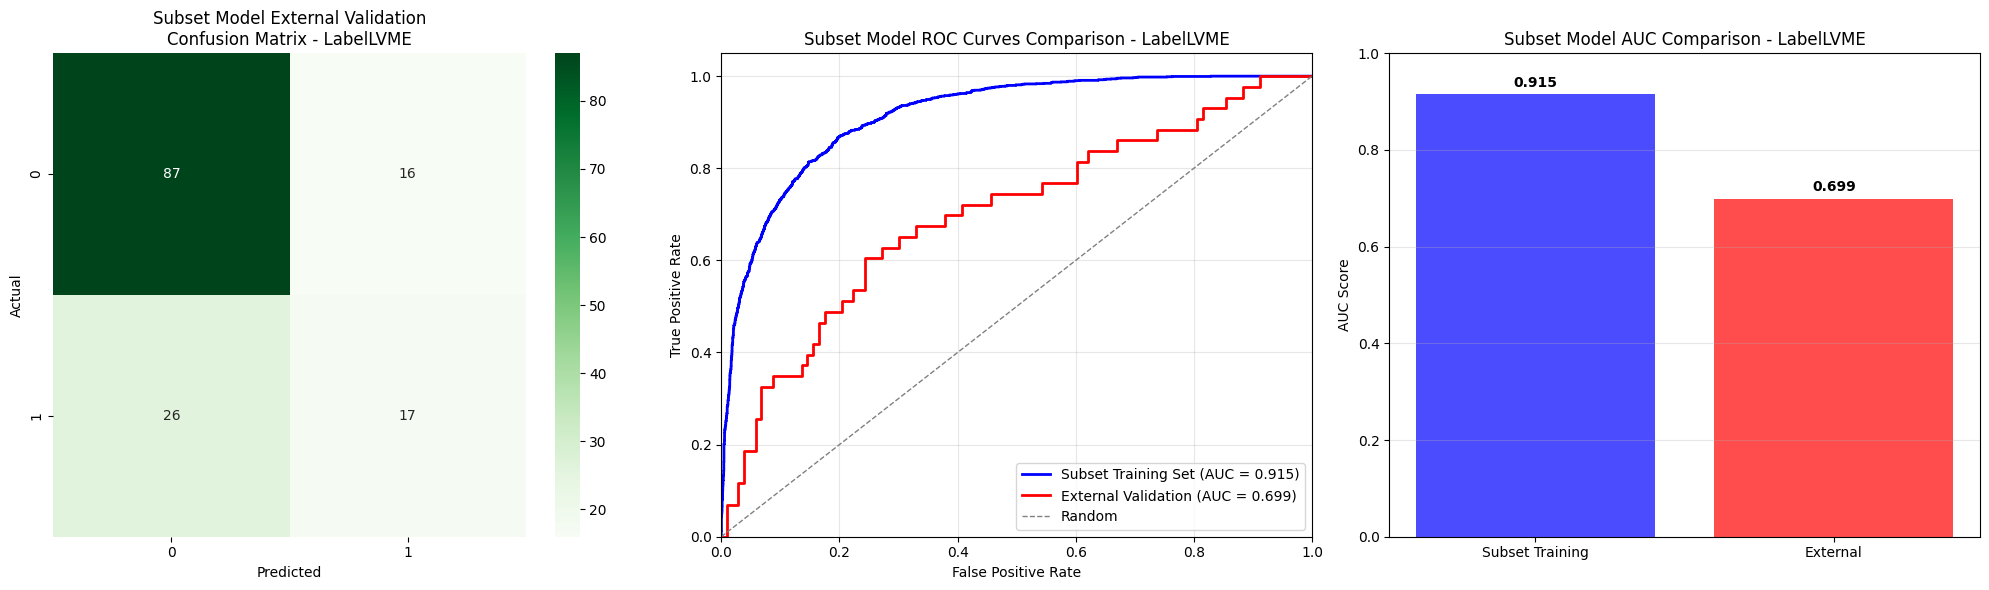

Subset Model External Validation Results:
  AUC: 0.6986
  Accuracy: 0.7123
  Precision: 0.5152
  Recall: 0.3953
  F1-Score: 0.4474
Subset Training vs External AUC Difference: 0.2161
⚠️  Large performance drop detected - possible overfitting

Subset External Validation: LabelRVME


c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\github\Haolin_24Winter_Danlab\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", res

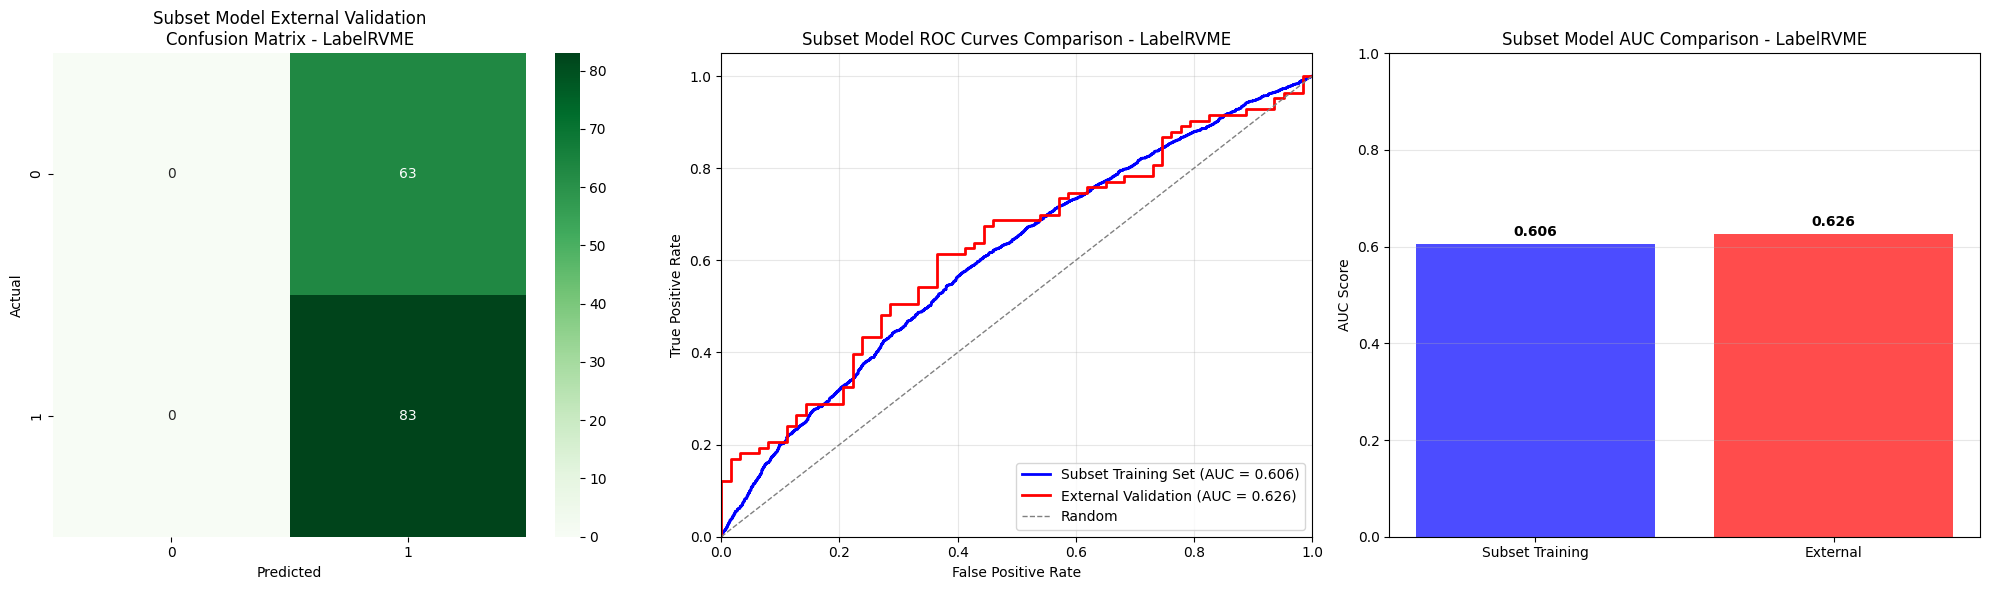

Subset Model External Validation Results:
  AUC: 0.6257
  Accuracy: 0.5685
  Precision: 0.5685
  Recall: 1.0000
  F1-Score: 0.7249
Subset Training vs External AUC Difference: -0.0202
✅ External validation performance better than training - excellent generalization

SUBSET EXTERNAL VALIDATION COMPLETED!
All subset external validation plots saved in: subset_external_validation_plots/

SUMMARY: Subset Training vs External Validation Performance
Label           Train AUC  External AUC  Difference Status
-----------------------------------------------------------------
LabelFillingP   0.9202     0.7701        0.1502     ⚠️ Large Gap
LabelEF         0.8615     0.7847        0.0768     ✅ Good
LabelCO         0.9055     0.8007        0.1048     ⚠️ Large Gap
LabelLAV        0.8777     0.8005        0.0772     ✅ Good
LabelRVO2E      0.8471     0.7445        0.1026     ⚠️ Large Gap
LabelLVO2E      0.8238     0.7844        0.0394     ✅ Good
LabelLVMVO2     0.8501     0.7898        0.0603     ✅ Goo

In [30]:
# Subset Model External Validation on 146 Labeled Dataset
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("="*80)
print("SUBSET MODEL EXTERNAL VALIDATION - 146 LABELED PATIENTS")
print("="*80)

print("🎯 Evaluating subset-trained models on 146 external validation patients")
print("📊 Same external validation as original models, but with subset-trained models and subset-fitted scaler")

# Load external validation dataset (same as before)
df_external_subset = pd.read_csv('inputFGclassifier146.CSV')
print(f"✓ Successfully loaded external validation data: inputFGclassifier146.CSV")

# Preprocess external validation data (same preprocessing as training)
external_processed_subset = df_external_subset.drop(df_external_subset.columns[[0, 12]], axis=1)
external_features_subset = external_processed_subset.iloc[:, 0:17]
external_labels_subset = external_processed_subset.iloc[:, -10:]

print(f"\nExternal validation data shape:")
print(f"Features shape: {external_features_subset.shape}")
print(f"Labels shape: {external_labels_subset.shape}")

# Normalize using SUBSET-FITTED scaler with clipping to subset min/max
external_continuous_subset = external_features_subset.iloc[:, 1:-1].copy()
# Clip to subset min/max to handle out-of-bound
for col in external_continuous_subset.columns:
    if col in subset_cont_mins.index:
        external_continuous_subset[col] = external_continuous_subset[col].clip(lower=subset_cont_mins[col], upper=subset_cont_maxs[col])
external_normalized_subset = subset_scaler.transform(external_continuous_subset)

# Combine binary and normalized continuous features
external_normalized_df_subset = pd.DataFrame(external_normalized_subset, columns=external_continuous_subset.columns)
external_normalized_df_subset.insert(0, external_features_subset.columns[0], external_features_subset.iloc[:, 0])
external_normalized_df_subset[external_features_subset.columns[-1]] = external_features_subset.iloc[:, -1]

# Convert to PyTorch tensor
X_external_subset_tensor = torch.tensor(external_normalized_df_subset.values, dtype=torch.float32)

print(f"External validation tensor size: {X_external_subset_tensor.size()}")

# Create directory for subset external validation plots
subset_external_plot_dir = "subset_external_validation_plots"
os.makedirs(subset_external_plot_dir, exist_ok=True)

print(f"\n" + "="*80)
print("EVALUATING SUBSET MODELS ON EXTERNAL VALIDATION SET")
print("="*80)

# Dictionary to store subset external validation results
subset_external_results = {}

# Evaluate each subset-trained model on external validation set
for i in range(labels.shape[1]):  # Use original labels for consistent indexing
    label_name = labels.columns[i]
    print(f"\n{'='*60}")
    print(f"Subset External Validation: {label_name}")
    print(f"{'='*60}")
    
    # Load the subset model
    subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
    if os.path.exists(subset_model_path):
        # Initialize and load subset model
        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()
        
        # Get predictions on external validation set
        with torch.no_grad():
            X_external_subset_device = X_external_subset_tensor.to(device)
            external_subset_outputs = eval_subset_model(X_external_subset_device)
            external_subset_probs = external_subset_outputs.cpu().numpy().flatten()
            external_subset_preds = (external_subset_probs > 0.5).astype(int)
            external_subset_true = external_labels_subset.iloc[:, i].values.astype(int)
        
        # Get subset training set predictions for comparison
        with torch.no_grad():
            X_subset_train_device = X_subset_train_tensor.to(device)
            train_subset_outputs = eval_subset_model(X_subset_train_device)
            train_subset_probs = train_subset_outputs.cpu().numpy().flatten()
            train_subset_true = y_subset_train_tensor[:, i].numpy().astype(int)
        
        # Calculate metrics for external validation
        external_subset_auc = roc_auc_score(external_subset_true, external_subset_probs)
        external_subset_cm = confusion_matrix(external_subset_true, external_subset_preds)
        external_subset_report = classification_report(external_subset_true, external_subset_preds, output_dict=True)
        
        # Calculate ROC curves
        external_subset_fpr, external_subset_tpr, _ = roc_curve(external_subset_true, external_subset_probs)
        train_subset_fpr, train_subset_tpr, _ = roc_curve(train_subset_true, train_subset_probs)
        
        # Store results
        subset_external_results[label_name] = {
            'external_auc': external_subset_auc,
            'external_cm': external_subset_cm,
            'external_report': external_subset_report,
            'external_fpr': external_subset_fpr,
            'external_tpr': external_subset_tpr
        }
        
        # Create comprehensive visualization
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # 1. External Validation Confusion Matrix
        sns.heatmap(external_subset_cm, annot=True, fmt='d', cmap='Greens', ax=axes[0])
        axes[0].set_title(f'Subset Model External Validation\nConfusion Matrix - {label_name}')
        axes[0].set_xlabel('Predicted')
        axes[0].set_ylabel('Actual')
        
        # 2. Training vs External ROC Comparison
        train_subset_auc = roc_auc_score(train_subset_true, train_subset_probs)
        axes[1].plot(train_subset_fpr, train_subset_tpr, color='blue', lw=2, 
                    label=f'Subset Training Set (AUC = {train_subset_auc:.3f})')
        axes[1].plot(external_subset_fpr, external_subset_tpr, color='red', lw=2, 
                    label=f'External Validation (AUC = {external_subset_auc:.3f})')
        axes[1].plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', label='Random')
        axes[1].set_xlim([0.0, 1.0])
        axes[1].set_ylim([0.0, 1.05])
        axes[1].set_xlabel('False Positive Rate')
        axes[1].set_ylabel('True Positive Rate')
        axes[1].set_title(f'Subset Model ROC Curves Comparison - {label_name}')
        axes[1].legend(loc="lower right")
        axes[1].grid(True, alpha=0.3)
        
        # 3. Performance Metrics Comparison
        bars = axes[2].bar(['Subset Training', 'External'], [train_subset_auc, external_subset_auc], 
                          color=['blue', 'red'], alpha=0.7)
        axes[2].set_ylim([0, 1])
        axes[2].set_ylabel('AUC Score')
        axes[2].set_title(f'Subset Model AUC Comparison - {label_name}')
        axes[2].grid(True, alpha=0.3, axis='y')
        
        # Add value labels on bars
        for bar, value in zip(bars, [train_subset_auc, external_subset_auc]):
            height = bar.get_height()
            axes[2].text(bar.get_x() + bar.get_width()/2., height + 0.01,
                        f'{value:.3f}', ha='center', va='bottom', fontweight='bold')
        
        plt.tight_layout()
        plt.savefig(os.path.join(subset_external_plot_dir, f'{label_name}_subset_external_validation.png'), 
                   dpi=300, bbox_inches='tight')
        plt.show()
        
        # Print detailed metrics
        print(f"Subset Model External Validation Results:")
        print(f"  AUC: {external_subset_auc:.4f}")
        print(f"  Accuracy: {external_subset_report['accuracy']:.4f}")
        if '1' in external_subset_report:
            print(f"  Precision: {external_subset_report['1']['precision']:.4f}")
            print(f"  Recall: {external_subset_report['1']['recall']:.4f}")
            print(f"  F1-Score: {external_subset_report['1']['f1-score']:.4f}")
        
        print(f"Subset Training vs External AUC Difference: {train_subset_auc - external_subset_auc:.4f}")
        
        if abs(train_subset_auc - external_subset_auc) > 0.1:
            print("⚠️  Large performance drop detected - possible overfitting")
        elif external_subset_auc > train_subset_auc:
            print("✅ External validation performance better than training - excellent generalization")
        else:
            print("✅ Acceptable performance on external validation")
            
    else:
        print(f"❌ Subset model file not found: {subset_model_path}")

print(f"\n" + "="*80)
print("SUBSET EXTERNAL VALIDATION COMPLETED!")
print(f"All subset external validation plots saved in: {subset_external_plot_dir}/")
print("="*80)

# Summary table of subset external validation results
print(f"\n{'='*80}")
print("SUMMARY: Subset Training vs External Validation Performance")
print(f"{'='*80}")
print(f"{'Label':<15} {'Train AUC':<10} {'External AUC':<13} {'Difference':<10} {'Status'}")
print("-" * 65)

for label_name in labels.columns:
    if label_name in subset_external_results:
        # Get subset training AUC
        subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
        if os.path.exists(subset_model_path):
            eval_subset_model = MLPClassifier(input_size=17).to(device)
            eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
            eval_subset_model.eval()
            with torch.no_grad():
                X_subset_train_device = X_subset_train_tensor.to(device)
                train_subset_outputs = eval_subset_model(X_subset_train_device)
                train_subset_probs = train_subset_outputs.cpu().numpy().flatten()
                train_subset_true = y_subset_train_tensor[:, list(labels.columns).index(label_name)].numpy().astype(int)
                train_subset_auc = roc_auc_score(train_subset_true, train_subset_probs)
        else:
            train_subset_auc = 0.0
                
        external_subset_auc = subset_external_results[label_name]['external_auc']
        diff = train_subset_auc - external_subset_auc
        
        if abs(diff) > 0.1:
            status = "⚠️ Large Gap"
        elif external_subset_auc > train_subset_auc:
            status = "✅ Better"
        else:
            status = "✅ Good"
            
        print(f"{label_name:<15} {train_subset_auc:<10.4f} {external_subset_auc:<13.4f} {diff:<10.4f} {status}")

print(f"\n✅ Subset model external validation complete! 146 patients evaluated across all subset classifiers.")

In [31]:
# Subset Model Prediction on MYPACE Dataset
import pandas as pd
import numpy as np
import torch

print("="*80)
print("SUBSET MODEL PREDICTION ON MYPACE DATASET")
print("="*80)

print("🎯 Using subset-trained models to predict MYPACE dataset")
print("📊 Prediction pipeline uses scaler fitted on the subset; external data is clipped to subset min/max before transform")

# Use the same preprocessed MYPACE data from earlier (before normalization)
# We need to re-normalize using the subset-fitted scaler

# Rebuild normalized MYPACE features using subset scaler with clipping
mypace_cont_for_subset = mypace_features_imputed.iloc[:, 1:-1].copy()
for col in mypace_cont_for_subset.columns:
    if col in subset_cont_mins.index:
        mypace_cont_for_subset[col] = mypace_cont_for_subset[col].clip(lower=subset_cont_mins[col], upper=subset_cont_maxs[col])

mypace_normalized_subset = subset_scaler.transform(mypace_cont_for_subset)

mypace_normalized_df_subset = pd.DataFrame(mypace_normalized_subset, columns=mypace_cont_for_subset.columns)
mypace_normalized_df_subset.insert(0, mypace_features_imputed.columns[0], mypace_features_imputed.iloc[:, 0])  # First binary column
mypace_normalized_df_subset[mypace_features_imputed.columns[-1]] = mypace_features_imputed.iloc[:, -1]  # Last binary column

# Convert to PyTorch tensor
X_mypace_subset = torch.tensor(mypace_normalized_df_subset.values, dtype=torch.float32)
print(f"MYPACE data ready for subset model prediction (subset-fitted scaler): {X_mypace_subset.size()}")

print(f"\n{'='*80}")
print("PREDICTING LABELS FOR MYPACE DATASET USING SUBSET MODELS")
print(f"{'='*80}")

# Dictionary to store subset model predictions
mypace_subset_predictions = {}
mypace_subset_probabilities = {}

# Predict using each subset-trained model
for i, label_name in enumerate(labels.columns):
    print(f"\nPredicting {label_name} using SUBSET model...")
    
    # Load the subset model
    subset_model_path = os.path.join(subset_save_dir, f"model_{label_name}_subset_best.pth")
    if os.path.exists(subset_model_path):
        # Initialize and load subset model
        eval_subset_model = MLPClassifier(input_size=17).to(device)
        eval_subset_model.load_state_dict(torch.load(subset_model_path, map_location=device))
        eval_subset_model.eval()
        
        # Get predictions
        with torch.no_grad():
            X_mypace_subset_device = X_mypace_subset.to(device)
            mypace_subset_outputs = eval_subset_model(X_mypace_subset_device)
            mypace_subset_probs = mypace_subset_outputs.cpu().numpy().flatten()
            mypace_subset_preds = (mypace_subset_probs > 0.5).astype(int)
        
        # Store predictions
        mypace_subset_predictions[label_name] = mypace_subset_preds
        mypace_subset_probabilities[label_name] = mypace_subset_probs
        
        # Print prediction statistics
        positive_count = np.sum(mypace_subset_preds)
        positive_rate = positive_count / len(mypace_subset_preds)
        mean_prob = np.mean(mypace_subset_probs)
        
        print(f"  Positive predictions: {positive_count}/{len(mypace_subset_preds)} ({positive_rate:.3f})")
        print(f"  Mean probability: {mean_prob:.4f}")
        print(f"  Probability range: [{np.min(mypace_subset_probs):.4f}, {np.max(mypace_subset_probs):.4f}]")
        
    else:
        print(f"❌ Subset model file not found: {subset_model_path}")
        mypace_subset_predictions[label_name] = np.zeros(len(df_mypace), dtype=int)
        mypace_subset_probabilities[label_name] = np.zeros(len(df_mypace))

# Create results DataFrame for subset models
print(f"\n{'='*80}")
print("CREATING SUBSET MODEL RESULTS TABLE")
print(f"{'='*80}")

# Start with original MYPACE data
df_mypace_subset_predictions = df_mypace.copy()

# Add subset model predicted labels and probabilities
for label_name in labels.columns:
    # Add binary predictions with suffix to distinguish from original model predictions
    df_mypace_subset_predictions[f'{label_name}_subset'] = mypace_subset_predictions[label_name]
    # Add probability scores
    df_mypace_subset_predictions[f'{label_name}_subset_prob'] = np.round(mypace_subset_probabilities[label_name], 4)

print(f"✅ Added subset model predictions for all {len(labels.columns)} labels")
print(f"Final dataset shape: {df_mypace_subset_predictions.shape}")

# Display subset model prediction summary
print(f"\n📊 SUBSET MODEL PREDICTION SUMMARY:")
print("-" * 80)
print(f"{'Label':<15} {'Negative (0)':<12} {'Positive (1)':<12} {'Pos Rate':<10} {'Mean Prob':<10}")
print("-" * 80)
for label_name in labels.columns:
    preds = mypace_subset_predictions[label_name]
    probs = mypace_subset_probabilities[label_name]
    
    # Count 0s and 1s
    neg_count = np.sum(preds == 0)  # Count of 0s (negative predictions)
    pos_count = np.sum(preds == 1)  # Count of 1s (positive predictions)
    pos_rate = pos_count / len(preds)
    mean_prob = np.mean(probs)
    
    print(f"{label_name:<15} {neg_count:<12} {pos_count:<12} {pos_rate:<10.3f} {mean_prob:<10.4f}")

# Additional detailed breakdown for subset models
print(f"\n📈 DETAILED SUBSET MODEL PREDICTION BREAKDOWN:")
print("-" * 80)
total_patients = len(df_mypace)
print(f"Total patients processed: {total_patients}")
print(f"Labels analyzed: {len(labels.columns)}")

for label_name in labels.columns:
    preds = mypace_subset_predictions[label_name]
    probs = mypace_subset_probabilities[label_name]
    
    neg_count = np.sum(preds == 0)
    pos_count = np.sum(preds == 1)
    
    print(f"\n{label_name} (Subset Model):")
    print(f"  Negative (0): {neg_count:3d} patients ({neg_count/total_patients*100:5.1f}%)")
    print(f"  Positive (1): {pos_count:3d} patients ({pos_count/total_patients*100:5.1f}%)")
    print(f"  Mean probability: {np.mean(probs):.4f}")
    print(f"  Prob range: [{np.min(probs):.4f}, {np.max(probs):.4f}]")

# Save subset model results to file
subset_output_path = mypace_file_path.replace('.CSV', '_with_subset_predictions.CSV')
df_mypace_subset_predictions.to_csv(subset_output_path, index=False)

print(f"\n✅ SUBSET MODEL PREDICTION COMPLETED!")
print(f"Results saved to: {subset_output_path}")
print(f"Total patients processed: {len(df_mypace)}")
print(f"Added {len(labels.columns)} subset label predictions and {len(labels.columns)} subset probability scores")
print(f"Output columns: {len(df_mypace_subset_predictions.columns)} (original: {len(df_mypace.columns)})")

# Display first few rows of subset model results
print(f"\n📋 Sample Subset Model Results (first 5 rows, prediction columns only):")
subset_prediction_columns = [col for col in df_mypace_subset_predictions.columns 
                            if col.endswith('_subset') or col.endswith('_subset_prob')]
print(df_mypace_subset_predictions[subset_prediction_columns].head())

print(f"\n🎯 COMPLETE PARALLEL PIPELINE SUMMARY:")
print("="*80)
print("✅ 1. MYPACE-similar subset selection completed")
print("✅ 2. Subset model training completed (subset-fitted scaler)")
print("✅ 3. Subset model validation evaluation completed")
print("✅ 4. Subset model external validation (146 patients, subset-fitted scaler + clipping) completed")
print("✅ 5. Subset model MYPACE prediction completed (subset-fitted scaler + clipping)")
print(f"\n📁 Generated Files:")
print(f"   • Subset models: {subset_save_dir}/")
print(f"   • Subset evaluation plots: {subset_plot_dir}/")
print(f"   • Subset external validation plots: {subset_external_plot_dir}/")
print(f"   • MYPACE subset predictions: {subset_output_path}")
print(f"\n🚀 Parallel pipeline complete! Both original and subset models available for comparison.")

SUBSET MODEL PREDICTION ON MYPACE DATASET
🎯 Using subset-trained models to predict MYPACE dataset
📊 Prediction pipeline uses scaler fitted on the subset; external data is clipped to subset min/max before transform
MYPACE data ready for subset model prediction (subset-fitted scaler): torch.Size([107, 17])

PREDICTING LABELS FOR MYPACE DATASET USING SUBSET MODELS

Predicting LabelFillingP using SUBSET model...
  Positive predictions: 23/107 (0.215)
  Mean probability: 0.2509
  Probability range: [0.0007, 0.7829]

Predicting LabelEF using SUBSET model...
  Positive predictions: 36/107 (0.336)
  Mean probability: 0.4318
  Probability range: [0.0005, 0.9495]

Predicting LabelCO using SUBSET model...
  Positive predictions: 23/107 (0.215)
  Mean probability: 0.2538
  Probability range: [0.0000, 0.9998]

Predicting LabelLAV using SUBSET model...
  Positive predictions: 30/107 (0.280)
  Mean probability: 0.3115
  Probability range: [0.0005, 0.9866]

Predicting LabelRVO2E using SUBSET model...
